In [2]:
# Antes de correr este archivo, renombrar los videos usando "Rename czi files.ipynb"

# Importo librerías necesarias
from ipynb.fs.defs.aux_functions import *

from ipywidgets import interact, interact_manual, interactive, fixed
from IPython.display import display
import pandas as pd

from os.path import exists
from PIL import Image

c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\tensorflow\python\framework\dtypes.

In [3]:
areas_dir = r'D:\Analisis conf\Areas 2026'
# areas_dir = r'C:\Users\PC\Desktop\Analisis conf\PKL 11-2024'
areas = load_areas(areas_dir)

for key in areas:
    print(key + ":", len(areas[key].trials), "trials.")

148-1: 14 trials.
149-1: 14 trials.
150-1: 14 trials.
151-1: 14 trials.
154-1: 14 trials.
156-1: 14 trials.
157-1: 14 trials.
159-1: 14 trials.
162-1: 14 trials.
164-1: 14 trials.
165-1: 14 trials.
166-1: 14 trials.
170-1: 14 trials.
171-1: 14 trials.
172-1: 14 trials.
176-1: 14 trials.
177-1: 14 trials.
181-1: 14 trials.
183-1: 14 trials.
184-1: 14 trials.
185-1: 14 trials.
190-1: 14 trials.
191-1: 14 trials.
192-1: 14 trials.
193-1: 14 trials.


In [5]:
disk_dir = r"C:\Users\PC\Downloads"

os.chdir(disk_dir)  
dataset_2 = pd.read_excel("HabenulaPosta.xlsx")

In [6]:
for key in areas:
    areas[key].edad = areas[key].trials[0].data['Edad']
    areas[key].n_un_hb = len(areas[key].trials[0].roi_activities['Hb'])
    areas[key].aislado = list(dataset_2['aislado'][dataset_2['animal']==int(key[:-2])])[0]

``` python
def to_dffs(activities, time_scale_in_frames = 15, window = 10, fast = False):
    baseline = linearly_extended_filter(activities, time_scale_in_frames, window = window, fast = fast)
    #baseline = gaussian_filter1d(activities, time_scale_in_frames, mode = 'nearest')
    
    dffs = (activities - baseline)#/baseline
    return dffs, baseline


def linearly_extended_filter(a, scale, window = 0, fast = False):
    baseline = np.zeros(a.shape)
    
    for i in range(len(a)):
        baseline[i] = linearly_extended_filter_solo(a[i], scale, window = window, fast = fast)
        
    return baseline


def linearly_extended_filter_solo(a, scale, window = 0, fast = False):
    if window == 0 or window > len(a):
        window = int(len(a)/2)
    
    init_window = a[:window]
    final_window = a[-window:]
    
    new_length = len(init_window) + len(a) + len(final_window)
    extended = np.zeros((new_length,))
    
    if fast:
        extended[:window] = a[:window] - (a[window:window+3].mean() - a[0:3].mean())
        extended[window:-window] = a
        extended[-window:] = a[-window:] + (a[-4:-1].mean() - a[-window-3:-window].mean())
    else:
        reg_init = LinearRegression().fit(np.arange(len(init_window)).reshape(-1, 1), init_window)
        reg_final = LinearRegression().fit(np.arange(len(final_window)).reshape(-1, 1), final_window)

        extended[:window] = reg_init.predict(np.arange(-window, 0).reshape(-1,1))
        extended[window:-window] = a
        extended[-window:] = reg_final.predict(np.arange(len(final_window), len(final_window) + window).reshape(-1,1))
    
    filtered = gaussian_filter1d(extended, scale, mode = 'nearest')
    
    return filtered[window:-window] '```

In [7]:
# import numpy as np
from scipy.signal import savgol_filter, medfilt
from scipy.ndimage import percentile_filter
# import matplotlib.pyplot as plt
from pykalman import KalmanFilter
import pywt
# from filterpy.kalman import KalmanFilter


def kalman_denoise(data):
    # Initialize the Kalman filter
    kf = KalmanFilter(transition_matrices = [1],
                      observation_matrices = [1],
                      initial_state_mean = data[0],
                      initial_state_covariance = 1,
                      observation_covariance=0.1,
                      transition_covariance=0.1)
    
    # Use the Kalman filter to estimate the hidden state
    return kf.smooth(data)[0].flatten()

def past_percentile_filter(data, percentile, size):
    output = np.empty_like(data)
    for i in range(len(data)):
        if i < size:
            # For the initial elements, we still need to consider some "future" elements
            output[i] = np.percentile(data[:i+size+1], percentile)
        else:
            output[i] = np.percentile(data[i-size:i+1], percentile)
    return output

def to_dffs(activities, baseline_window=60, percentile=8):
    # Calculate a rolling baseline using a percentile filter
    baselines = np.empty_like(activities)
    for i in range(activities.shape[0]):
        #baselines[i, :] = percentile_filter(activities[i, :], percentile, size=baseline_window)
        baselines[i, :] = past_percentile_filter(activities[i, :], percentile, size=baseline_window)

    # Ensure the baseline is not zero to avoid division by zero
    baselines = np.where(baselines==0, np.finfo(float).eps, baselines)

    # Calculate dF/F
    dffs = (activities - baselines) / baselines

    return dffs, baselines

def to_binaries(dffs, smooth_window=5, polyorder=3, multiplier=3):
    # Smooth the dF/F signal using a Savitzky-Golay filter
    smooth_dffs = np.empty_like(dffs)
    
    for i in range(dffs.shape[0]):
    #    smooth_dffs[i, :] = savgol_filter(dffs[i, :], smooth_window, polyorder)
        smooth_dffs[i, :] = kalman_denoise(dffs[i, :])
    #    smooth_dffs[i, :] = wavelet_denoise(dffs[i, :])
        
    # Calculate the noise level using the median absolute deviation
    mad = np.median(np.abs(smooth_dffs - np.median(smooth_dffs, axis=1, keepdims=True)), axis=1, keepdims=True)

    # Threshold for event detection
    threshold = np.median(smooth_dffs, axis=1, keepdims=True) + multiplier * mad

    # A neuron is active if the dF/F signal exceeds the threshold
    binaries = smooth_dffs > threshold

    return binaries, smooth_dffs

In [8]:
import dask.bag as db

# Adjust these values based on your system's resources
num_workers = 10 # Set the number of workers
client = Client(n_workers=num_workers)

def process_trial(trial):
    print("Processing trial number", trial.trial)

    trial.roi_dffs_rea = {}
    trial.roi_baselines_rea = {}
    trial.roi_binaries_rea = {}
    trial.roi_smooth_dffs_rea = {}
    
    for subarea in trial.roi_activities:
        activities = trial.roi_activities[subarea]

        if activities.shape[0] == 0:
            print("No neurons in this region... weird.", trial.trial, subarea)
            continue

        trial.roi_dffs_rea[subarea], trial.roi_baselines_rea[subarea] = to_dffs(activities, baseline_window=60)
        trial.roi_binaries_rea[subarea], trial.roi_smooth_dffs_rea[subarea] = to_binaries(trial.roi_dffs[subarea])

        print(subarea, "| Activities:", activities.shape, "| dF/Fs:", trial.roi_dffs[subarea].shape, "| Binaries:", trial.roi_binaries[subarea].shape)
    
    # trial.grid_dffs = {}
    # trial.grid_baselines = {}
    # trial.grid_binaries = {}
    # trial.grid_smooth_dffs = {}
    
    # for subarea in trial.grid_activities:
    #     activities = trial.grid_activities[subarea]

    #     if activities.shape[0] == 0:
    #         print("No neurons in this region... weird.", trial.trial, subarea)
    #         continue

    #     trial.grid_dffs[subarea], trial.grid_baselines[subarea] = to_dffs(activities)
    #     trial.grid_binaries[subarea], trial.grid_smooth_dffs[subarea] = to_binaries(trial.grid_dffs[subarea])

    #     print(subarea, "| Activities:", activities.shape, "| dF/Fs:", trial.grid_dffs[subarea].shape, "| Binaries:", trial.grid_binaries[subarea].shape)

    return trial

for key in areas:
    # if '52' not in key and key[0] in ['7', '8']:
    if '52' not in key :
        print("Processing area number", key)
        
        trials_bag = db.from_sequence(areas[key].trials)
        trials = trials_bag.map(process_trial).compute()
        
        # Now, trials contain the processed trial objects and you can assign it back or use as needed.
        areas[key].trials_rea = trials

Processing area number 148-1
Processing area number 149-1
Processing area number 150-1
Processing area number 151-1
Processing area number 154-1
Processing area number 156-1
Processing area number 157-1
Processing area number 159-1
Processing area number 162-1
Processing area number 164-1
Processing area number 165-1
Processing area number 166-1
Processing area number 170-1
Processing area number 171-1
Processing area number 172-1
Processing area number 176-1
Processing area number 177-1
Processing area number 181-1
Processing area number 183-1
Processing area number 184-1
Processing area number 185-1
Processing area number 190-1
Processing area number 191-1
Processing area number 192-1
Processing area number 193-1


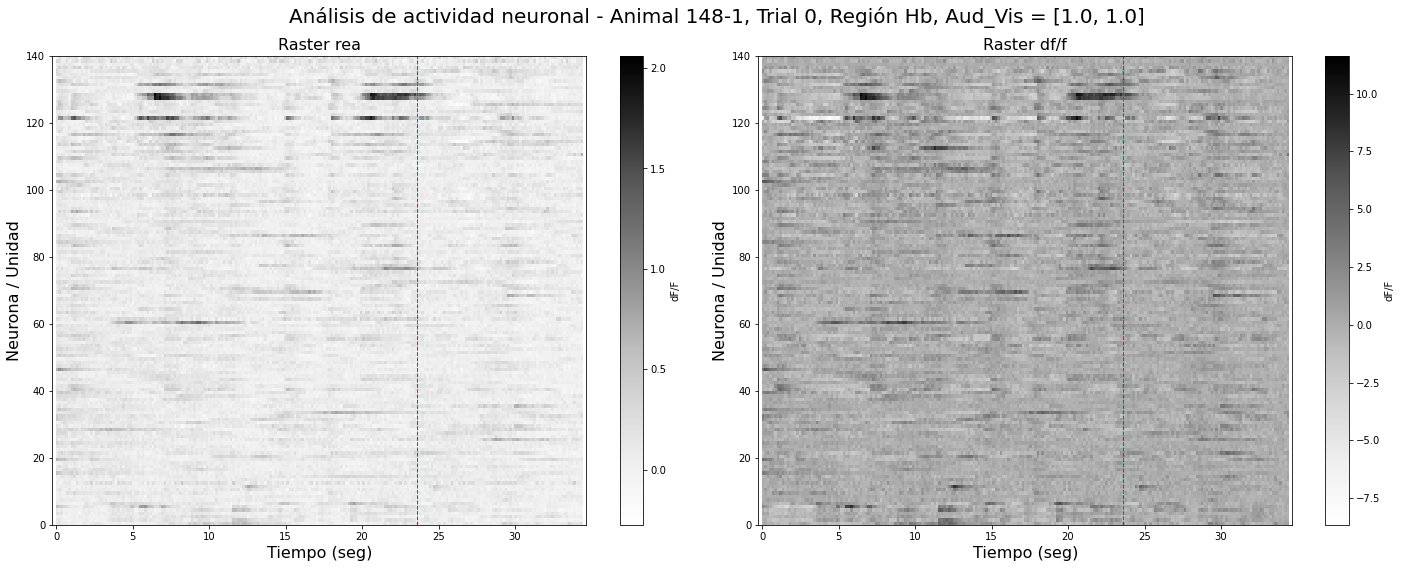

In [10]:
key= '148-1'
region = 'Hb'
trial = 0
if type(trial) == int:
    trials_to_plot = [trial]
else:
    trials_to_plot = range(len(areas[key].trials))
for trial in trials_to_plot:
    t_tot = round(areas[key].trials[trial].total_time,2)
    aud_vis = [areas[key].trials[trial].aud, float(areas[key].trials[trial].vis)]
    roi_activity =  areas[key].trials_rea[trial].roi_dffs_rea[region]


    dffs = areas[key].trials[trial].roi_dffs[region]



    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'Análisis de actividad neuronal - Animal {key}, Trial {trial}, Región {region}, Aud_Vis = {aud_vis}', fontsize=20)

    # Raster plot data cruda
    ax1 = axes[0]
    im = ax1.imshow(roi_activity, aspect='auto', cmap='Greys', interpolation='nearest',
                    extent=[0, t_tot, 0, roi_activity.shape[0]])
    fig.colorbar(im, ax=ax1, label='dF/F')
    ax1.set_xlabel('Tiempo (seg)', fontsize=16)
    ax1.set_ylabel('Neurona / Unidad', fontsize=16)
    ax1.set_title('Raster rea', fontsize=16)
    ax1.set_xlim(-.25, t_tot+.25)
    ax1.axvline(x=23.6, color='red', linestyle='--', linewidth=1)  # línea punteada roja

    # Raster plot df/f
    ax2 = axes[1]
    im = ax2.imshow(dffs, aspect='auto', cmap='Greys', interpolation='nearest',
                    extent=[0, t_tot, 0, dffs.shape[0]])
    fig.colorbar(im, ax=ax2, label='dF/F')
    ax2.set_xlabel('Tiempo (seg)', fontsize=16)
    ax2.set_ylabel('Neurona / Unidad', fontsize=16)
    ax2.set_title('Raster df/f', fontsize=16)
    ax2.set_xlim(-.25, t_tot+.25)
    ax2.axvline(x=23.6, color='red', linestyle='--', linewidth=1)  # línea punteada roja

    plt.tight_layout()
    plt.show()



[G1 ( <= 15 dpf)] Ventana 23.6–24.6s  C=nan  AV=nan  Δ(AV−C)=nan
[G2 ( + 15 dpf)] Ventana 23.6–24.6s  C=nan  AV=nan  Δ(AV−C)=nan


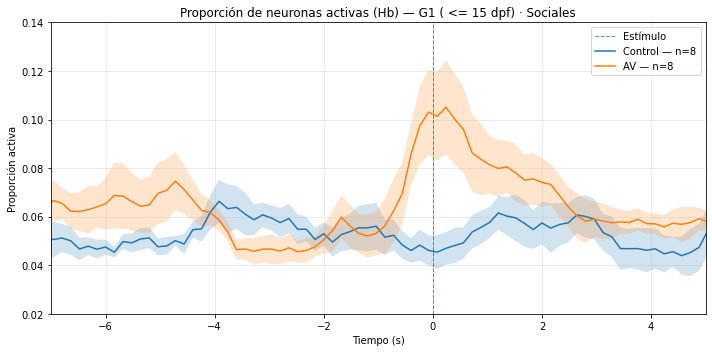

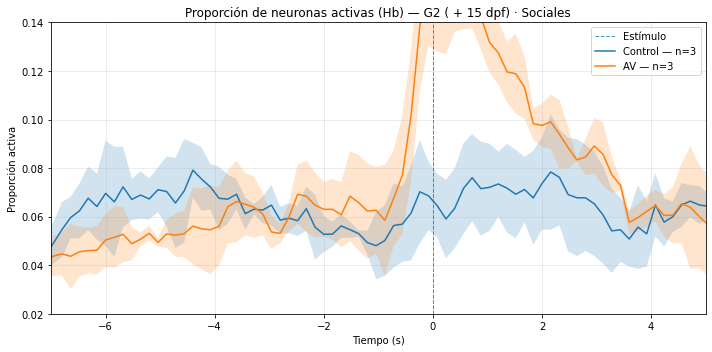

In [15]:
# === Parámetros que TENÉS que ajustar ==============================
region_key = 'Hb'
stim_s     = 23.6         # segundo del estímulo
win_s      = 1.0          # ventana post-estímulo (s)
fps        = 6.25         # <-- PONÉ TU FPS AQUÍ (float). Requerido si no hay trial.frame_times

# Grupos por edad (dpf)
#grupos = {
 #   "G1 (6–8 dpf)":   lambda e: 6 <= e <= 8,
 #   "G2 (12–13 dpf)": lambda e: 12 <= e <= 13,
  #  "G3 (15–16 dpf)": lambda e: 15 <= e <= 16,
#}
grupos = {
    "G1 ( <= 15 dpf)":   lambda e:  e <= 15,
    "G2 ( + 15 dpf)": lambda e: 15 < e ,
}

# === Utilidades ====================================================
os.chdir(f'H:\My Drive\Valen Agulló\SAN 2025')

def _get_condition(trial):
    return 'AV' if getattr(trial, 'vis', 0) == 1 and getattr(trial, 'aud', 0) == 1 else 'C'

def _trial_timebase(trial, fallback_fps, lefty=None):
    """
    Devuelve vector de tiempos (s) y fps para un trial.
    Usa trial.frame_times si existe; si no, usa trial.fps o fallback_fps.
    """
    ft = getattr(trial, 'frame_times', None)
    if ft is not None:
        ft = np.asarray(ft, dtype=float)
        if len(ft) > 1:
            dif = np.diff(ft)
            fps_est = 1.0 / np.median(dif)
        else:
            fps_est = fallback_fps
        return ft, fps_est

    t_fps = getattr(trial, 'fps', None)
    if t_fps is None:
        if fallback_fps is None:
            raise ValueError("Definí 'fps' o prové trial.frame_times / trial.fps.")
        t_fps = fallback_fps

    # rb = getattr(trial, 'roi_binaries', None)
    if lefty==True:
        rb = trial[areas['131-1'].roi_lefties[region_key]]
    rb = getattr(trial, 'roi_binaries_rea', None)
    if rb is None or region_key not in rb:
        raise ValueError(f"Falta roi_binaries_rea['{region_key}'].")
    arr = np.asarray(rb[region_key])            # forma garantizada: (n_rois, n_frames)
    n_frames = arr.shape[1]
    t = np.arange(n_frames, dtype=float) / float(t_fps)
    return t, float(t_fps)

def _prop_active_per_frame(trial):
    """Proporción de neuronas activas (n_rois x n_frames → 1 x n_frames)."""
    rb = getattr(trial, 'roi_binaries_rea', None)
    if rb is None or region_key not in rb:
        return None
    arr = np.asarray(rb[region_key])            # SIEMPRE (n_rois, n_frames)
    arr_bin = (arr > 0).astype(float)
    return arr_bin.mean(axis=0)

def _truncate_to_common_length(list_of_arrays):
    L = [len(a) for a in list_of_arrays if a is not None]
    if not L:
        return [], 0
    m = min(L)
    return [a[:m] for a in list_of_arrays if a is not None], m

def _mean_sem_over_animals(animal_traces):
    if len(animal_traces) == 0:
        return None, None
    X, L = _truncate_to_common_length(animal_traces)
    if L == 0:
        return None, None
    M = np.vstack(X)
    mean = M.mean(axis=0)
    sem  = M.std(axis=0, ddof=1) / np.sqrt(M.shape[0]) if M.shape[0] > 1 else np.zeros_like(mean)
    return mean, sem

def _window_indices(t, t0, dur):
    return (t >= t0) & (t < t0 + dur)

# === Procesamiento: solo animales sociales =========================
social_keys = [k for k, a in areas.items() if getattr(a, 'aislado', 1) == 0]

resultados = {g: {"C": {"animals": [], "t": None}, "AV": {"animals": [], "t": None}}
              for g in grupos.keys()}

for k in social_keys:
    area = areas[k]
    edad = int(getattr(area, 'edad', -999))

    # Asignar grupo por edad
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue

    per_trial = {"C": [], "AV": []}
    per_time  = {"C": [], "AV": []}

    for tr in getattr(area, 'trials_rea', []):
        cond = _get_condition(tr)
        try:
            t, tr_fps = _trial_timebase(tr, fps)
            prop = _prop_active_per_frame(tr)
            if prop is None:
                continue
            m = min(len(t), len(prop))
            per_trial[cond].append(prop[:m])
            per_time[cond].append(t[:m])
        except Exception:
            continue

    # Promedio por animal y condición
    for cond in ['C', 'AV']:
        if len(per_trial[cond]) == 0:
            continue
        series, m = _truncate_to_common_length(per_trial[cond])
        if m == 0:
            continue
        tseries, _ = _truncate_to_common_length(per_time[cond])
        t_common = tseries[0] if len(tseries) > 0 else np.arange(m) / (tr_fps if fps is None else fps)
        animal_mean = np.vstack(series).mean(axis=0)

        resultados[gname][cond]["animals"].append(animal_mean)
        if resultados[gname][cond]["t"] is None:
            resultados[gname][cond]["t"] = t_common

# === Gráficos (3 figuras: G1, G2, G3) =============================
for gname in grupos.keys():
    data = resultados[gname]
    mean_C, sem_C   = _mean_sem_over_animals(data['C']["animals"])
    mean_AV, sem_AV = _mean_sem_over_animals(data['AV']["animals"])

    # Base temporal para graficar
    tC = data['C']["t"]
    tA = data['AV']["t"]
    if mean_AV is not None:
        t_plot = tA[:len(mean_AV)] - stim_s
    elif mean_C is not None:
        t_plot = tC[:len(mean_C)] - stim_s
    else:
        print(f"[{gname}] Sin datos.")
        continue

    w_idx = _window_indices(t_plot, stim_s, win_s)
    def _avg_win(x): return float(np.nanmean(x[w_idx])) if (x is not None and w_idx.any()) else np.nan
    avgC = _avg_win(mean_C) if mean_C is not None else np.nan
    avgA = _avg_win(mean_AV) if mean_AV is not None else np.nan
    delta = (avgA - avgC) if (not np.isnan(avgA) and not np.isnan(avgC)) else np.nan

    fig = plt.figure(figsize=(10, 5))
    plt.title(f"Proporción de neuronas activas (Hb) — {gname} · Sociales")
    if w_idx.any():
        plt.axvspan(t_plot[w_idx][0], t_plot[w_idx][-1], alpha=0.15, label=f"Ventana {win_s:.1f}s")
    plt.axvline(0, linestyle='--', linewidth=1, alpha=0.8, label="Estímulo")

    if mean_C is not None:
        plt.plot(t_plot, mean_C[:len(t_plot)], label=f"Control — n={len(data['C']['animals'])}")
        if sem_C is not None:
            m = min(len(t_plot), len(sem_C))
            plt.fill_between(t_plot[:m], mean_C[:m]-sem_C[:m], mean_C[:m]+sem_C[:m], alpha=0.2)

    if mean_AV is not None:
        plt.plot(t_plot, mean_AV[:len(t_plot)], label=f"AV — n={len(data['AV']['animals'])}")
        if sem_AV is not None:
            m = min(len(t_plot), len(sem_AV))
            plt.fill_between(t_plot[:m], mean_AV[:m]-sem_AV[:m], mean_AV[:m]+sem_AV[:m], alpha=0.2)

    plt.xlabel("Tiempo (s)")
    plt.ylabel("Proporción activa")
    plt.ylim(.02, .14)
    plt.xlim(-7,5, 7.5)
    plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
    fig.patch.set_facecolor('white')
    # plt.savefig(f'{gname}_Sociales.png', dpi=300, bbox_inches='tight')

    print(f"[{gname}] Ventana {stim_s:.1f}–{stim_s+win_s:.1f}s  C={avgC:.4f}  AV={avgA:.4f}  Δ(AV−C)={delta:.4f}")


In [21]:
def to_dffs(activities, acts_to_filter, time_scale_in_frames = 15, window = 10, fast = False):
    baseline = linearly_extended_filter(acts_to_filter, time_scale_in_frames, window = window, fast = fast)
    #baseline = gaussian_filter1d(activities, time_scale_in_frames, mode = 'nearest')
    
    dffs = (activities - baseline)#/baseline
    return dffs, baseline

dffs_scale_seconds = 4
dffs_window_seconds = 3

binaries_std_s = 1
binaries_window_seconds = 15

binaries_baseline = 15
binaries_th = 1.5




for key in areas:
    if '52' not in key and key!= '131-1':
        print(key)
        for trial in areas[key].trials_rea:
            trial.roi_dffs_rea2 = {}
            trial.roi_baselines_rea2 = {}
            trial.roi_binaries_rea2 = {}
            trial.roi_smooth_dffs_rea2 = {}
            if np.isnan(trial.total_time):
                frames_per_s = trial.nframes /37
            else:
                frames_per_s = trial.nframes / trial.total_time
            
            for subarea in trial.roi_binaries_rea:
                
                new_acts = []
                
                for roi in range(trial.roi_binaries_rea[subarea].shape[0]):
                    x = np.arange(len(trial.roi_binaries_rea[subarea][roi]))[trial.roi_binaries_rea[subarea][roi]==0]
                    y = trial.roi_activities[subarea][roi,trial.roi_binaries_rea[subarea][roi]==0]
                    
                    nx = np.arange(trial.nframes)
                    ny = np.interp(nx,x,y)
                    
                    new_acts.append(ny)
                
                new_acts = np.vstack(new_acts)
                
                trial.roi_dffs[subarea], __ = to_dffs(trial.roi_activities[subarea], new_acts, time_scale_in_frames = frames_per_s * dffs_scale_seconds,
                                                                window = int(frames_per_s * dffs_window_seconds), fast = True)
                trial.roi_binaries_rea2[subarea], trial.roi_smooth_dffs_rea2[subarea] = to_binaries(trial.roi_dffs[subarea])
                
           

113-1
114-1
115-1
116-1
117-1
118-1
120-1
121-1
122-1
123-1
124-1
125-1
126-1
127-1
129-1
130-1
132-1
133-1
134-1
135-1
136-1
137-1
138-1
139-1
143-1


In [27]:
areas['148-1'].__dict__.keys()

dict_keys(['pez', 'n', 'trials', 'template', 'polygons_per_area', 'subtemplates', 'fecha', 'x', 'y', 'z', 'regions', 'template_small', 'factor', 'polygons_per_area_small', 'midline_points', 'grids', 'contours', 'centers', 'contours_small', 'centers_small', 'stack', 'm_rig', 'grid_lefties', 'roi_lefties', 'edad', 'n_un_hb', 'aislado', 'trials_rea'])

In [30]:
areas['148-1'].edad


12.0

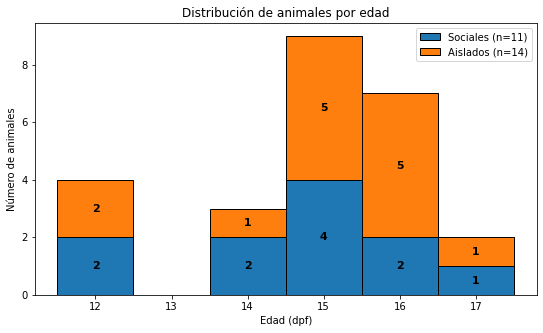

In [39]:
df = pd.DataFrame({
    "edad": [area.edad for area in areas.values()],
    "aislado": [area.aislado for area in areas.values()]
})

bins = np.arange(
    np.floor(df["edad"].min()) - 0.5,
    np.ceil(df["edad"].max()) + 1.5,
    1
)

sociales = df.loc[df["aislado"] == 0, "edad"]
aislados = df.loc[df["aislado"] == 1, "edad"]

n_sociales = len(sociales)
n_aislados = len(aislados)

# Conteos REALES por edad y condición
counts_sociales, _ = np.histogram(sociales, bins=bins)
counts_aislados, _ = np.histogram(aislados, bins=bins)

plt.figure(figsize=(9, 5))

counts, bins, patches = plt.hist(
    [sociales, aislados],
    bins=bins,
    stacked=True,
    label=[
        f"Sociales (n={n_sociales})",
        f"Aislados (n={n_aislados})"
    ],
    edgecolor="black"
)

# Etiquetas de SOCIALES
plt.bar_label(
    patches[0],
    labels=[
        str(n) if n > 0 else ""
        for n in counts_sociales
    ],
    label_type="center",
    fontsize=11,
    fontweight="bold"
)

# Etiquetas de AISLADOS
plt.bar_label(
    patches[1],
    labels=[
        str(n) if n > 0 else ""
        for n in counts_aislados
    ],
    label_type="center",
    fontsize=11,
    fontweight="bold"
)

plt.xlabel("Edad (dpf)")
plt.ylabel("Número de animales")
plt.title("Distribución de animales por edad")

plt.xticks(
    np.arange(
        np.floor(df["edad"].min()),
        np.ceil(df["edad"].max()) + 1,
        1
    )
)

plt.legend()
plt.show()

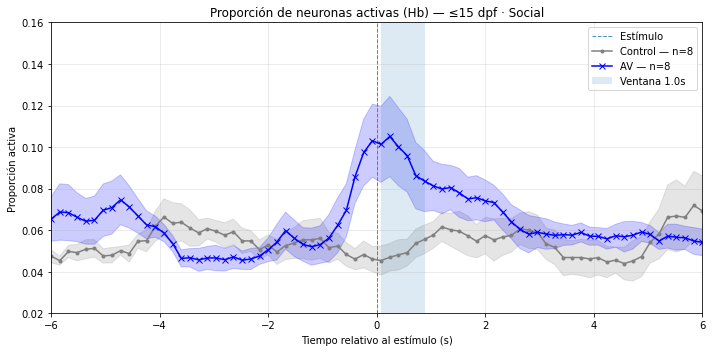

[≤15 dpf — Social] Ventana 0–1.0s post-estímulo | C=0.0498 | AV=0.0954 | Δ(AV−C)=0.0456 | nC=8 | nAV=8


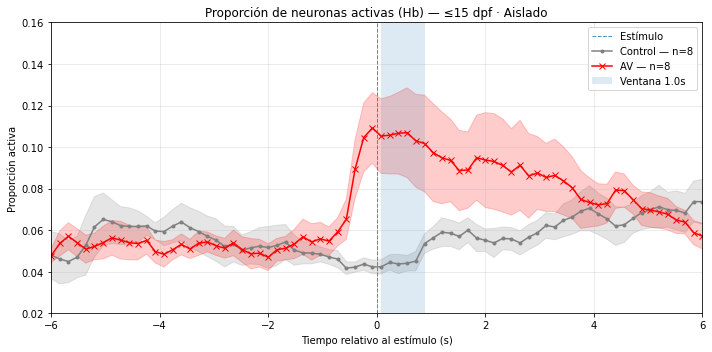

[≤15 dpf — Aislado] Ventana 0–1.0s post-estímulo | C=0.0456 | AV=0.1049 | Δ(AV−C)=0.0593 | nC=8 | nAV=8


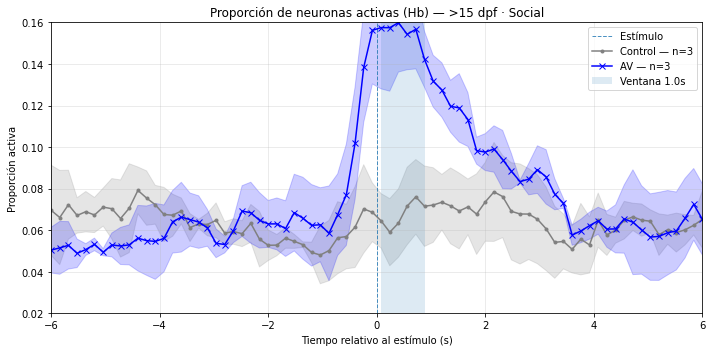

[>15 dpf — Social] Ventana 0–1.0s post-estímulo | C=0.0677 | AV=0.1547 | Δ(AV−C)=0.0870 | nC=3 | nAV=3


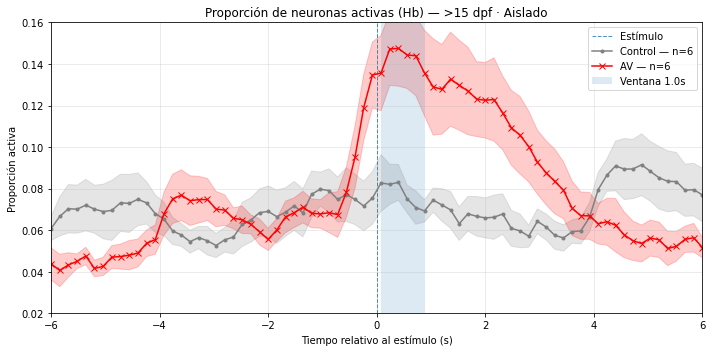

[>15 dpf — Aislado] Ventana 0–1.0s post-estímulo | C=0.0772 | AV=0.1424 | Δ(AV−C)=0.0652 | nC=6 | nAV=6


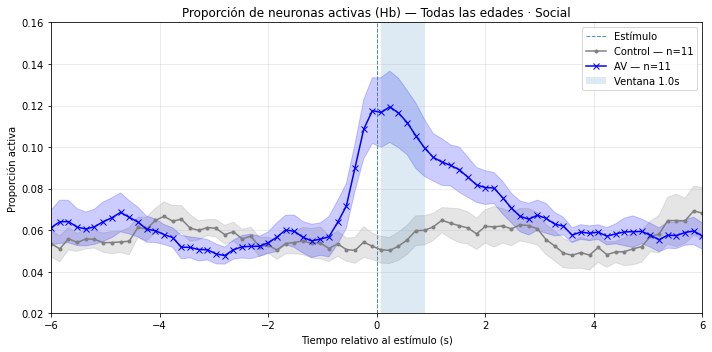

[Todas las edades — Social] Ventana 0–1.0s post-estímulo | C=0.0547 | AV=0.1116 | Δ(AV−C)=0.0569 | nC=11 | nAV=11


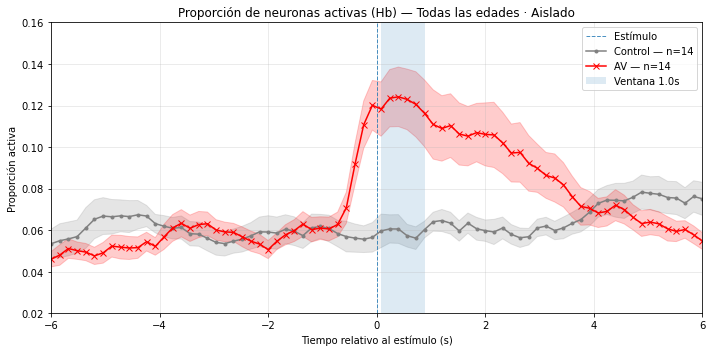

[Todas las edades — Aislado] Ventana 0–1.0s post-estímulo | C=0.0591 | AV=0.1210 | Δ(AV−C)=0.0618 | nC=14 | nAV=14


In [ ]:
region_key = 'Hb'
stim_s = 23.6
win_s = 1.0
fps = 6.25

grupos = {
    "≤15 dpf": lambda e: e <= 15,
    ">15 dpf": lambda e: e > 15,
    "Todas las edades": lambda e: True
}

os.chdir(r'H:\My Drive\Valen Agulló\SAN 2025')

def _get_condition(trial):
    return 'AV' if getattr(trial, 'vis', 0) == 1 and getattr(trial, 'aud', 0) == 1 else 'C'

def _trial_timebase(trial, fallback_fps):
    ft = getattr(trial, 'frame_times', None)
    if ft is not None:
        ft = np.asarray(ft, dtype=float)
        fps_est = 1 / np.median(np.diff(ft)) if len(ft) > 1 else fallback_fps
        return ft, fps_est

    t_fps = getattr(trial, 'fps', fallback_fps)
    if t_fps is None:
        raise ValueError("Falta fps.")

    rb = getattr(trial, 'roi_binaries_rea', None)
    if rb is None or region_key not in rb:
        raise ValueError(f"Falta roi_binaries_rea['{region_key}'].")

    n_frames = np.asarray(rb[region_key]).shape[1]
    return np.arange(n_frames) / t_fps, t_fps

def _prop_active_per_frame(trial):
    rb = getattr(trial, 'roi_binaries_rea', None)
    if rb is None or region_key not in rb:
        return None
    return (np.asarray(rb[region_key]) > 0).mean(axis=0)

def _truncate(arrays):
    if not arrays:
        return [], 0
    m = min(map(len, arrays))
    return [a[:m] for a in arrays], m

def _mean_sem(traces):
    X, m = _truncate(traces)
    if m == 0:
        return None, None
    X = np.vstack(X)
    mean = X.mean(axis=0)
    sem = X.std(axis=0, ddof=1) / np.sqrt(len(X)) if len(X) > 1 else np.zeros(m)
    return mean, sem


# resultados[grupo][Social/Aislado][C/AV]
resultados = {
    g: {s: {c: {"animals": [], "t": None} for c in ["C", "AV"]}
        for s in ["Social", "Aislado"]}
    for g in grupos
}

for k, area in areas.items():
    edad = int(getattr(area, 'edad', -999))
    aislado = getattr(area, 'aislado', None)

    if aislado == 0:
        social = "Social"
    elif aislado == 1:
        social = "Aislado"
    else:
        continue

    grupos_animal = [g for g, pred in grupos.items() if pred(edad)]
    per_trial = {"C": [], "AV": []}
    per_time = {"C": [], "AV": []}

    for tr in getattr(area, 'trials_rea', []):
        cond = _get_condition(tr)
        try:
            t, _ = _trial_timebase(tr, fps)
            prop = _prop_active_per_frame(tr)
            if prop is None:
                continue
            m = min(len(t), len(prop))
            per_trial[cond].append(prop[:m])
            per_time[cond].append(t[:m])
        except Exception as e:
            print(f"[WARNING] {k}: {e}")

    for cond in ["C", "AV"]:
        series, m = _truncate(per_trial[cond])
        if m == 0:
            continue

        times, _ = _truncate(per_time[cond])
        animal_mean = np.vstack(series).mean(axis=0)
        t_common = times[0][:m]

        for g in grupos_animal:
            resultados[g][social][cond]["animals"].append(animal_mean)
            if resultados[g][social][cond]["t"] is None:
                resultados[g][social][cond]["t"] = t_common


# =================================================================
# UNA FIGURA: 2 filas × 3 columnas
# =================================================================

fig, axes = plt.subplots(2, 3, figsize=(30, 10), sharex=True, sharey=True)

for col, gname in enumerate(grupos):
    for row, social in enumerate(["Social", "Aislado"]):
        ax = axes[row, col]
        data = resultados[gname][social]

        mean_C, sem_C = _mean_sem(data["C"]["animals"])
        mean_AV, sem_AV = _mean_sem(data["AV"]["animals"])

        ref = data["AV"] if mean_AV is not None else data["C"]
        mean_ref = mean_AV if mean_AV is not None else mean_C

        if mean_ref is None:
            ax.set_title(f"{gname} · {social}\nSin datos")
            continue

        t = ref["t"][:len(mean_ref)] - stim_s
        color_AV = "blue" if social == "Social" else "red"

        # Ventana 1 s post-estímulo
        w = (t >= 0) & (t < win_s)
        if w.any():
            ax.axvspan(t[w][0], t[w][-1], alpha=.15, label=f"Ventana {win_s:.1f}s")

        ax.axvline(0, linestyle="--", linewidth=1, alpha=.8, label="Estímulo")

        if mean_C is not None:
            m = min(len(t), len(mean_C))
            ax.plot(t[:m], mean_C[:m], color="gray", marker=".",
                    label=f"Control — n={len(data['C']['animals'])}")
            if sem_C is not None:
                ax.fill_between(t[:m], mean_C[:m]-sem_C[:m],
                                mean_C[:m]+sem_C[:m], color="gray", alpha=.2)

        if mean_AV is not None:
            m = min(len(t), len(mean_AV))
            ax.plot(t[:m], mean_AV[:m], color=color_AV, marker="x",
                    label=f"AV — n={len(data['AV']['animals'])}")
            if sem_AV is not None:
                ax.fill_between(t[:m], mean_AV[:m]-sem_AV[:m],
                                mean_AV[:m]+sem_AV[:m], color=color_AV, alpha=.2)

        ax.set_title(f"{gname} · {social}")
        ax.set_xlim(-6, 6)
        ax.set_ylim(.02, .16)
        ax.grid(alpha=.3)
        ax.legend()

        if row == 1:
            ax.set_xlabel("Tiempo relativo al estímulo (s)")
        if col == 0:
            ax.set_ylabel("Proporción activa")

fig.suptitle("Proporción de neuronas activas (Hb)", fontsize=18)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()

In [ ]:
# for key in areas:
#     if '52' not in key :
#         save_area(r'C:\Users\PC\Documents\GitHub\social_isolation_habenula_imaging\Exp_25\PKL 06-2025 Rea2', key, areas[key])

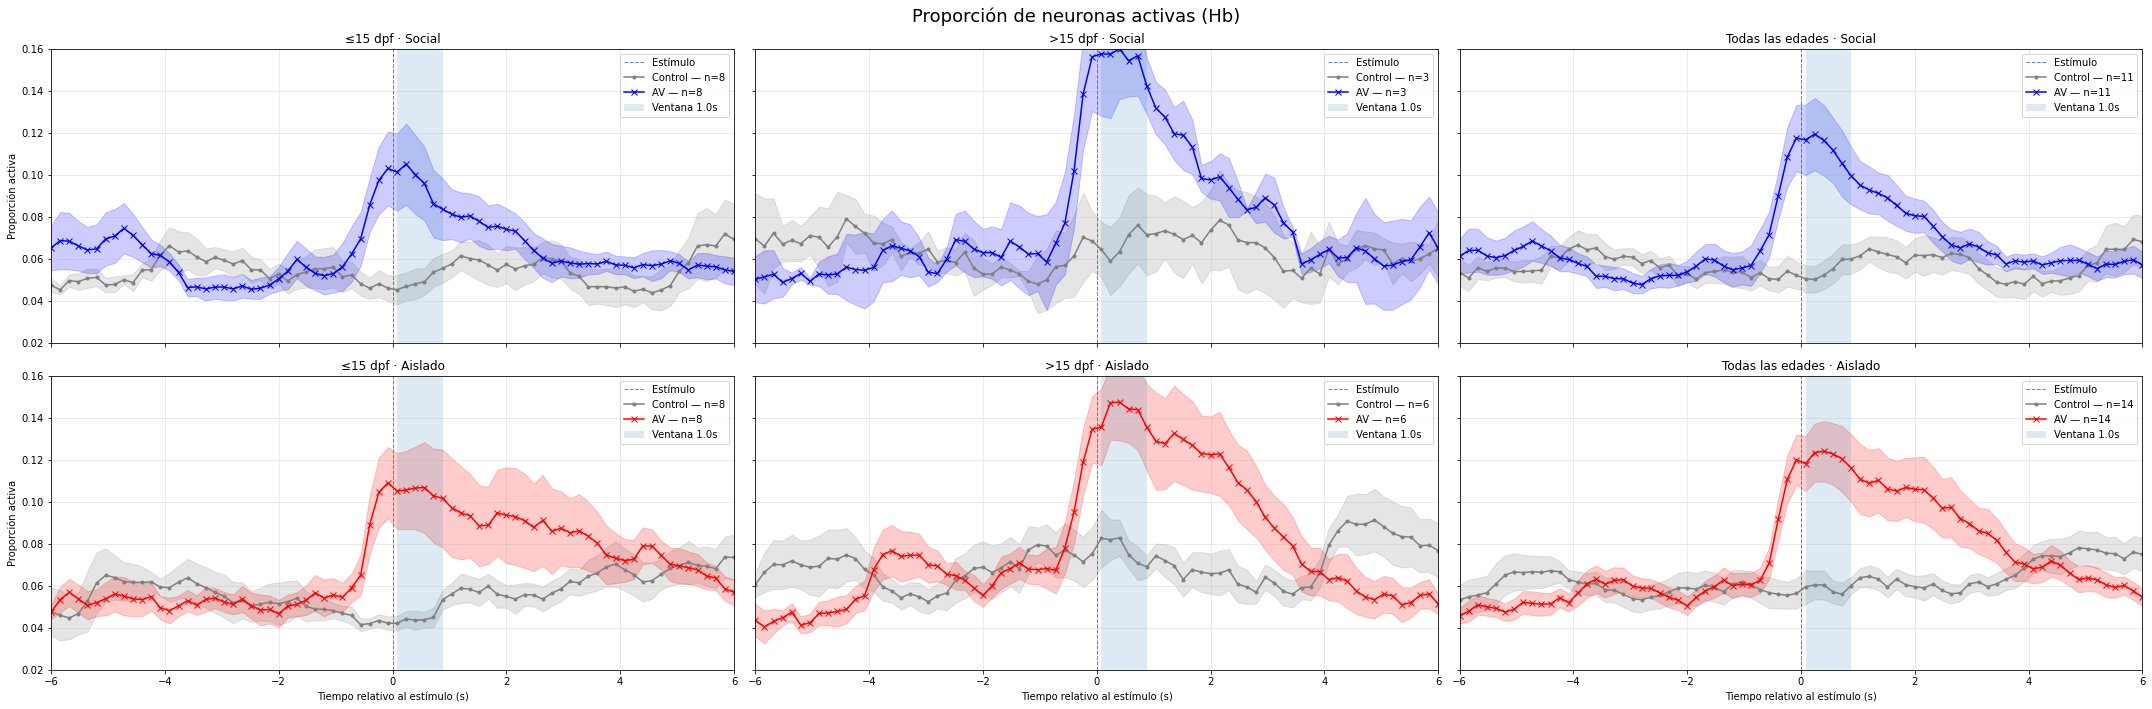

In [42]:
region_key = 'Hb'
stim_s = 23.6
win_s = 1.0
fps = 6.25

grupos = {
    "≤15 dpf": lambda e: e <= 15,
    ">15 dpf": lambda e: e > 15,
    "Todas las edades": lambda e: True
}

os.chdir(r'H:\My Drive\Valen Agulló\SAN 2025')

def _get_condition(trial):
    return 'AV' if getattr(trial, 'vis', 0) == 1 and getattr(trial, 'aud', 0) == 1 else 'C'

def _trial_timebase(trial, fallback_fps):
    ft = getattr(trial, 'frame_times', None)
    if ft is not None:
        ft = np.asarray(ft, dtype=float)
        fps_est = 1 / np.median(np.diff(ft)) if len(ft) > 1 else fallback_fps
        return ft, fps_est

    t_fps = getattr(trial, 'fps', fallback_fps)
    if t_fps is None:
        raise ValueError("Falta fps.")

    rb = getattr(trial, 'roi_binaries_rea', None)
    if rb is None or region_key not in rb:
        raise ValueError(f"Falta roi_binaries_rea['{region_key}'].")

    n_frames = np.asarray(rb[region_key]).shape[1]
    return np.arange(n_frames) / t_fps, t_fps

def _prop_active_per_frame(trial):
    rb = getattr(trial, 'roi_binaries_rea', None)
    if rb is None or region_key not in rb:
        return None
    return (np.asarray(rb[region_key]) > 0).mean(axis=0)

def _truncate(arrays):
    if not arrays:
        return [], 0
    m = min(map(len, arrays))
    return [a[:m] for a in arrays], m

def _mean_sem(traces):
    X, m = _truncate(traces)
    if m == 0:
        return None, None
    X = np.vstack(X)
    mean = X.mean(axis=0)
    sem = X.std(axis=0, ddof=1) / np.sqrt(len(X)) if len(X) > 1 else np.zeros(m)
    return mean, sem


# resultados[grupo][Social/Aislado][C/AV]
resultados = {
    g: {s: {c: {"animals": [], "t": None} for c in ["C", "AV"]}
        for s in ["Social", "Aislado"]}
    for g in grupos
}

for k, area in areas.items():
    edad = int(getattr(area, 'edad', -999))
    aislado = getattr(area, 'aislado', None)

    if aislado == 0:
        social = "Social"
    elif aislado == 1:
        social = "Aislado"
    else:
        continue

    grupos_animal = [g for g, pred in grupos.items() if pred(edad)]
    per_trial = {"C": [], "AV": []}
    per_time = {"C": [], "AV": []}

    for tr in getattr(area, 'trials_rea', []):
        cond = _get_condition(tr)
        try:
            t, _ = _trial_timebase(tr, fps)
            prop = _prop_active_per_frame(tr)
            if prop is None:
                continue
            m = min(len(t), len(prop))
            per_trial[cond].append(prop[:m])
            per_time[cond].append(t[:m])
        except Exception as e:
            print(f"[WARNING] {k}: {e}")

    for cond in ["C", "AV"]:
        series, m = _truncate(per_trial[cond])
        if m == 0:
            continue

        times, _ = _truncate(per_time[cond])
        animal_mean = np.vstack(series).mean(axis=0)
        t_common = times[0][:m]

        for g in grupos_animal:
            resultados[g][social][cond]["animals"].append(animal_mean)
            if resultados[g][social][cond]["t"] is None:
                resultados[g][social][cond]["t"] = t_common


# =================================================================
# UNA FIGURA: 2 filas × 3 columnas
# =================================================================

fig, axes = plt.subplots(2, 3, figsize=(30, 10), sharex=True, sharey=True)

for col, gname in enumerate(grupos):
    for row, social in enumerate(["Social", "Aislado"]):
        ax = axes[row, col]
        data = resultados[gname][social]

        mean_C, sem_C = _mean_sem(data["C"]["animals"])
        mean_AV, sem_AV = _mean_sem(data["AV"]["animals"])

        ref = data["AV"] if mean_AV is not None else data["C"]
        mean_ref = mean_AV if mean_AV is not None else mean_C

        if mean_ref is None:
            ax.set_title(f"{gname} · {social}\nSin datos")
            continue

        t = ref["t"][:len(mean_ref)] - stim_s
        color_AV = "blue" if social == "Social" else "red"

        # Ventana 1 s post-estímulo
        w = (t >= 0) & (t < win_s)
        if w.any():
            ax.axvspan(t[w][0], t[w][-1], alpha=.15, label=f"Ventana {win_s:.1f}s")

        ax.axvline(0, linestyle="--", linewidth=1, alpha=.8, label="Estímulo")

        if mean_C is not None:
            m = min(len(t), len(mean_C))
            ax.plot(t[:m], mean_C[:m], color="gray", marker=".",
                    label=f"Control — n={len(data['C']['animals'])}")
            if sem_C is not None:
                ax.fill_between(t[:m], mean_C[:m]-sem_C[:m],
                                mean_C[:m]+sem_C[:m], color="gray", alpha=.2)

        if mean_AV is not None:
            m = min(len(t), len(mean_AV))
            ax.plot(t[:m], mean_AV[:m], color=color_AV, marker="x",
                    label=f"AV — n={len(data['AV']['animals'])}")
            if sem_AV is not None:
                ax.fill_between(t[:m], mean_AV[:m]-sem_AV[:m],
                                mean_AV[:m]+sem_AV[:m], color=color_AV, alpha=.2)

        ax.set_title(f"{gname} · {social}")
        ax.set_xlim(-6, 6)
        ax.set_ylim(.02, .16)
        ax.grid(alpha=.3)
        ax.legend()

        if row == 1:
            ax.set_xlabel("Tiempo relativo al estímulo (s)")
        if col == 0:
            ax.set_ylabel("Proporción activa")

fig.suptitle("Proporción de neuronas activas (Hb)", fontsize=18)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()

In [ ]:
# def construir_df(areas, pred_grupo=None, solo_social=True):
#     """
#     Construye un DataFrame largo con:
#     fish_id, roi_id, cond ('C'/'AV'), y (#frames activos en ventana), n_frames (en ventana),
#     edad, aislado.
#     Si pred_grupo es None, no filtra por edad.
#     """
#     rows = []
#     for fish_id, area in areas.items():
#         edad    = int(getattr(area, 'edad', -999))
#         aislado = int(getattr(area, 'aislado', 1))
#         if solo_social and aislado != 0:
#             continue
#         if pred_grupo is not None and not pred_grupo(edad):
#             continue

#         trials = getattr(area, 'trials_rea', [])
#         for tr in trials:
#             cond = _get_condition(tr)
#             try:
#                 t, _fps = _trial_timebase(tr, fps)
#             except Exception:
#                 continue
#             w = _window_mask(t, stim_s, win_s)
#             if not w.any():
#                 continue

#             rb = getattr(tr, 'roi_binaries_rea2', None)
#             if rb is None or region_key not in rb:
#                 continue
#             B = np.asarray(rb[region_key])  # (n_rois, n_frames)
#             if B.ndim != 2:
#                 continue
#             B = (B > 0).astype(np.uint8)
#             n_rois = B.shape[0]
#             y_vec = B[:, w].sum(axis=1)                # éxitos (frames activos) por neurona
#             n_vec = np.full(n_rois, int(w.sum()))      # total de frames en ventana

#             for roi_idx in range(n_rois):
#                 rows.append({
#                     "fish_id":   str(fish_id),
#                     "roi_id":    int(roi_idx),
#                     "cond":      cond,
#                     "y":         int(y_vec[roi_idx]),
#                     "n_frames":  int(n_vec[roi_idx]),
#                     "edad":      edad,
#                     "aislado":   aislado
#                 })
#     return pd.DataFrame(rows)


# def _window_mask(t, t0, dur):
#     """Máscara booleana para [t0, t0+dur)."""
#     return (t >= t0) & (t < t0 + dur)



In [ ]:

# import statsmodels.api as sm

# def ajustar_glm_binomial_cluster(df):
#     df = df.copy()
#     df['prop'] = df['y'] / df['n_frames']
#     df['isAV'] = (df['cond'] == 'AV').astype(int)

#     # Diseñador con nombres de columnas:
#     X = sm.add_constant(df[['isAV']], has_constant='add')  # columnas: ['const','isAV']
#     y = df['prop'].values
#     w = df['n_frames'].astype(float).values

#     # cluster = neurona (pez + "_" + roi)
#     clusters = (df['fish_id'].astype(str) + "_" + df['roi_id'].astype(str)).values

#     glm = sm.GLM(y, X, family=sm.families.Binomial(), freq_weights=w)
#     fit = glm.fit(cov_type='cluster', cov_kwds={'groups': clusters})

#     beta_av = float(fit.params['isAV'])
#     se_av   = float(fit.bse['isAV'])
#     z       = float(fit.tvalues['isAV'])  # con cov robusta, t ≈ z
#     p_two   = float(fit.pvalues['isAV'])  # <-- usá p directamente del modelo

#     OR      = np.exp(beta_av)
#     lo, hi  = beta_av - 1.96*se_av, beta_av + 1.96*se_av

#     return {
#         "beta_av": beta_av,
#         "se_av":   se_av,
#         "z":       z,
#         "p_two":   p_two,
#         "OR":      OR,
#         "OR_lo":   float(np.exp(lo)),
#         "OR_hi":   float(np.exp(hi)),
#         "result":  fit
#     }


In [ ]:
# # === Inferencia: GLM Binomial con SEs robustos por neurona (cluster) ===
# # Requiere: df_g con columnas ['y','n_frames','cond','fish_id','roi_id']


# # === Correr por grupo (sociales) y combinado ===
# solo_social = True
# grupos = {
#     "G1 (6–8 dpf)":   lambda e: 6 <= e <= 8,
#     "G2 (12–13 dpf)": lambda e: 12 <= e <= 13,
#     "G3 (15–16 dpf)": lambda e: 15 <= e <= 16,
# }

# def construir_df_simple(grupo_pred=None):
#     df_g = construir_df(areas, pred_grupo=grupo_pred, solo_social=solo_social)
#     # aseguramos que haya ambas condiciones
#     if len(df_g)==0 or df_g['cond'].nunique()<2:
#         return None
#     return df_g

# res_glm = {}

# for gname, gpred in grupos.items():
#     df_g = construir_df_simple(gpred)
#     if df_g is None:
#         print(f"[{gname}] Sin datos suficientes.")
#         continue
#     res = ajustar_glm_binomial_cluster(df_g)
#     res_glm[gname] = res
#     print(f"\n=== {gname} · Sociales={solo_social} ===")
#     print(f"filas={len(df_g)}, peces={df_g['fish_id'].nunique()}, neuronas={(df_g['fish_id'].astype(str)+'_'+df_g['roi_id'].astype(str)).nunique()}")
#     print(f"Efecto AV (log-odds): {res['beta_av']:.4f} ± {res['se_av']:.4f} [z={res['z']:.2f}, p={res['p_two']:.3g}]")
#     print(f"OR={res['OR']:.3f}  IC95% OR=[{res['OR_lo']:.3f}, {res['OR_hi']:.3f}]")

# # Combinado (todos los grupos etarios)
# df_all = construir_df_simple(None)
# if df_all is not None:
#     res_all = ajustar_glm_binomial_cluster(df_all)
#     res_glm["Todos"] = res_all
#     print(f"\n=== Todos (combinado) · Sociales={solo_social} ===")
#     print(f"filas={len(df_all)}, peces={df_all['fish_id'].nunique()}, neuronas={(df_all['fish_id'].astype(str)+'_'+df_all['roi_id'].astype(str)).nunique()}")
#     print(f"Efecto AV (log-odds): {res_all['beta_av']:.4f} ± {res_all['se_av']:.4f} [z={res_all['z']:.2f}, p={res_all['p_two']:.3g}]")
#     print(f"OR={res_all['OR']:.3f}  IC95% OR=[{res_all['OR_lo']:.3f}, {res_all['OR_hi']:.3f}]")
# else:
#     print("\n[Todos] Sin datos suficientes.")


c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1530: SpecificationWarning: cov_type not fully supported with freq_weights
  SpecificationWarning)
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1530: SpecificationWarning: cov_type not fully supported with freq_weights
  SpecificationWarning)
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1530: SpecificationWarning: cov_type not fully supported with freq_weights
  SpecificationWarning)



=== G1 (6–8 dpf) · Sociales=True ===
filas=14090, peces=11, neuronas=1409
Efecto AV (log-odds): 0.3150 ± 0.0629 [z=5.01, p=5.51e-07]
OR=1.370  IC95% OR=[1.211, 1.550]

=== G2 (12–13 dpf) · Sociales=True ===
filas=9390, peces=8, neuronas=939
Efecto AV (log-odds): 0.6821 ± 0.0825 [z=8.27, p=1.34e-16]
OR=1.978  IC95% OR=[1.683, 2.325]

=== G3 (15–16 dpf) · Sociales=True ===
filas=3310, peces=3, neuronas=331
Efecto AV (log-odds): 0.3879 ± 0.1351 [z=2.87, p=0.0041]
OR=1.474  IC95% OR=[1.131, 1.921]

=== Todos (combinado) · Sociales=True ===
filas=26790, peces=22, neuronas=2679
Efecto AV (log-odds): 0.4499 ± 0.0471 [z=9.55, p=1.33e-21]
OR=1.568  IC95% OR=[1.430, 1.720]


c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1530: SpecificationWarning: cov_type not fully supported with freq_weights
  SpecificationWarning)


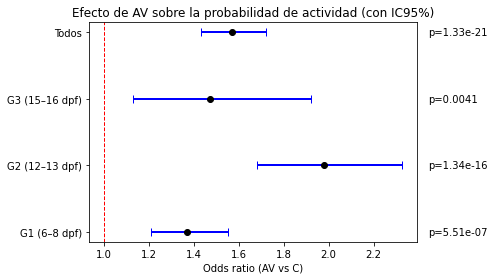

In [ ]:
# import matplotlib.pyplot as plt

# # Orden de los grupos
# order = ["G1 (6–8 dpf)", "G2 (12–13 dpf)", "G3 (15–16 dpf)", "Todos"]

# # Extraigo los resultados en listas
# labels, ors, lo, hi, pvals = [], [], [], [], []
# for g in order:
#     if g in res_glm:
#         labels.append(g)
#         ors.append(res_glm[g]["OR"])
#         lo.append(res_glm[g]["OR_lo"])
#         hi.append(res_glm[g]["OR_hi"])
#         pvals.append(res_glm[g]["p_two"])

# # Plot tipo forest plot
# fig, ax = plt.subplots(figsize=(7,4))

# y_pos = range(len(labels))
# ax.errorbar(ors, y_pos, xerr=[np.array(ors)-np.array(lo), np.array(hi)-np.array(ors)],
#             fmt='o', color='black', ecolor='blue', elinewidth=2, capsize=4)

# # Línea de referencia en OR=1 (sin efecto)
# ax.axvline(1.0, color='red', linestyle='--', linewidth=1)

# ax.set_yticks(y_pos)
# ax.set_yticklabels(labels)
# ax.set_xlabel("Odds ratio (AV vs C)")
# ax.set_title("Efecto de AV sobre la probabilidad de actividad (con IC95%)")

# # Agrego los p-valores a la derecha
# for y, or_, p in zip(y_pos, ors, pvals):
#     ax.text(max(hi)*1.05, y, f"p={p:.3g}", va='center')

# plt.tight_layout()
# fig.patch.set_facecolor('white')
# # plt.savefig(f'Prob_act_AV.png', dpi=300, bbox_inches='tight')
# plt.show()


# Graficos SAN 2025

<style>
.kw   { color:#C586C0; font-family:monospace; }   /* keywords: if, for, else, def... */
.func { color:#dcdcaa; font-family:monospace; }   /* funciones incorporadas (len, etc.) */
.str  { color:#ce9178; font-family:monospace; }   /* strings */
.bi   { color:#4EC9B0; font-family:monospace; }   /* builtins como type */
.num  { color:#b5cea8; font-family:monospace; }   /* números */
.cmt  { color:#6a9955; font-family:monospace; }   /* comentarios */
.var  { color:#9CDCFE; font-family:monospace; }   /* variables/funciones definidas */
.cons { color:#569CD6; font-family:monospace; }   /* constantes: True, False, None */
</style>

## Armamos los data_frame a partir de los trials_rea y los roi_binaries_rea de tal forma que nos queda <code class="var">df_soc</code>,  <code class="var">summary_soc</code>  <code class="var">df_ais</code> , <code class="var">summary_ais</code> guardado los datos para cada grupo y su resumen.

In [ ]:
# ================================================================
# Análisis de probabilidad de respuesta con datos "rea"
# ================================================================


# --------------------------
# Parámetros del análisis
# --------------------------
region_key = "Hb"   # región de interés
stim_s     = 23.6   # tiempo del estímulo en segundos
fps        = 6.5    # cuadros por segundo
post_frames = 6     # número de frames post-estímulo para evaluar

# Definición de grupos etarios

# --------------------------
# Funciones auxiliares
# --------------------------
def _get_condition(trial):
    """Devuelve 'AV' si el trial es audiovisual, 'C' si es control."""
    return 'AV' if getattr(trial, 'vis', 0)==1 and getattr(trial, 'aud', 0)==1 else 'C'

def _trial_timebase(trial, fallback_fps):
    """
    Devuelve el vector de tiempos en segundos y el fps estimado.
    Si el trial tiene frame_times los usa, si no recurre a fps conocido.
    """
    ft = getattr(trial, 'frame_times', None)
    if ft is not None:
        ft = np.asarray(ft, float)
        if len(ft) > 1:
            fps_est = 1.0 / np.median(np.diff(ft))
        else:
            fps_est = fallback_fps
        return ft, float(fps_est)
    else:
        t_fps = getattr(trial, 'fps', None) or fallback_fps
        n_frames = np.asarray(trial.roi_binaries_rea[region_key]).shape[1]
        t = np.arange(n_frames, dtype=float) / float(t_fps)
        return t, float(t_fps)

def analizar_respuestas(modo="sociales"):
    """
    Construye un DataFrame con neuronas × trial y calcula la probabilidad
    de respuesta (≥1 frame activo en ventana post estímulo).
    
    modo = "sociales" → usa solo animales sociales (aislado == 0)
    modo = "aislados" → usa solo animales aislados (aislado == 1)
    """
    assert modo in ["sociales", "aislados"], "modo debe ser 'sociales' o 'aislados'"
    target = 0 if modo == "sociales" else 1

    rows = []
    for fish_id, area in areas.items():
        edad    = int(getattr(area, "edad", -999))
        aislado = int(getattr(area, "aislado", 1))

        # Filtrar por tipo de animal
        if aislado != target:
            continue

        # Determinar grupo etario
        gname = None
        for name, pred in grupos.items():
            if pred(edad):
                gname = name
                break
        if gname is None:
            continue

        # Iterar trials_rea
        for tr in getattr(area, "trials_rea", []):
            cond = _get_condition(tr)

            try:
                t, tr_fps = _trial_timebase(tr, fps)
            except Exception:
                continue

            stim_frame = int(round(stim_s * tr_fps))
            w_idx = np.arange(stim_frame, stim_frame + post_frames)
            if w_idx.max() >= len(t):
                continue

            rb = getattr(tr, "roi_binaries_rea2", None)
            if rb is None or region_key not in rb:
                continue

            B = np.asarray(rb[region_key])
            if B.ndim != 2:
                continue
            B = (B > 0).astype(int)

            y_any = (B[:, w_idx].sum(axis=1) > 0).astype(int)

            for roi_idx, resp in enumerate(y_any):
                rows.append({
                    "fish_id": str(fish_id),
                    "roi_id": roi_idx,
                    "edad": edad,
                    "grupo": gname,
                    "cond": cond,
                    "respuesta": resp
                })

    df_resp = pd.DataFrame(rows)






    # Calcular probabilidades por grupo-condición
    summary = (df_resp
               .groupby(["grupo","cond"])
               .agg(mean_prob=("respuesta","mean"),
                    sd_prob=("respuesta","std"),
                    n=("respuesta","count"))
               .reset_index())
    summary["sem_prob"] = summary["sd_prob"] / np.sqrt(summary["n"])

    return df_resp, summary

# --------------------------
# Ejecutar análisis
# --------------------------

df_soc, summary_soc = analizar_respuestas(modo="sociales")
df_ais, summary_ais = analizar_respuestas(modo="aislados")

print("=== Sociales ===")
print(summary_soc)

print("\n=== Aislados ===")
print(summary_ais)


=== Sociales ===
     grupo cond  mean_prob   sd_prob     n  sem_prob
0  >15 dpf   AV   0.254082  0.435455  1960  0.009836
1  >15 dpf    C   0.123469  0.329059  1960  0.007433
2  ≤15 dpf   AV   0.178607  0.383051  6937  0.004599
3  ≤15 dpf    C   0.105233  0.306875  6937  0.003684

=== Aislados ===
     grupo cond  mean_prob   sd_prob     n  sem_prob
0  >15 dpf   AV   0.228229  0.419742  4088  0.006565
1  >15 dpf    C   0.144080  0.351214  4088  0.005493
2  ≤15 dpf   AV   0.177365  0.382001  8085  0.004248
3  ≤15 dpf    C   0.103401  0.304501  8085  0.003386


In [276]:
os.chdir(r'H:\My Drive\Valen Agulló\SAN 2025')

In [19]:
# ================================================================
# Inferencia con GLM Binomial (cluster = neurona) usando datos "rea"
# ================================================================
import statsmodels.api as sm

# --------------------------
# Función: construir DataFrame largo
# --------------------------
def construir_df_rea(areas, pred_grupo=None, modo="sociales"):
    """
    Construye DataFrame con columnas:
      fish_id, roi_id, cond ('C'/'AV'),
      y (#frames activos en ventana post-estímulo),
      n_frames (longitud ventana),
      edad, grupo
    Usando trials_rea y roi_binaries_rea.
    """
    assert modo in ["sociales", "aislados"], "modo debe ser 'sociales' o 'aislados'"
    target = 0 if modo == "sociales" else 1

    rows = []
    for fish_id, area in areas.items():
        edad    = int(getattr(area, "edad", -999))
        aislado = int(getattr(area, "aislado", 1))

        if aislado != target:
            continue
        if pred_grupo is not None and not pred_grupo(edad):
            continue

        # Iterar trials_rea
        for tr in getattr(area, "trials_rea", []):
            cond = _get_condition(tr)
            try:
                t, tr_fps = _trial_timebase(tr, fps)
            except Exception:
                continue

            stim_frame = int(round(stim_s * tr_fps))
            w_idx = np.arange(stim_frame, stim_frame + post_frames)
            if w_idx.max() >= len(t):
                continue

            rb = getattr(tr, "roi_binaries_rea2", None)
            if rb is None or region_key not in rb:
                continue
            B = np.asarray(rb[region_key])
            if B.ndim != 2:
                continue
            B = (B > 0).astype(int)

            # Conteos por neurona en la ventana
            y_vec = B[:, w_idx].sum(axis=1)
            n_vec = np.full(B.shape[0], len(w_idx))

            for roi_idx, (y, n) in enumerate(zip(y_vec, n_vec)):
                rows.append({
                    "fish_id": str(fish_id),
                    "roi_id": int(roi_idx),
                    "cond": cond,
                    "y": int(y),
                    "n_frames": int(n),
                    "edad": edad
                })

    return pd.DataFrame(rows)


# --------------------------
# Función: ajustar GLM binomial con cluster
# --------------------------
def ajustar_glm_binomial_cluster(df):
    """
    Ajusta un GLM Binomial con covariables robustas agrupadas por neurona.
    Retorna un diccionario con coeficientes, OR e intervalos.
    """
    df = df.copy()
    df['prop'] = df['y'] / df['n_frames']
    df['isAV'] = (df['cond'] == 'AV').astype(int)

    X = sm.add_constant(df[['isAV']], has_constant='add')
    y = df['prop'].values
    w = df['n_frames'].astype(float).values

    clusters = (df['fish_id'].astype(str) + "_" + df['roi_id'].astype(str)).values

    glm = sm.GLM(y, X, family=sm.families.Binomial(), freq_weights=w)
    fit = glm.fit(cov_type='cluster', cov_kwds={'groups': clusters})

    beta_av = float(fit.params['isAV'])
    se_av   = float(fit.bse['isAV'])
    z       = float(fit.tvalues['isAV'])
    p_two   = float(fit.pvalues['isAV'])

    OR      = np.exp(beta_av)
    lo, hi  = beta_av - 1.96*se_av, beta_av + 1.96*se_av

    return {
        "beta_av": beta_av,
        "se_av": se_av,
        "z": z,
        "p_two": p_two,
        "OR": OR,
        "OR_lo": float(np.exp(lo)),
        "OR_hi": float(np.exp(hi)),
        "result": fit
    }



In [20]:

# --------------------------
# Ejecutar por grupo
# --------------------------
modo = "sociales"   # 👈 cambiar a "aislados" si querés
res_glm = {}

for gname, gpred in grupos.items():
    df_g = construir_df_rea(areas, pred_grupo=gpred, modo=modo)
    if df_g.empty or df_g['cond'].nunique() < 2:
        print(f"[{gname}] Sin datos suficientes.")
        continue

    res = ajustar_glm_binomial_cluster(df_g)
    res_glm[gname] = res
    print(f"\n=== {gname} · Modo={modo} ===")
    print(f"filas={len(df_g)}, peces={df_g['fish_id'].nunique()}, "
          f"neuronas={(df_g['fish_id'] + '_' + df_g['roi_id'].astype(str)).nunique()}")
    print(f"Efecto AV (log-odds): {res['beta_av']:.4f} ± {res['se_av']:.4f} "
          f"[z={res['z']:.2f}, p={res['p_two']:.3g}]")
    print(f"OR={res['OR']:.3f}  IC95% OR=[{res['OR_lo']:.3f}, {res['OR_hi']:.3f}]")

# --------------------------
# Todos los grupos combinados
# --------------------------
df_all = construir_df_rea(areas, pred_grupo=None, modo=modo)
if not df_all.empty and df_all['cond'].nunique() >= 2:
    res_all = ajustar_glm_binomial_cluster(df_all)
    res_glm["Todos"] = res_all
    print(f"\n=== Todos (combinado) · Modo={modo} ===")
    print(f"filas={len(df_all)}, peces={df_all['fish_id'].nunique()}, "
          f"neuronas={(df_all['fish_id'] + '_' + df_all['roi_id'].astype(str)).nunique()}")
    print(f"Efecto AV (log-odds): {res_all['beta_av']:.4f} ± {res_all['se_av']:.4f} "
          f"[z={res_all['z']:.2f}, p={res_all['p_two']:.3g}]")
    print(f"OR={res_all['OR']:.3f}  IC95% OR=[{res_all['OR_lo']:.3f}, {res_all['OR_hi']:.3f}]")
else:
    print("\n[Todos] Sin datos suficientes.")


c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1530: SpecificationWarning: cov_type not fully supported with freq_weights
  SpecificationWarning)
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1530: SpecificationWarning: cov_type not fully supported with freq_weights
  SpecificationWarning)
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1530: SpecificationWarning: cov_type not fully supported with freq_weights
  SpecificationWarning)
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1530: SpecificationWarning: cov_type not fully supported with freq_weights
  SpecificationWarning)



=== G1 (6–8 dpf) · Modo=sociales ===
filas=14090, peces=11, neuronas=1409
Efecto AV (log-odds): 0.3150 ± 0.0629 [z=5.01, p=5.51e-07]
OR=1.370  IC95% OR=[1.211, 1.550]

=== G2 (12–13 dpf) · Modo=sociales ===
filas=9390, peces=8, neuronas=939
Efecto AV (log-odds): 0.6821 ± 0.0825 [z=8.27, p=1.34e-16]
OR=1.978  IC95% OR=[1.683, 2.325]

=== G3 (15–16 dpf) · Modo=sociales ===
filas=3310, peces=3, neuronas=331
Efecto AV (log-odds): 0.3879 ± 0.1351 [z=2.87, p=0.0041]
OR=1.474  IC95% OR=[1.131, 1.921]

=== Todos (combinado) · Modo=sociales ===
filas=26790, peces=22, neuronas=2679
Efecto AV (log-odds): 0.4499 ± 0.0471 [z=9.55, p=1.33e-21]
OR=1.568  IC95% OR=[1.430, 1.720]


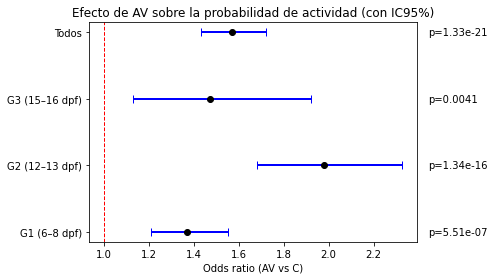

In [39]:
import matplotlib.pyplot as plt

# Orden de los grupos
order = ["G1 (6–8 dpf)", "G2 (12–13 dpf)", "G3 (15–16 dpf)", "Todos"]

# Extraigo los resultados en listas
labels, ors, lo, hi, pvals = [], [], [], [], []
for g in order:
    if g in res_glm:
        labels.append(g)
        ors.append(res_glm[g]["OR"])
        lo.append(res_glm[g]["OR_lo"])
        hi.append(res_glm[g]["OR_hi"])
        pvals.append(res_glm[g]["p_two"])

# Plot tipo forest plot
fig, ax = plt.subplots(figsize=(7,4))

y_pos = range(len(labels))
ax.errorbar(ors, y_pos, xerr=[np.array(ors)-np.array(lo), np.array(hi)-np.array(ors)],
            fmt='o', color='black', ecolor='blue', elinewidth=2, capsize=4)

# Línea de referencia en OR=1 (sin efecto)
ax.axvline(1.0, color='red', linestyle='--', linewidth=1)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlabel("Odds ratio (AV vs C)")
ax.set_title("Efecto de AV sobre la probabilidad de actividad (con IC95%)")

# Agrego los p-valores a la derecha
for y, or_, p in zip(y_pos, ors, pvals):
    ax.text(max(hi)*1.05, y, f"p={p:.3g}", va='center')

plt.tight_layout()
fig.patch.set_facecolor('white')
# plt.savefig(f'Prob_act_AV.png', dpi=300, bbox_inches='tight')
plt.show()


## Hacemos los gráficos de probabilidad de responder al menos una vez por grupos y condición. 

c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\ipykernel_launcher.py:35: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\ipykernel_launcher.py:35: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.


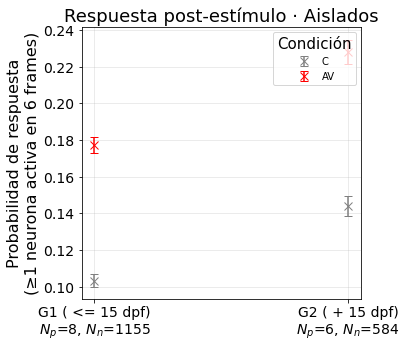

In [ ]:
# ================================================================
# Gráfico de probabilidad de respuesta con SEM, Np y Nn
# ================================================================

solo_social = False
if solo_social:
    df_print = df_soc
    colors = {"C": "gray", "AV": "blue"}
    marker_con = 'o'
else:
    df_print = df_ais
    colors = {"C": "gray", "AV": "red"}
    marker_con = 'x'

# --- Resumen ---
summary = (df_print
           .groupby(["grupo","cond"])
           .agg(mean_prob=("respuesta","mean"),
                sd_prob=("respuesta","std"),
                n=("respuesta","count"))
           .reset_index())
summary["sem_prob"] = summary["sd_prob"] / np.sqrt(summary["n"])

# --- Orden dinámico: solo grupos con datos ---
order = [g for g in grupos.keys() if g in summary["grupo"].unique()]

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(5,5))

for cond in ["C", "AV"]:
    sub = summary[summary["cond"] == cond]
    x = [order.index(g) for g in sub["grupo"]]
    ax.errorbar(x, sub["mean_prob"], yerr=sub["sem_prob"],
                fmt='o', color=colors[cond], label=cond,
                capsize=4, markersize=8, marker=marker_con)

# Etiquetas de grupos con Np y Nn
xticks, xticklabels = [], []
for i, g in enumerate(order):
    df_g = df_print[df_print["grupo"] == g]
    n_fish = df_g["fish_id"].nunique()
    n_neurons = df_g[["fish_id","roi_id"]].drop_duplicates().shape[0]
    xticks.append(i)
    xticklabels.append(f"{g}\n$N_p$={n_fish}, $N_n$={n_neurons}")

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, fontsize=14)

# Títulos y ejes
ax.set_ylabel("Probabilidad de respuesta\n(≥1 neurona activa en 6 frames)", fontsize=16)
ax.set_title("Respuesta post-estímulo · " + ("Sociales" if solo_social else "Aislados"), fontsize=18)
ax.tick_params(axis="both", labelsize=14)

# Leyenda
ax.legend(title="Condición", fontsize=10, title_fontsize=15, loc="upper right")

# Grid y fondo
ax.grid(alpha=0.3)
fig.patch.set_facecolor("white")
plt.tight_layout()

# Guardar
# plt.savefig(f"PR_AV_vs_C_Social_{solo_social}.pdf", dpi=600, bbox_inches="tight")
plt.show()


# Tomemos la neuronas que responden al menos una vez en la ventana de estímulo


In [48]:
# ================================================================
# Parámetros principales
# ================================================================
region_key   = 'Hb'
stim_s       = 23.6     # segundo del estímulo
fps          = 6.25     # fps si no hay trial.frame_times
solo_social  = True      # True = solo sociales, False = solo aislados 
solo_sociales  = solo_social     # True = sociales, False = aislados
    # True = sociales, False = aislados
win_s      = 1.0          # ventana post-estímulo (s)
consistencia_en_trial =1 #Numero de veces q se prendio la neurona en la ventana en un trial >consistencia_en_trial
# Ventana de análisis alrededor del estímulo
frames_pre   = 3     # número de frames antes
frames_post  = 6        # número de frames después
# Grupos por edad (dpf)
# grupos = {
#     "G1 (6–8 dpf)":   lambda e: 6 <= e <= 8,
#     "G2 (12–13 dpf)": lambda e: 12 <= e <= 13,
#     "G3 (15–16 dpf)": lambda e: 15 <= e <= 16,
# }



In [25]:
# === Plots (3 figures: G1, G2, G3) =============================
for gname in grupos.keys():
    data = resultados[gname]
    mean_C, sem_C   = _mean_sem_over_animals(data['C']["animals"])
    mean_AV, sem_AV = _mean_sem_over_animals(data['AV']["animals"])

    # Time base for plotting
    tC = data['C']["t"]
    tA = data['AV']["t"]
    if mean_AV is not None:
        t_plot = tA[:len(mean_AV)]-stim_s
    elif mean_C is not None:
        t_plot = tC[:len(mean_C)]-stim_s
    else:
        print(f"[{gname}] No data.")
        continue

    w_idx = _window_indices(t_plot, stim_s, win_s)
    def _avg_win(x): return float(np.nanmean(x[w_idx])) if (x is not None and w_idx.any()) else np.nan
    avgC = _avg_win(mean_C) if mean_C is not None else np.nan
    avgA = _avg_win(mean_AV) if mean_AV is not None else np.nan
    delta = (avgA - avgC) if (not np.isnan(avgA) and not np.isnan(avgC)) else np.nan

    fig = plt.figure(figsize=(10, 5))
    # plt.title(f"Proportion of active neurons — {gname} · Social")
    plt.title(f"{gname} · {'Sociales' if solo_social else 'Aislados'}\n"
              f"$N_p$={len(data['C']['animals'])}")#, $N_n$={Nn}")

    if w_idx.any():
        plt.axvspan(t_plot[w_idx][0], t_plot[w_idx][-1], alpha=0.15, label=f"Window {win_s:.1f}s")
    plt.axvline(0, linestyle='--', linewidth=1, alpha=0.8, label="Stimulus")

    if mean_C is not None:
        plt.plot(
            t_plot, mean_C[:len(t_plot)],
            label=f"C",
            color='gray', marker='.'
        )
        if sem_C is not None:
            m = min(len(t_plot), len(sem_C))
            plt.fill_between(
                t_plot[:m], mean_C[:m]-sem_C[:m], mean_C[:m]+sem_C[:m],
                alpha=0.2, color='gray'
            )

    if mean_AV is not None:
        if solo_sociales:
            color = 'blue'
        else:
            color = 'red'
        plt.plot(
            t_plot, mean_AV[:len(t_plot)],
            label=f"AV",
            color=color, marker='.'
        )
        if sem_AV is not None:
            m = min(len(t_plot), len(sem_AV))
            plt.fill_between(
                t_plot[:m], mean_AV[:m]-sem_AV[:m], mean_AV[:m]+sem_AV[:m],
                alpha=0.2, color=color
            )

    plt.xlabel("Time (s)")
    plt.ylabel("Active proportion")
    plt.ylim(.02, .16)
    plt.xlim(-6, 6)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    fig.patch.set_facecolor('white')
    # plt.savefig(f'{gname}_Social_{solo_sociales}.pdf', dpi=300, bbox_inches='tight')


NameError: name 'resultados' is not defined

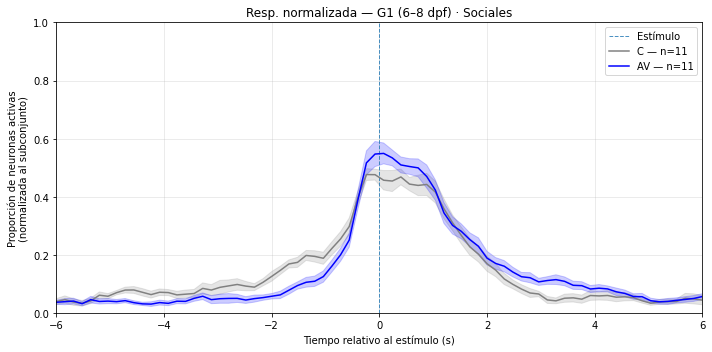

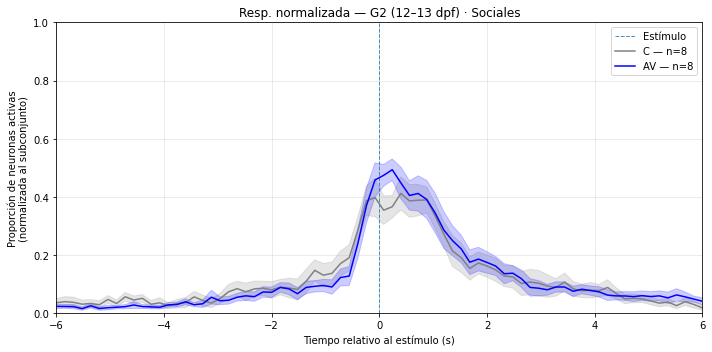

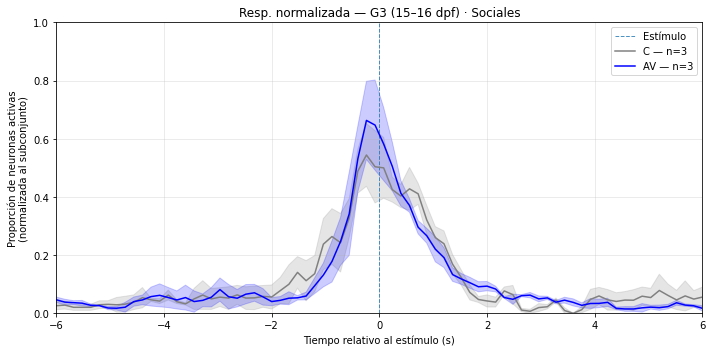

In [754]:
# Usamos las neuronas que respondan en cada condición

# Grupos por edad (dpf)
grupos = {
    "G1 (6–8 dpf)":   lambda e: 6 <= e <= 8,
    "G2 (12–13 dpf)": lambda e: 12 <= e <= 13,
    "G3 (15–16 dpf)": lambda e: 15 <= e <= 16,
}

# ================================================================
# Funciones auxiliares
# ================================================================
def _get_condition(trial):
    return 'AV' if getattr(trial, 'vis', 0)==1 and getattr(trial, 'aud', 0)==1 else 'C'

def _trial_timebase(trial, fallback_fps):
    """Devuelve vector de tiempos y fps estimado."""
    ft = getattr(trial, 'frame_times', None)
    if ft is not None and len(ft) > 1:
        ft = np.asarray(ft, float)
        fps_est = 1.0 / np.median(np.diff(ft))
        return ft, fps_est
    else:
        t_fps = getattr(trial, 'fps', None) or fallback_fps
        rb = getattr(trial, 'roi_binaries_rea2', None)
        if rb is None or region_key not in rb:
            raise ValueError(f"Falta roi_binaries_rea2['{region_key}']")
        arr = np.asarray(rb[region_key])
        n_frames = arr.shape[1]
        t = np.arange(n_frames, dtype=float) / float(t_fps)
        return t, float(t_fps)

def _truncate_to_common_length(list_of_arrays):
    L = [len(a) for a in list_of_arrays if a is not None]
    if not L:
        return [], 0
    m = min(L)
    return [a[:m] for a in list_of_arrays if a is not None], m

def _mean_sem_over_animals(animal_traces):
    if len(animal_traces) == 0:
        return None, None
    X, L = _truncate_to_common_length(animal_traces)
    if L == 0:
        return None, None
    M = np.vstack(X)
    mean = M.mean(axis=0)
    sem  = M.std(axis=0, ddof=1)/np.sqrt(M.shape[0]) if M.shape[0]>1 else np.zeros_like(mean)
    return mean, sem

# ================================================================
# Procesamiento
# ================================================================
# Selección de animales
keys = [k for k,a in areas.items() if getattr(a,'aislado',1) == (0 if solo_social else 1)]

resultados = {g: {"C":{"animals":[], "t":None}, "AV":{"animals":[], "t":None}}
              for g in grupos.keys()}

for k in keys:
    area = areas[k]
    edad = int(getattr(area,'edad',-999))

    # Asignar grupo etario
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue

    per_trial = {"C":[], "AV":[]}
    per_time  = {"C":[], "AV":[]}

    for tr in getattr(area,'trials_rea',[]):
        cond = _get_condition(tr)
        try:
            t, tr_fps = _trial_timebase(tr, fps)
        except Exception:
            continue

        stim_frame = int(round(stim_s * tr_fps))
        win_idx = np.arange(stim_frame-frames_pre, stim_frame+frames_post+1)
        if win_idx.min()<0 or win_idx.max()>=len(t):
            continue

        rb = getattr(tr,'roi_binaries_rea2',None)
        if rb is None or region_key not in rb:
            continue
        B = np.asarray(rb[region_key])   # (n_rois, n_frames)
        if B.ndim!=2:
            continue
        B = (B>0).astype(float)

        # Seleccionar solo neuronas que se prendieron al menos una vez en la ventana
        active_mask = B[:,win_idx].sum(axis=1) >consistencia_en_trial
        if not active_mask.any():
            continue
        B_sel = B[active_mask,:]

        # Proporción de esas neuronas activas en cada frame
        prop = B_sel.mean(axis=0)

        m = min(len(t), len(prop))
        per_trial[cond].append(prop[:m])
        per_time[cond].append(t[:m])

    # Promedio por animal y condición
    for cond in ['C','AV']:
        if len(per_trial[cond]) == 0:
            continue
        series, m = _truncate_to_common_length(per_trial[cond])
        if m==0:
            continue
        tseries, _ = _truncate_to_common_length(per_time[cond])
        t_common = tseries[0] if len(tseries)>0 else np.arange(m)/tr_fps
        animal_mean = np.vstack(series).mean(axis=0)

        resultados[gname][cond]['animals'].append(animal_mean)
        if resultados[gname][cond]['t'] is None:
            resultados[gname][cond]['t'] = t_common

# ================================================================
# Gráficos
# ================================================================
for gname in grupos.keys():
    data = resultados[gname]
    mean_C, sem_C   = _mean_sem_over_animals(data['C']["animals"])
    mean_AV, sem_AV = _mean_sem_over_animals(data['AV']["animals"])

    tC = data['C']["t"]
    tA = data['AV']["t"]
    if mean_AV is not None:
        t_plot = tA[:len(mean_AV)] - stim_s
    elif mean_C is not None:
        t_plot = tC[:len(mean_C)] - stim_s
    else:
        print(f"[{gname}] Sin datos.")
        continue

    fig = plt.figure(figsize=(10,5))
    plt.title(f"Resp. normalizada — {gname} · {'Sociales' if solo_social else 'Aislados'}")
    plt.axvline(0, linestyle='--', linewidth=1, alpha=0.8, label="Estímulo")

    if mean_C is not None:
        plt.plot(t_plot, mean_C[:len(t_plot)], label=f"C — n={len(data['C']['animals'])}",
                 color='gray')
        if sem_C is not None:
            m = min(len(t_plot), len(sem_C))
            plt.fill_between(t_plot[:m], mean_C[:m]-sem_C[:m], mean_C[:m]+sem_C[:m], alpha=0.2,
                             color='gray')

    if mean_AV is not None:
        color = 'blue' if solo_social else 'red'
        plt.plot(t_plot, mean_AV[:len(t_plot)], label=f"AV — n={len(data['AV']['animals'])}",
                 color=color)
        if sem_AV is not None:
            m = min(len(t_plot), len(sem_AV))
            plt.fill_between(t_plot[:m], mean_AV[:m]-sem_AV[:m], mean_AV[:m]+sem_AV[:m], alpha=0.2,
                             color=color)

    plt.xlabel("Tiempo relativo al estímulo (s)")
    plt.ylabel("Proporción de neuronas activas\n(normalizada al subconjunto)")
    plt.ylim(0,1)
    # plt.xlim(-frames_pre/float(fps), frames_post/float(fps))
    plt.xlim(-6, 6)
    plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
    fig.patch.set_facecolor('white')
    plt.show()


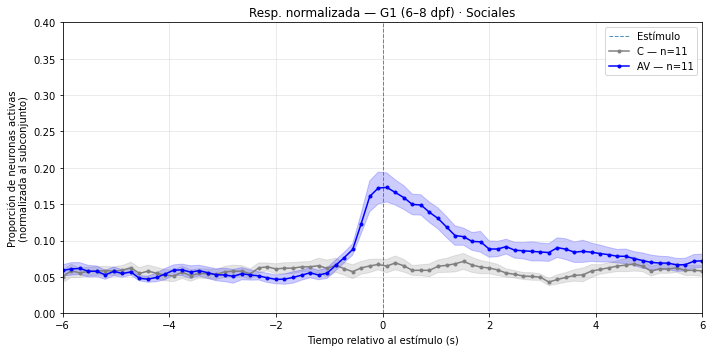

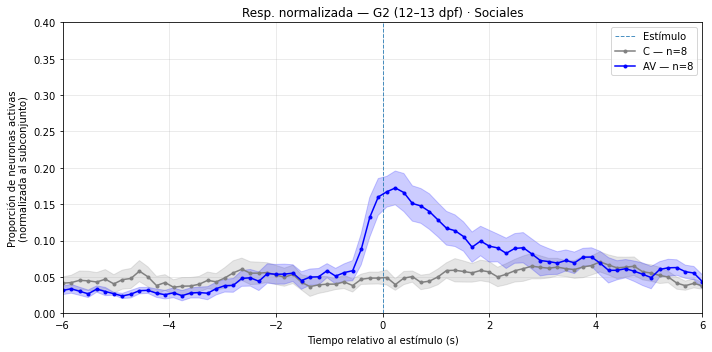

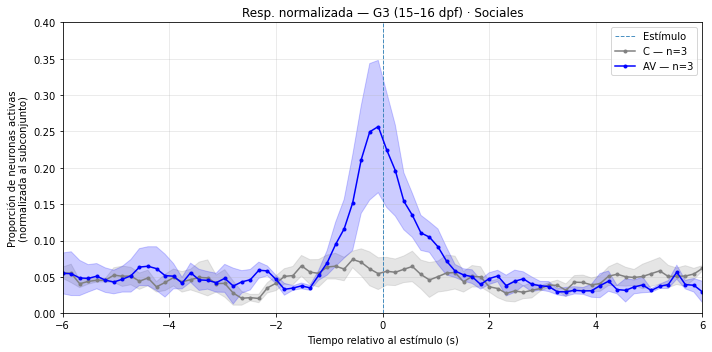

In [755]:
# ================================================================
# Procesamiento (usando neuronas detectadas en AV para ambos cond)
# ================================================================
keys = [k for k,a in areas.items() if getattr(a,'aislado',1) == (0 if solo_social else 1)]

resultados = {g: {"C":{"animals":[], "t":None}, "AV":{"animals":[], "t":None}}
              for g in grupos.keys()}

for k in keys:
    area = areas[k]
    edad = int(getattr(area,'edad',-999))

    # Asignar grupo etario
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue

    # ----------------------------------------------------------------
    # Paso 1: identificar neuronas activas en AV (ventana alrededor stim)
    # ----------------------------------------------------------------
    active_mask_global = None
    tr_fps_global = None
    t_global = None

    for tr in getattr(area,'trials_rea',[]):
        cond = _get_condition(tr)
        if cond != "AV":
            continue

        try:
            t, tr_fps = _trial_timebase(tr, fps)
        except Exception:
            continue

        stim_frame = int(round(stim_s * tr_fps))
        win_idx = np.arange(stim_frame-frames_pre, stim_frame+frames_post+1)
        if win_idx.min()<0 or win_idx.max()>=len(t):
            continue

        rb = getattr(tr,'roi_binaries_rea2',None)
        if rb is None or region_key not in rb:
            continue
        B = np.asarray(rb[region_key])
        if B.ndim!=2:
            continue
        B = (B>0).astype(float)

        active_mask = B[:,win_idx].sum(axis=1) > consistencia_en_trial
        if active_mask_global is None:
            active_mask_global = active_mask
        else:
            active_mask_global = active_mask_global | active_mask

        tr_fps_global = tr_fps
        t_global = t

    # Si no se activó ninguna neurona en AV → skip
    if active_mask_global is None or not active_mask_global.any():
        continue

    # ----------------------------------------------------------------
    # Paso 2: calcular curvas para C y AV usando ese subconjunto
    # ----------------------------------------------------------------
    per_trial = {"C":[], "AV":[]}
    per_time  = {"C":[], "AV":[]}

    for tr in getattr(area,'trials_rea',[]):
        cond = _get_condition(tr)
        try:
            t, tr_fps = _trial_timebase(tr, fps)
        except Exception:
            continue

        rb = getattr(tr,'roi_binaries_rea2',None)
        if rb is None or region_key not in rb:
            continue
        B = np.asarray(rb[region_key])
        if B.ndim!=2:
            continue
        B = (B>0).astype(float)

        B_sel = B[active_mask_global,:]
        if B_sel.shape[0]==0:
            continue

        prop = B_sel.mean(axis=0)
        m = min(len(t), len(prop))
        per_trial[cond].append(prop[:m])
        per_time[cond].append(t[:m])

    # ----------------------------------------------------------------
    # Paso 3: promedio por animal y condición
    # ----------------------------------------------------------------
    for cond in ['C','AV']:
        if len(per_trial[cond])==0:
            continue
        series, m = _truncate_to_common_length(per_trial[cond])
        if m==0:
            continue
        tseries, _ = _truncate_to_common_length(per_time[cond])
        t_common = tseries[0] if len(tseries)>0 else np.arange(m)/tr_fps_global
        animal_mean = np.vstack(series).mean(axis=0)

        resultados[gname][cond]['animals'].append(animal_mean)
        if resultados[gname][cond]['t'] is None:
            resultados[gname][cond]['t'] = t_common


# ================================================================
# Gráficos
# ================================================================
for gname in grupos.keys():
    data = resultados[gname]
    mean_C, sem_C   = _mean_sem_over_animals(data['C']["animals"])
    mean_AV, sem_AV = _mean_sem_over_animals(data['AV']["animals"])

    tC = data['C']["t"]
    tA = data['AV']["t"]
    if mean_AV is not None:
        t_plot = tA[:len(mean_AV)] - stim_s
    elif mean_C is not None:
        t_plot = tC[:len(mean_C)] - stim_s
    else:
        print(f"[{gname}] Sin datos.")
        continue

    fig = plt.figure(figsize=(10,5))
    plt.title(f"Resp. normalizada — {gname} · {'Sociales' if solo_social else 'Aislados'}")
    plt.axvline(0, linestyle='--', linewidth=1, alpha=0.8, label="Estímulo")

    if mean_C is not None:
        plt.plot(t_plot, mean_C[:len(t_plot)], label=f"C — n={len(data['C']['animals'])}",
                 color='gray', marker = '.')
        if sem_C is not None:
            m = min(len(t_plot), len(sem_C))
            plt.fill_between(t_plot[:m], mean_C[:m]-sem_C[:m], mean_C[:m]+sem_C[:m], alpha=0.2,
                             color='gray')

    if mean_AV is not None:
        color = 'blue' if solo_social else 'red'
        plt.plot(t_plot, mean_AV[:len(t_plot)], label=f"AV — n={len(data['AV']['animals'])}",
                 color=color, marker = '.')
        if sem_AV is not None:
            m = min(len(t_plot), len(sem_AV))
            plt.fill_between(t_plot[:m], mean_AV[:m]-sem_AV[:m], mean_AV[:m]+sem_AV[:m], alpha=0.2,
                             color=color)

    plt.xlabel("Tiempo relativo al estímulo (s)")
    plt.ylabel("Proporción de neuronas activas\n(normalizada al subconjunto)")
    plt.ylim(0,.4)
    # plt.xlim(-frames_pre/float(fps), frames_post/float(fps))
    plt.xlim(-6, 6)
    plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
    fig.patch.set_facecolor('white')
    # plt.savefig(f'{gname}_Sociales_{solo_sociales}_+.pdf', dpi=300, bbox_inches='tight')

    plt.show()


In [756]:
# ================================================================
# Procesamiento (usando neuronas detectadas en AV para ambos cond)
# ================================================================
keys = [k for k,a in areas.items() if getattr(a,'aislado',1) == (0 if solo_social else 1)]

resultados = {g: {"C":{"animals":[], "t":None},
                  "AV":{"animals":[], "t":None},
                  "Np":0, "Nn":0, "Nn_plus":0}
              for g in grupos.keys()}

for k in keys:
    area = areas[k]
    edad = int(getattr(area,'edad',-999))

    # Asignar grupo etario
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue

    # ----------------------------------------------------------------
    # Paso 1: identificar neuronas activas en AV (ventana alrededor stim)
    # ----------------------------------------------------------------
    active_mask_global = None
    tr_fps_global = None
    t_global = None
    total_neurons = None  # número de ROIs en este pez

    for tr in getattr(area,'trials_rea',[]):
        cond = _get_condition(tr)
        if cond != "AV":
            continue

        try:
            t, tr_fps = _trial_timebase(tr, fps)
        except Exception:
            continue

        stim_frame = int(round(stim_s * tr_fps))
        win_idx = np.arange(stim_frame-frames_pre, stim_frame+frames_post+1)
        if win_idx.min()<0 or win_idx.max()>=len(t):
            continue

        rb = getattr(tr,'roi_binaries_rea2',None)
        if rb is None or region_key not in rb:
            continue
        B = np.asarray(rb[region_key])
        if B.ndim!=2:
            continue
        B = (B>0).astype(float)

        total_neurons = B.shape[0]  # total ROIs del pez
        
        active_mask = B[:,win_idx].sum(axis=1) > consistencia_en_trial
        if active_mask_global is None:
            active_mask_global = active_mask
        else:
            active_mask_global = active_mask_global | active_mask

        tr_fps_global = tr_fps
        t_global = t

    # Si no se activó ninguna neurona en AV → skip
    if active_mask_global is None or not active_mask_global.any():
        continue

    # ----------------------------------------------------------------
    # Contadores Np, Nn, Nn+
    # ----------------------------------------------------------------
    resultados[gname]["Np"] += 1                         # este pez
    resultados[gname]["Nn"] += total_neurons             # todas las ROIs del pez
    resultados[gname]["Nn_plus"] += int(active_mask_global.sum())  # activas en ventana

    # ----------------------------------------------------------------
    # Paso 2: calcular curvas para C y AV usando ese subconjunto
    # ----------------------------------------------------------------
    per_trial = {"C":[], "AV":[]}
    per_time  = {"C":[], "AV":[]}

    for tr in getattr(area,'trials_rea',[]):
        cond = _get_condition(tr)
        try:
            t, tr_fps = _trial_timebase(tr, fps)
        except Exception:
            continue

        rb = getattr(tr,'roi_binaries_rea2',None)
        if rb is None or region_key not in rb:
            continue
        B = np.asarray(rb[region_key])
        if B.ndim!=2:
            continue
        B = (B>0).astype(float)

        B_sel = B[active_mask_global,:]
        if B_sel.shape[0]==0:
            continue

        prop = B_sel.mean(axis=0)
        m = min(len(t), len(prop))
        per_trial[cond].append(prop[:m])
        per_time[cond].append(t[:m])

    # ----------------------------------------------------------------
    # Paso 3: promedio por animal y condición
    # ----------------------------------------------------------------
    for cond in ['C','AV']:
        if len(per_trial[cond])==0:
            continue
        series, m = _truncate_to_common_length(per_trial[cond])
        if m==0:
            continue
        tseries, _ = _truncate_to_common_length(per_time[cond])
        t_common = tseries[0] if len(tseries)>0 else np.arange(m)/tr_fps_global
        animal_mean = np.vstack(series).mean(axis=0)

        resultados[gname][cond]['animals'].append(animal_mean)
        if resultados[gname][cond]['t'] is None:
            resultados[gname][cond]['t'] = t_common


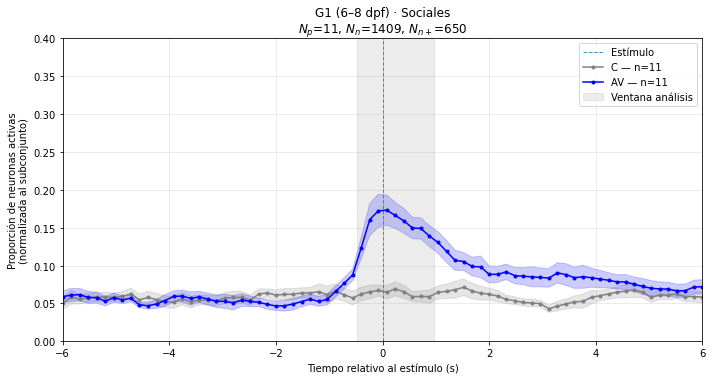

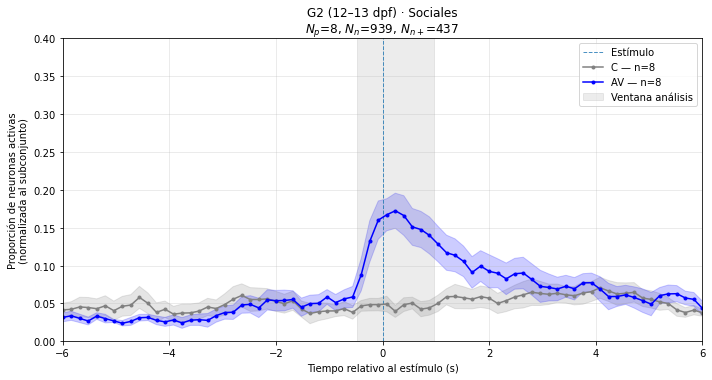

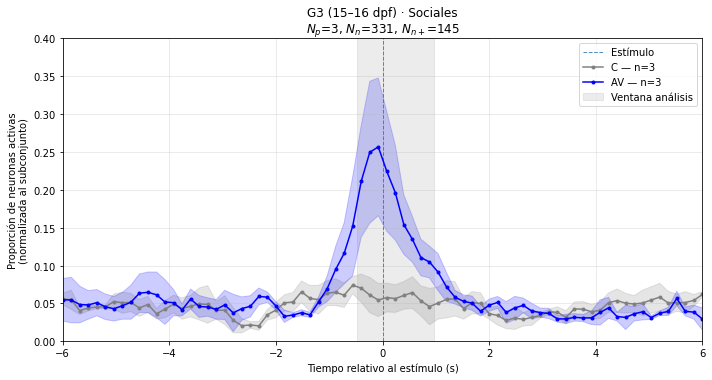

In [757]:
# ================================================================
# Gráficos con sombreado de ventana y Np, Nn, Nn+
# ================================================================
for gname in grupos.keys():
    data = resultados[gname]
    mean_C, sem_C   = _mean_sem_over_animals(data['C']["animals"])
    mean_AV, sem_AV = _mean_sem_over_animals(data['AV']["animals"])

    if mean_AV is not None:
        t_plot = data['AV']["t"][:len(mean_AV)] - stim_s
    elif mean_C is not None:
        t_plot = data['C']["t"][:len(mean_C)] - stim_s
    else:
        print(f"[{gname}] Sin datos.")
        continue

    # --- contadores
    Np      = data["Np"]
    Nn      = data["Nn"]
    Nn_plus = data["Nn_plus"]

    fig = plt.figure(figsize=(10,5))
    plt.axvline(0, linestyle='--', linewidth=1, alpha=0.8, label="Estímulo")

    # sombreado ventana
    plt.axvspan(-frames_pre/float(fps), frames_post/float(fps), 
                color="gray", alpha=0.15, label="Ventana análisis")

    # Curva C
    if mean_C is not None:
        plt.plot(t_plot, mean_C[:len(t_plot)], 
                 label=f"C — n={len(data['C']['animals'])}", 
                 color='gray', marker='.')
        m = min(len(t_plot), len(sem_C)) if sem_C is not None else 0
        if m>0:
            plt.fill_between(t_plot[:m], mean_C[:m]-sem_C[:m], mean_C[:m]+sem_C[:m],
                             alpha=0.2, color='gray')

    # Curva AV
    if mean_AV is not None:
        color = 'blue' if solo_social else 'red'
        plt.plot(t_plot, mean_AV[:len(t_plot)], 
                 label=f"AV — n={len(data['AV']['animals'])}", 
                 color=color, marker='.')
        m = min(len(t_plot), len(sem_AV)) if sem_AV is not None else 0
        if m>0:
            plt.fill_between(t_plot[:m], mean_AV[:m]-sem_AV[:m], mean_AV[:m]+sem_AV[:m],
                             alpha=0.2, color=color)

    plt.xlabel("Tiempo relativo al estímulo (s)")
    plt.ylabel("Proporción de neuronas activas\n(normalizada al subconjunto)")
    plt.ylim(0, .4)
    plt.xlim(-6, 6)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    fig.patch.set_facecolor('white')

    # --- título con contadores
    plt.title(f"{gname} · {'Sociales' if solo_social else 'Aislados'}\n"
              f"$N_p$={Np}, $N_n$={Nn}, $N_{{n+}}$={Nn_plus}")

    plt.show()


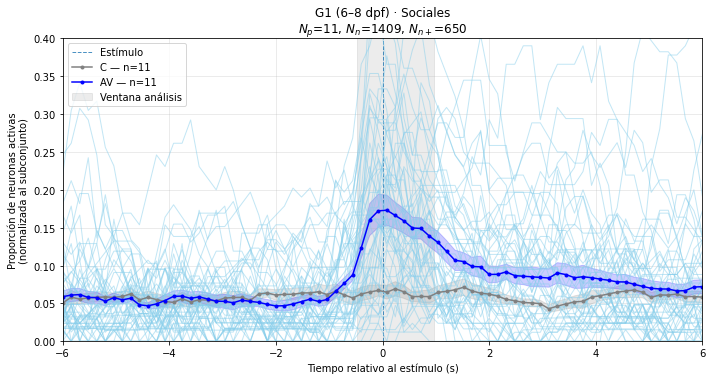

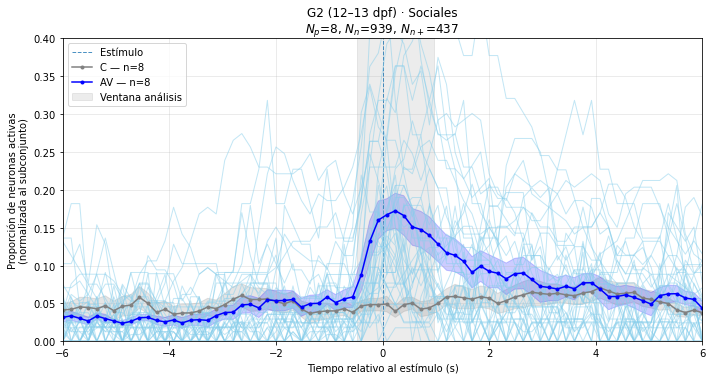

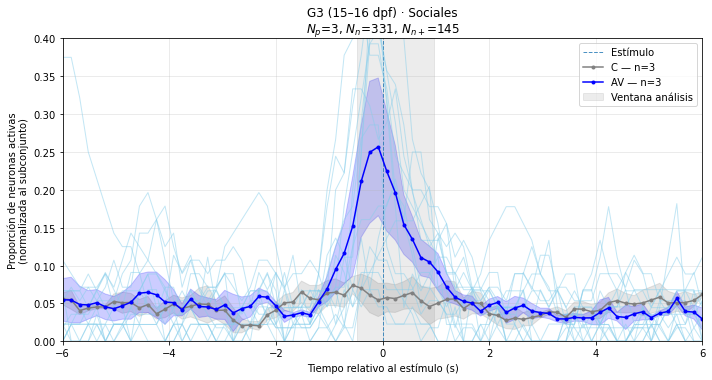

In [758]:
# ================================================================
# Procesamiento (usando neuronas detectadas en AV para ambos cond)
# ================================================================
keys = [k for k,a in areas.items() if getattr(a,'aislado',1) == (0 if solo_social else 1)]

resultados = {g: {"C":{"animals":[], "t":None, "trials":[]}, 
                  "AV":{"animals":[], "t":None, "trials":[]},
                  "Np":0, "Nn":0, "Nn_plus":0}
              for g in grupos.keys()}

for k in keys:
    area = areas[k]
    edad = int(getattr(area,'edad',-999))

    # Asignar grupo etario
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue

    # ----------------------------------------------------------------
    # Paso 1: identificar neuronas activas en AV (ventana alrededor stim)
    # ----------------------------------------------------------------
    active_mask_global = None
    tr_fps_global = None
    t_global = None

    for tr in getattr(area,'trials_rea',[]):
        cond = _get_condition(tr)
        if cond != "AV":
            continue

        try:
            t, tr_fps = _trial_timebase(tr, fps)
        except Exception:
            continue

        stim_frame = int(round(stim_s * tr_fps))
        win_idx = np.arange(stim_frame-frames_pre, stim_frame+frames_post+1)
        if win_idx.min()<0 or win_idx.max()>=len(t):
            continue

        rb = getattr(tr,'roi_binaries_rea2',None)
        if rb is None or region_key not in rb:
            continue
        B = np.asarray(rb[region_key])
        if B.ndim!=2:
            continue
        B = (B>0).astype(float)

        active_mask = B[:,win_idx].sum(axis=1) > consistencia_en_trial
        if active_mask_global is None:
            active_mask_global = active_mask
        else:
            active_mask_global = active_mask_global | active_mask

        tr_fps_global = tr_fps
        t_global = t

    # Si no se activó ninguna neurona en AV → skip
    if active_mask_global is None or not active_mask_global.any():
        continue

    # Contadores
    resultados[gname]["Np"] += 1
    resultados[gname]["Nn"] += active_mask_global.shape[0]
    resultados[gname]["Nn_plus"] += active_mask_global.sum()

    # ----------------------------------------------------------------
    # Paso 2: calcular curvas para C y AV usando ese subconjunto
    # ----------------------------------------------------------------
    per_trial = {"C":[], "AV":[]}
    per_time  = {"C":[], "AV":[]}

    for tr in getattr(area,'trials_rea',[]):
        cond = _get_condition(tr)
        try:
            t, tr_fps = _trial_timebase(tr, fps)
        except Exception:
            continue

        rb = getattr(tr,'roi_binaries_rea2',None)
        if rb is None or region_key not in rb:
            continue
        B = np.asarray(rb[region_key])
        if B.ndim!=2:
            continue
        B = (B>0).astype(float)

        B_sel = B[active_mask_global,:]
        if B_sel.shape[0]==0:
            continue

        prop = B_sel.mean(axis=0)
        m = min(len(t), len(prop))
        per_trial[cond].append(prop[:m])
        per_time[cond].append(t[:m])

    # ----------------------------------------------------------------
    # Paso 3: promedio por animal y guardamos también TODAS las trials
    # ----------------------------------------------------------------
    for cond in ['C','AV']:
        if len(per_trial[cond])==0:
            continue
        series, m = _truncate_to_common_length(per_trial[cond])
        if m==0:
            continue
        tseries, _ = _truncate_to_common_length(per_time[cond])
        t_common = tseries[0] if len(tseries)>0 else np.arange(m)/tr_fps_global

        # Promedio por animal
        animal_mean = np.vstack(series).mean(axis=0)
        resultados[gname][cond]['animals'].append(animal_mean)

        # Guardar TODAS las curvas trial-by-trial
        resultados[gname][cond]['trials'].extend(series)

        if resultados[gname][cond]['t'] is None:
            resultados[gname][cond]['t'] = t_common


# ================================================================
# Gráficos
# ================================================================
for gname in grupos.keys():
    data = resultados[gname]
    mean_C, sem_C   = _mean_sem_over_animals(data['C']["animals"])
    mean_AV, sem_AV = _mean_sem_over_animals(data['AV']["animals"])

    if mean_AV is not None:
        t_plot = data['AV']["t"][:len(mean_AV)] - stim_s
    elif mean_C is not None:
        t_plot = data['C']["t"][:len(mean_C)] - stim_s
    else:
        print(f"[{gname}] Sin datos.")
        continue

    # --- contadores
    Np      = data["Np"]
    Nn      = data["Nn"]
    Nn_plus = data["Nn_plus"]

    fig = plt.figure(figsize=(10,5))
    plt.axvline(0, linestyle='--', linewidth=1, alpha=0.8, label="Estímulo")

    # sombreado ventana
    plt.axvspan(-frames_pre/float(fps), frames_post/float(fps), 
                color="gray", alpha=0.15, label="Ventana análisis")

    # --- Curvas trial individuales AV (todas, celeste claro)
    if "trials" in data["AV"]:
        for trial_curve in data["AV"]["trials"]:
            m = min(len(t_plot), len(trial_curve))
            plt.plot(t_plot[:m], trial_curve[:m],
                     color="skyblue", alpha=0.5, linewidth=1)

    # Curva C (media ± SEM)
    if mean_C is not None:
        plt.plot(t_plot, mean_C[:len(t_plot)], 
                 label=f"C — n={len(data['C']['animals'])}", 
                 color='gray', marker='.')
        m = min(len(t_plot), len(sem_C)) if sem_C is not None else 0
        if m>0:
            plt.fill_between(t_plot[:m], mean_C[:m]-sem_C[:m], mean_C[:m]+sem_C[:m],
                             alpha=0.2, color='gray')

    # Curva AV (media ± SEM)
    if mean_AV is not None:
        color = 'blue' if solo_social else 'red'
        plt.plot(t_plot, mean_AV[:len(t_plot)], 
                 label=f"AV — n={len(data['AV']['animals'])}", 
                 color=color, marker='.')
        m = min(len(t_plot), len(sem_AV)) if sem_AV is not None else 0
        if m>0:
            plt.fill_between(t_plot[:m], mean_AV[:m]-sem_AV[:m], mean_AV[:m]+sem_AV[:m],
                             alpha=0.2, color=color)

    plt.xlabel("Tiempo relativo al estímulo (s)")
    plt.ylabel("Proporción de neuronas activas\n(normalizada al subconjunto)")
    plt.ylim(0,.4)
    plt.xlim(-6, 6)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    fig.patch.set_facecolor('white')

    # --- título con contadores
    plt.title(f"{gname} · {'Sociales' if solo_social else 'Aislados'}\n"
              f"$N_p$={Np}, $N_n$={Nn}, $N_{{n+}}$={Nn_plus}")

    plt.show()


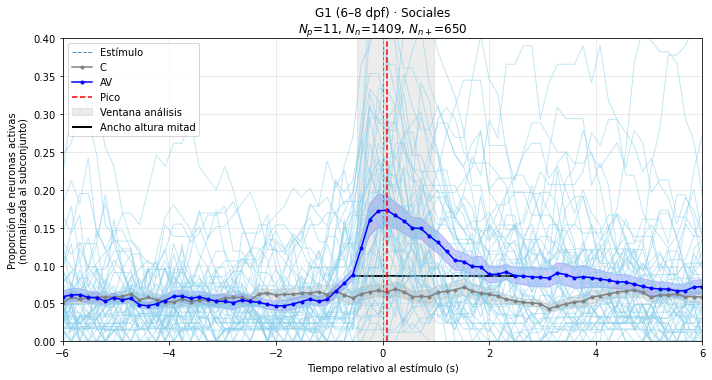

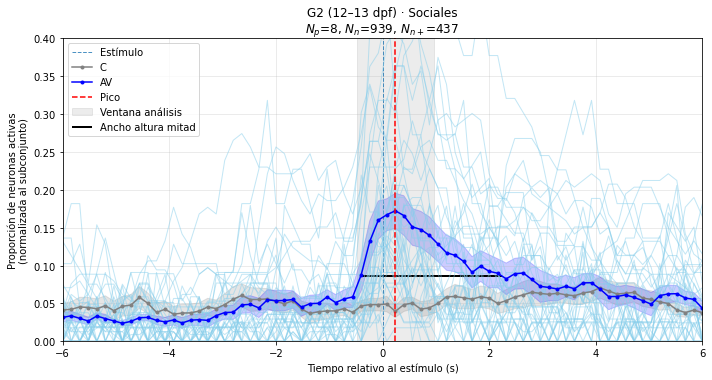

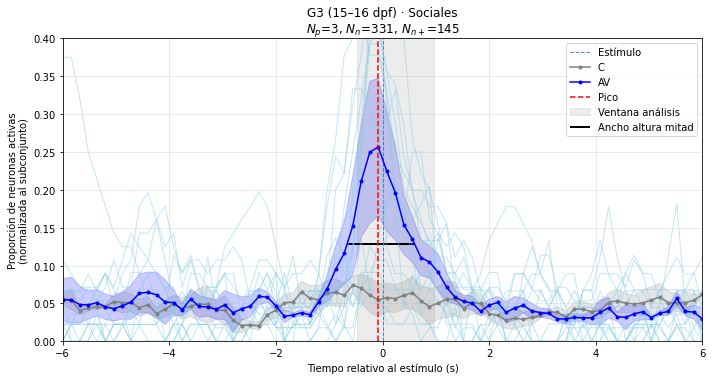

In [759]:
from scipy.interpolate import interp1d
def calcular_metrica_curva(t, y, stim_window=(-1, 3)):
    """
    Calcula pico, delay y ancho a mitad de altura (FWHM).
    Busca solo los cruces inmediatos alrededor del pico.
    """
    mask = (t >= stim_window[0]) & (t <= stim_window[1])
    if not mask.any():
        return None
    t_win, y_win = t[mask], y[mask]

    # Pico
    peak_idx = np.argmax(y_win)
    peak_val = y_win[peak_idx]
    delay    = t_win[peak_idx]

    # FWHM
    half_height = peak_val / 2.0

    # --- Izquierda del pico ---
    fwhm_left = np.nan
    for i in range(peak_idx, 0, -1):  # desde el pico hacia atrás
        if (y_win[i]-half_height)*(y_win[i-1]-half_height) < 0:
            f = interp1d([y_win[i-1], y_win[i]], [t_win[i-1], t_win[i]])
            fwhm_left = float(f(half_height))
            break

    # --- Derecha del pico ---
    fwhm_right = np.nan
    for i in range(peak_idx, len(y_win)-1):  # desde el pico hacia adelante
        if (y_win[i]-half_height)*(y_win[i+1]-half_height) < 0:
            f = interp1d([y_win[i], y_win[i+1]], [t_win[i], t_win[i+1]])
            fwhm_right = float(f(half_height))
            break

    return {"peak_val": peak_val, "delay": delay,
            "fwhm_left": fwhm_left, "fwhm_right": fwhm_right}

# def calcular_metrica_curva(t, y, stim_window=(-1, 3)):
#     """
#     Calcula pico, delay y ancho a mitad de altura (FWHM).
#     t: tiempo relativo (s)
#     y: curva promedio (array)
#     stim_window: ventana de análisis en segundos
#     """
#     mask = (t >= stim_window[0]) & (t <= stim_window[1])
#     if not mask.any():
#         return None
#     t_win, y_win = t[mask], y[mask]

#     # Pico
#     peak_idx = np.argmax(y_win)
#     peak_val = y_win[peak_idx]
#     delay    = t_win[peak_idx]

#     # FWHM
#     half_height = peak_val / 2.0
#     roots = []
#     for i in range(len(t_win)-1):
#         if (y_win[i]-half_height)*(y_win[i+1]-half_height) < 0:
#             f = interp1d([y_win[i], y_win[i+1]], [t_win[i], t_win[i+1]])
#             roots.append(float(f(half_height)))
#     if len(roots) >= 2:
#         fwhm_left, fwhm_right = roots[0], roots[-1]
#     else:
#         fwhm_left, fwhm_right = np.nan, np.nan

#     return {"peak_val": peak_val, "delay": delay,
#             "fwhm_left": fwhm_left, "fwhm_right": fwhm_right}


# ================================================================
# Gráficos con métricas AV (pico + FWHM)
# ================================================================
for gname in grupos.keys():
    data = resultados[gname]
    mean_C, sem_C   = _mean_sem_over_animals(data['C']["animals"])
    mean_AV, sem_AV = _mean_sem_over_animals(data['AV']["animals"])

    if mean_AV is not None:
        t_plot = data['AV']["t"][:len(mean_AV)] - stim_s
    elif mean_C is not None:
        t_plot = data['C']["t"][:len(mean_C)] - stim_s
    else:
        print(f"[{gname}] Sin datos.")
        continue

    # --- contadores
    Np      = data["Np"]
    Nn      = data["Nn"]
    Nn_plus = data["Nn_plus"]

    fig = plt.figure(figsize=(10,5))
    plt.axvline(0, linestyle='--', linewidth=1, alpha=0.8, label="Estímulo")

    # sombreado ventana de análisis
    plt.axvspan(-frames_pre/float(fps), frames_post/float(fps), 
                color="gray", alpha=0.15, label="Ventana análisis")

    # --- Curvas trial individuales AV (celeste claro)
    if "trials" in data["AV"]:
        for trial_curve in data["AV"]["trials"]:
            m = min(len(t_plot), len(trial_curve))
            plt.plot(t_plot[:m], trial_curve[:m],
                     color="skyblue", alpha=0.5, linewidth=1)

    # Curva C (media ± SEM)
    if mean_C is not None:
        plt.plot(t_plot, mean_C[:len(t_plot)], 
                 label=f"C", 
                 color='gray', marker='.')
        m = min(len(t_plot), len(sem_C)) if sem_C is not None else 0
        if m>0:
            plt.fill_between(t_plot[:m], mean_C[:m]-sem_C[:m], mean_C[:m]+sem_C[:m],
                             alpha=0.2, color='gray')

    # Curva AV (media ± SEM)
    if mean_AV is not None:
        color = 'blue' if solo_social else 'red'
        plt.plot(t_plot, mean_AV[:len(t_plot)], 
                 label=f"AV", 
                 color=color, marker='.')
        m = min(len(t_plot), len(sem_AV)) if sem_AV is not None else 0
        if m>0:
            plt.fill_between(t_plot[:m], mean_AV[:m]-sem_AV[:m], mean_AV[:m]+sem_AV[:m],
                             alpha=0.2, color=color)

        # --- métricas en AV ---
        met = calcular_metrica_curva(t_rel, mean_AV, stim_window=(-1*frames_pre, frames_post))
        if met:
            # línea punteada en el pico
            plt.axvline(met["delay"], linestyle="--", color="red", linewidth=1.5, label=f"Pico",)
            # plt.plot(met["delay"], met["peak_val"], "ro")

            # barra horizontal en FWHM
            if not np.isnan(met["fwhm_left"]) and not np.isnan(met["fwhm_right"]):
                plt.hlines(met["peak_val"]/2, met["fwhm_left"], met["fwhm_right"],
                           colors="black", linewidth=2, label=f"Ancho altura mitad",)

    plt.xlabel("Tiempo relativo al estímulo (s)")
    plt.ylabel("Proporción de neuronas activas\n(normalizada al subconjunto)")
    plt.ylim(0,.4)
    plt.xlim(-6, 6)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    fig.patch.set_facecolor('white')

    # --- título con contadores
    plt.title(f"{gname} · {'Sociales' if solo_social else 'Aislados'}\n"
              f"$N_p$={Np}, $N_n$={Nn}, $N_{{n+}}$={Nn_plus}")
    # plt.savefig(f'{gname}_Sociales_{solo_sociales}_++.pdf', dpi=300, bbox_inches='tight')

    plt.show()


In [760]:
rows = []
for gname in grupos.keys():
    data = resultados[gname]
    mean_AV, sem_AV = _mean_sem_over_animals(data['AV']["animals"])
    if mean_AV is None: 
        continue

    t = data['AV']["t"]
    t_rel = t[:len(mean_AV)] - stim_s
    met =  calcular_metrica_curva(t_rel, mean_AV, stim_window=(-1*frames_pre, frames_post))
    if met is None: 
        continue

    rows.append({
        "Grupo": gname,
        "Peak": f"{met['peak_val']:.3f}",
        "Delay (s)": f"{met['delay']:.2f}",
        "FWHM (s)": f"{(met['fwhm_right']-met['fwhm_left']):.2f}"
    })

tabla_resumen = pd.DataFrame(rows)
print(tabla_resumen)


            Grupo   Peak Delay (s) FWHM (s)
0    G1 (6–8 dpf)  0.173      0.08     3.09
1  G2 (12–13 dpf)  0.172      0.24     2.65
2  G3 (15–16 dpf)  0.257     -0.08     1.27


# Agreguemos consistencia

In [761]:
consistencia_repeticion =2
consistencia_en_trial =0
# ================================================================
# Procesamiento (usando neuronas detectadas en AV para ambos cond)
# ================================================================
keys = [k for k,a in areas.items() if getattr(a,'aislado',1) == (0 if solo_social else 1)]

resultados = {g: {"C":{"animals":[], "t":None},
                  "AV":{"animals":[], "t":None},
                  "Np":0, "Nn":0, "Nn_plus":0}
              for g in grupos.keys()}

for k in keys:
    area = areas[k]
    edad = int(getattr(area,'edad',-999))

    # Asignar grupo etario
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue

    # ----------------------------------------------------------------
    # Paso 1: identificar neuronas activas en AV (ventana alrededor stim)
    # ----------------------------------------------------------------
    active_mask_global = None
    tr_fps_global = None
    t_global = None
    total_neurons = None  # número de ROIs en este pez

    # --- Inicialización de contadores de neuronas activas en varios trials ---
    active_counts = None   # cuántos trials cumplen el criterio para cada neurona
    total_neurons = None
    tr_fps_global = None
    t_global = None

    for tr in getattr(area,'trials_rea',[]):
        cond = _get_condition(tr)
        if cond != "AV":
            continue

        try:
            t, tr_fps = _trial_timebase(tr, fps)
        except Exception:
            continue

        stim_frame = int(round(stim_s * tr_fps))
        win_idx = np.arange(stim_frame-frames_pre, stim_frame+frames_post+1)
        if win_idx.min() < 0 or win_idx.max() >= len(t):
            continue

        rb = getattr(tr,'roi_binaries_rea2',None)
        if rb is None or region_key not in rb:
            continue
        B = np.asarray(rb[region_key])
        if B.ndim != 2:
            continue
        B = (B > 0).astype(float)

        total_neurons = B.shape[0]  # total ROIs del pez

        # --- criterio dentro del trial ---
        active_mask = (B[:, win_idx].sum(axis=1) > consistencia_en_trial)

        # --- acumular cuántos trials pasan el criterio por neurona ---
        if active_counts is None:
            active_counts = active_mask.astype(int)
        else:
            active_counts += active_mask.astype(int)

        tr_fps_global = tr_fps
        t_global = t

    # --- criterio entre trials ---
    if active_counts is not None:
        active_mask_global = active_counts >= consistencia_repeticion
    else:
        active_mask_global = None


    # Si no se activó ninguna neurona en AV → skip
    if active_mask_global is None or not active_mask_global.any():
        continue

    # ----------------------------------------------------------------
    # Contadores Np, Nn, Nn+
    # ----------------------------------------------------------------
    resultados[gname]["Np"] += 1                         # este pez
    resultados[gname]["Nn"] += total_neurons             # todas las ROIs del pez
    resultados[gname]["Nn_plus"] += int(active_mask_global.sum())  # activas en ventana

    # ----------------------------------------------------------------
    # Paso 2: calcular curvas para C y AV usando ese subconjunto
    # ----------------------------------------------------------------
    per_trial = {"C":[], "AV":[]}
    per_time  = {"C":[], "AV":[]}

    for tr in getattr(area,'trials_rea',[]):
        cond = _get_condition(tr)
        try:
            t, tr_fps = _trial_timebase(tr, fps)
        except Exception:
            continue

        rb = getattr(tr,'roi_binaries_rea2',None)
        if rb is None or region_key not in rb:
            continue
        B = np.asarray(rb[region_key])
        if B.ndim!=2:
            continue
        B = (B>0).astype(float)

        B_sel = B[active_mask_global,:]
        if B_sel.shape[0]==0:
            continue

        prop = B_sel.mean(axis=0)
        m = min(len(t), len(prop))
        per_trial[cond].append(prop[:m])
        per_time[cond].append(t[:m])

    # ----------------------------------------------------------------
    # Paso 3: promedio por animal y condición
    # ----------------------------------------------------------------
    for cond in ['C','AV']:
        if len(per_trial[cond])==0:
            continue
        series, m = _truncate_to_common_length(per_trial[cond])
        if m==0:
            continue
        tseries, _ = _truncate_to_common_length(per_time[cond])
        t_common = tseries[0] if len(tseries)>0 else np.arange(m)/tr_fps_global
        animal_mean = np.vstack(series).mean(axis=0)

        resultados[gname][cond]['animals'].append(animal_mean)
        if resultados[gname][cond]['t'] is None:
            resultados[gname][cond]['t'] = t_common


In [762]:
list_mt = []

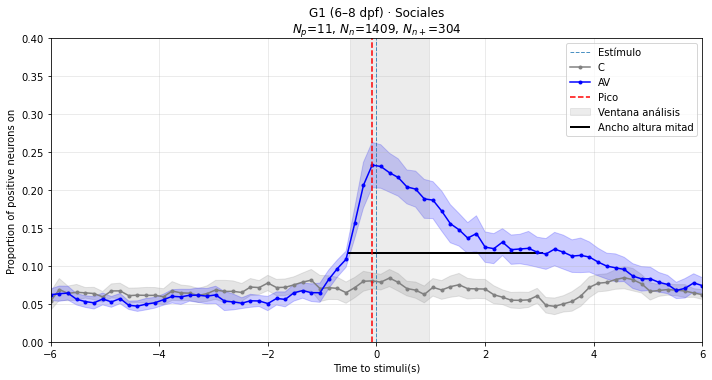

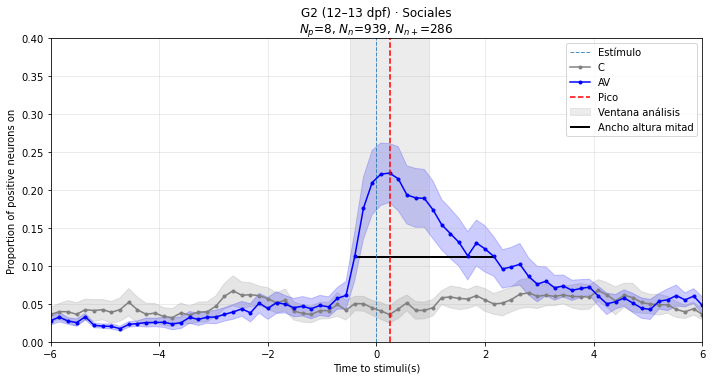

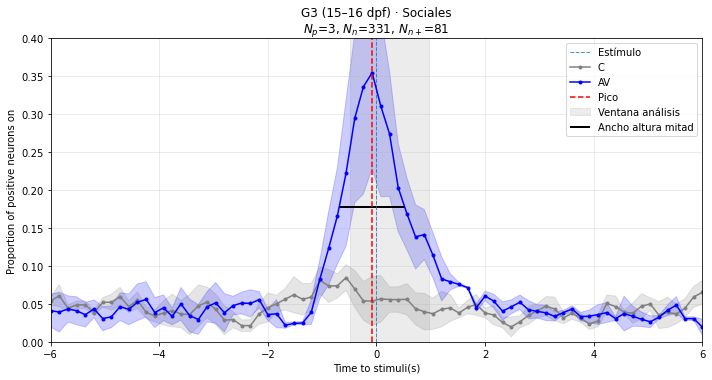

In [763]:
# ================================================================
# Gráficos con métricas AV (pico + FWHM)
# ================================================================
for gname in grupos.keys():
    data = resultados[gname]
    mean_C, sem_C   = _mean_sem_over_animals(data['C']["animals"])
    mean_AV, sem_AV = _mean_sem_over_animals(data['AV']["animals"])

    if mean_AV is not None:
        t_plot = data['AV']["t"][:len(mean_AV)] - stim_s
    elif mean_C is not None:
        t_plot = data['C']["t"][:len(mean_C)] - stim_s
    else:
        print(f"[{gname}] Sin datos.")
        continue

    # --- contadores
    Np      = data["Np"]
    Nn      = data["Nn"]
    Nn_plus = data["Nn_plus"]

    fig = plt.figure(figsize=(10,5))
    plt.axvline(0, linestyle='--', linewidth=1, alpha=0.8, label="Estímulo")

    # sombreado ventana de análisis
    plt.axvspan(-frames_pre/float(fps), frames_post/float(fps), 
                color="gray", alpha=0.15, label="Ventana análisis")

    # --- Curvas trial individuales AV (celeste claro)
    if "trials" in data["AV"]:
        for trial_curve in data["AV"]["trials"]:
            m = min(len(t_plot), len(trial_curve))
            plt.plot(t_plot[:m], trial_curve[:m],
                     color="skyblue", alpha=0.5, linewidth=1)

    # Curva C (media ± SEM)
    if mean_C is not None:
        plt.plot(t_plot, mean_C[:len(t_plot)], 
                 label=f"C", 
                 color='gray', marker='.')
        m = min(len(t_plot), len(sem_C)) if sem_C is not None else 0
        if m>0:
            plt.fill_between(t_plot[:m], mean_C[:m]-sem_C[:m], mean_C[:m]+sem_C[:m],
                             alpha=0.2, color='gray')

    # Curva AV (media ± SEM)
    if mean_AV is not None:
        color = 'blue' if solo_social else 'red'
        plt.plot(t_plot, mean_AV[:len(t_plot)], 
                 label=f"AV", 
                 color=color, marker='.')
        m = min(len(t_plot), len(sem_AV)) if sem_AV is not None else 0
        if m>0:
            plt.fill_between(t_plot[:m], mean_AV[:m]-sem_AV[:m], mean_AV[:m]+sem_AV[:m],
                             alpha=0.2, color=color)

        # --- métricas en AV ---
        met = calcular_metrica_curva(t_rel, mean_AV, stim_window=(-1*frames_pre, frames_post))
        if met:
            # línea punteada en el pico
            list_mt.append(met)
            plt.axvline(met["delay"], linestyle="--", color="red", linewidth=1.5, label=f"Pico",)
            # plt.plot(met["delay"], met["peak_val"], "ro")

            # barra horizontal en FWHM
            if not np.isnan(met["fwhm_left"]) and not np.isnan(met["fwhm_right"]):
                plt.hlines(met["peak_val"]/2, met["fwhm_left"], met["fwhm_right"],
                           colors="black", linewidth=2, label=f"Ancho altura mitad",)

    plt.xlabel("Time to stimuli(s)")
    plt.ylabel("Proportion of positive neurons on")
    plt.ylim(0,.4)
    plt.xlim(-6, 6)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    fig.patch.set_facecolor('white')

    # --- título con contadores
    plt.title(f"{gname} · {'Sociales' if solo_social else 'Aislados'}\n"
              f"$N_p$={Np}, $N_n$={Nn}, $N_{{n+}}$={Nn_plus}")
    # plt.savefig( f'{gname}_Sociales_{solo_sociales}_++_C2.pdf', dpi=300, bbox_inches='tight')
    
    plt.show()

In [764]:
list_mt

[{'peak_val': 0.23304058566431987,
  'delay': -0.08000000000000185,
  'fwhm_left': -0.5340581650583134,
  'fwhm_right': 3.068341802677442},
 {'peak_val': 0.22247441471187887,
  'delay': 0.23999999999999844,
  'fwhm_left': -0.4046882169048591,
  'fwhm_right': 2.1722517110657646},
 {'peak_val': 0.3547307812013694,
  'delay': -0.08000000000000185,
  'fwhm_left': -0.6878366445916139,
  'fwhm_right': 0.5206896551724125}]

In [410]:
os.chdir(r'H:\My Drive\Valen Agulló\SAN 2025')

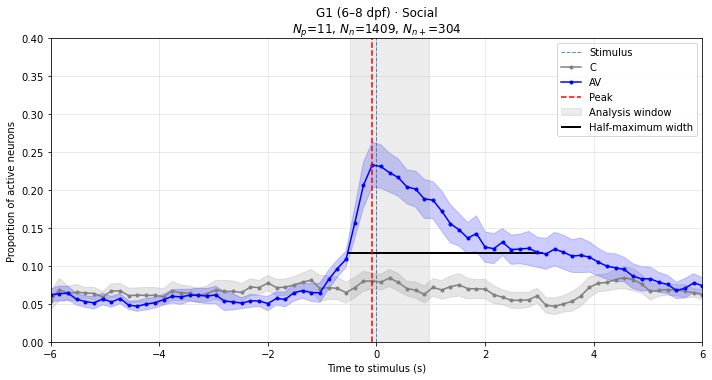

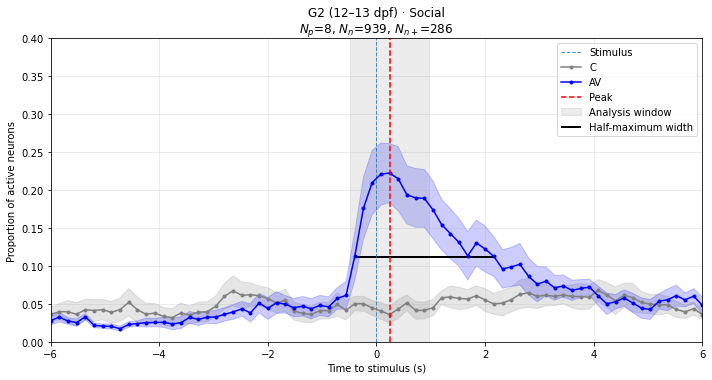

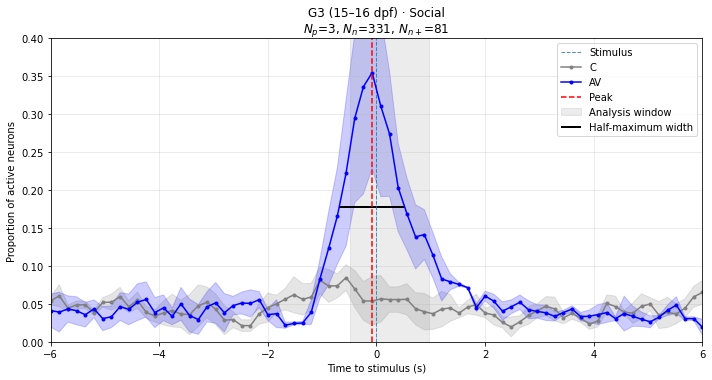

In [73]:
# ================================================================
# Plots with AV metrics (peak + FWHM)
# ================================================================
for gname in grupos.keys():
    data = resultados[gname]
    mean_C, sem_C   = _mean_sem_over_animals(data['C']["animals"])
    mean_AV, sem_AV = _mean_sem_over_animals(data['AV']["animals"])

    if mean_AV is not None:
        t_plot = data['AV']["t"][:len(mean_AV)] - stim_s
    elif mean_C is not None:
        t_plot = data['C']["t"][:len(mean_C)] - stim_s
    else:
        print(f"[{gname}] No data.")
        continue

    # --- counters
    Np      = data["Np"]
    Nn      = data["Nn"]
    Nn_plus = data["Nn_plus"]

    fig = plt.figure(figsize=(10,5))
    plt.axvline(0, linestyle='--', linewidth=1, alpha=0.8, label="Stimulus")

    # shaded analysis window
    plt.axvspan(-frames_pre/float(fps), frames_post/float(fps), 
                color="gray", alpha=0.15, label="Analysis window")

    # --- Individual AV trials (light blue)
    if "trials" in data["AV"]:
        for trial_curve in data["AV"]["trials"]:
            m = min(len(t_plot), len(trial_curve))
            plt.plot(t_plot[:m], trial_curve[:m],
                     color="skyblue", alpha=0.5, linewidth=1)

    # Curve C (mean ± SEM)
    if mean_C is not None:
        plt.plot(t_plot, mean_C[:len(t_plot)], 
                 label=f"C", 
                 color='gray', marker='.')
        m = min(len(t_plot), len(sem_C)) if sem_C is not None else 0
        if m>0:
            plt.fill_between(t_plot[:m], mean_C[:m]-sem_C[:m], mean_C[:m]+sem_C[:m],
                             alpha=0.2, color='gray')

    # Curve AV (mean ± SEM)
    if mean_AV is not None:
        color = 'blue' if solo_social else 'red'
        plt.plot(t_plot, mean_AV[:len(t_plot)], 
                 label=f"AV", 
                 color=color, marker='.')
        m = min(len(t_plot), len(sem_AV)) if sem_AV is not None else 0
        if m>0:
            plt.fill_between(t_plot[:m], mean_AV[:m]-sem_AV[:m], mean_AV[:m]+sem_AV[:m],
                             alpha=0.2, color=color)

        # --- AV metrics ---
        met = calcular_metrica_curva(t_rel, mean_AV, stim_window=(-1*frames_pre, frames_post))
        if met:
            # dashed line at the peak
            plt.axvline(met["delay"], linestyle="--", color="red", linewidth=1.5, label=f"Peak",)
            # plt.plot(met["delay"], met["peak_val"], "ro")

            # horizontal bar at FWHM
            if not np.isnan(met["fwhm_left"]) and not np.isnan(met["fwhm_right"]):
                plt.hlines(met["peak_val"]/2, met["fwhm_left"], met["fwhm_right"],
                           colors="black", linewidth=2, label=f"Half-maximum width",)

    plt.xlabel("Time to stimulus (s)")
    plt.ylabel("Proportion of active neurons")
    plt.ylim(0,.4)
    plt.xlim(-6, 6)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    fig.patch.set_facecolor('white')

    # --- title with counters
    plt.title(f"{gname} · {'Social' if solo_social else 'Isolated'}\n"
              f"$N_p$={Np}, $N_n$={Nn}, $N_{{n+}}$={Nn_plus}")
    # plt.savefig( f'{gname}_Social_{solo_sociales}_++_C2.pdf', dpi=300, bbox_inches='tight')
    
    plt.show()


## Evaluamos números de neuronas consistentes por grupo

In [43]:
# ================================================================
# Cálculo de consistencia inter-trials y preparación del DataFrame
# ================================================================
cons_max = 5  # vamos a evaluar consistencia >=1, >=2, ..., >=5

rows = []
for fish_id, area in areas.items():
    edad    = int(getattr(area, "edad", -999))
    aislado = int(getattr(area, "aislado", 1))

    # Asignar grupo etario
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue

    # --- Acumular trials de AV ---
    active_counts = None
    for tr in getattr(area, "trials_rea", []):
        cond = _get_condition(tr)
        if cond != "AV":
            continue

        try:
            t, tr_fps = _trial_timebase(tr, fps)
        except Exception:
            continue

        stim_frame = int(round(stim_s * tr_fps))
        win_idx = np.arange(stim_frame-frames_pre, stim_frame+frames_post+1)
        if win_idx.min()<0 or win_idx.max()>=len(t):
            continue

        rb = getattr(tr, 'roi_binaries_rea2', None)
        if rb is None or region_key not in rb:
            continue
        B = np.asarray(rb[region_key])
        if B.ndim != 2:
            continue
        B = (B > 0).astype(float)

        active_mask = (B[:, win_idx].sum(axis=1) > consistencia_en_trial)
        if active_counts is None:
            active_counts = active_mask.astype(int)
        else:
            active_counts += active_mask.astype(int)

    if active_counts is None:
        continue

    # --- Guardar conteos por nivel de consistencia ---
    for k in range(1, cons_max+1):
        n_neuronas = (active_counts >= k).sum()
        rows.append({
            "fish_id": str(fish_id),
            "grupo": gname,
            "aislado": aislado,
            "consistencia": k,
            "n_neuronas": n_neuronas
        })

df_cons = pd.DataFrame(rows)



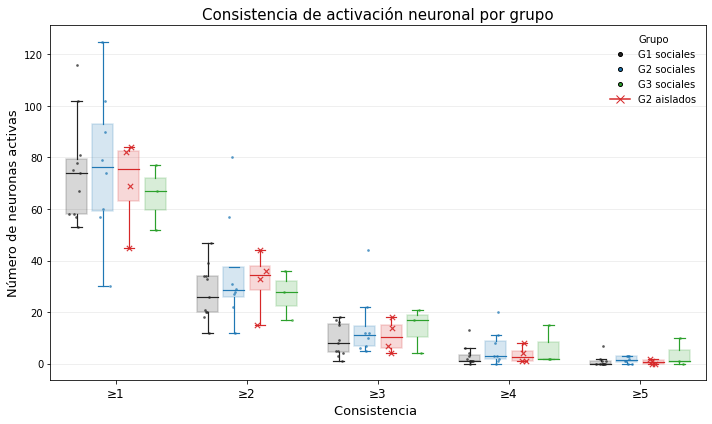

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ----- Mapear grupos a 4 categorías (separa G2 aislados) -----
def _group_label(grupo, aislado):
    if grupo == "G2 (12–13 dpf)" and aislado == 1:
        return "G2 aislados"
    return grupo

df_cons = df_cons.copy()
df_cons["grupo_plot"] = [
    _group_label(g, a) for g, a in zip(df_cons["grupo"], df_cons["aislado"])
]

# ----- Orden fijo -----
order_cons   = sorted(df_cons["consistencia"].unique())      # eje X (≥k)
order_grupos = ["G1 (6–8 dpf)", "G2 (12–13 dpf)", "G3 (15–16 dpf)", "G2 aislados"]

# ----- Colores y marcadores -----
colors = {
    "G1 (6–8 dpf)":     "#222222",   # negro/gris oscuro
    "G2 (12–13 dpf)":   "#1f77b4",   # azul
    "G3 (15–16 dpf)":   "#2ca02c",   # verde
    "G2 aislados":      "#d62728",   # rojo
}
markers = {
    "G1 (6–8 dpf)":   ".",
    "G2 (12–13 dpf)": ".",
    "G3 (15–16 dpf)": ".",
    "G2 aislados":    "x",   # <- pedido
}

# offsets laterales para ubicar 4 cajas por consistencia
offsets = {
    "G1 (6–8 dpf)":   -0.30,
    "G2 (12–13 dpf)": -0.10,
    "G3 (15–16 dpf)":  0.30,
    "G2 aislados":     0.10,
}

fig, ax = plt.subplots(figsize=(10,6))
box_width = 0.16
pt_jitter = 0.018  # jitter lateral para los puntos

for k in order_cons:
    base_x = float(k)
    for g in order_grupos:
        sub = df_cons[(df_cons["consistencia"]==k) & (df_cons["grupo_plot"]==g)]
        if sub.empty:
            continue

        pos = base_x + offsets[g]
        y   = sub["n_neuronas"].values

        # ---- Boxplot (con color del grupo y transparencia) ----
        bp = ax.boxplot(
            [y], positions=[pos], widths=box_width,
            showfliers=False, patch_artist=True
        )
        for patch in bp["boxes"]:
            patch.set_facecolor(colors[g])
            patch.set_alpha(0.18)            # relleno suave
            patch.set_edgecolor(colors[g])
            patch.set_linewidth(1.5)
        for line in bp["medians"] + bp["whiskers"] + bp["caps"]:
            line.set_color(colors[g])
            line.set_linewidth(1.2)

        # ---- Puntos de cada pez (con jitter) ----
        xs = np.random.normal(loc=pos, scale=pt_jitter, size=len(y))
        ax.scatter(xs, y, s=28,
                   c=colors[g],
                   marker=markers[g],
                   linewidths=1.2 if markers[g]=="x" else 0.0,  # que la x se vea bien
                   alpha=0.9 if g=="G2 aislados" else 0.75,
                   zorder=3)

# ----- Ejes y leyenda -----
ax.set_xlabel("Consistencia ", fontsize=13)
ax.set_ylabel("Número de neuronas activas", fontsize=13)
ax.set_title("Consistencia de activación neuronal por grupo", fontsize=15)
# --- Asegurar que 'consistencia' sea numérica ---
df_cons["consistencia"] = pd.to_numeric(df_cons["consistencia"], errors="coerce")

# --- Ticks en los k enteros (centros de cada grupo de 4 cajas) ---
order_cons = sorted(df_cons["consistencia"].dropna().unique().astype(int))  # p.ej. [1,2,3,4,5]
xticks = np.array(order_cons, dtype=float)

ax.set_xticks(xticks)
ax.set_xticklabels([f"≥{k}" for k in order_cons], fontsize=12)

# límites para que quepan offsets ±0.30 y el jitter
ax.set_xlim(xticks.min() - 0.5, xticks.max() + 0.5)
ax.grid(axis="y", alpha=0.25)

# Leyenda manual con 4 entradas (colores + marker especial para G2 aislados)
handles = [
    Line2D([0],[0], marker='.', color='none', markerfacecolor=colors["G1 (6–8 dpf)"], markersize=8, label="G1 sociales"),
    Line2D([0],[0], marker='.', color='none', markerfacecolor=colors["G2 (12–13 dpf)"], markersize=8, label="G2 sociales"),
    Line2D([0],[0], marker='.', color='none', markerfacecolor=colors["G3 (15–16 dpf)"], markersize=8, label="G3 sociales"),
    Line2D([0],[0], marker='x', color=colors["G2 aislados"], markersize=8, label="G2 aislados"),
]
ax.legend(handles=handles, title="Grupo", frameon=False, loc="upper right")

plt.tight_layout()
# plt.savefig('Consistencia_por_grupo_y_condicion.pdf', dpi=300, bbox_inches='tight')
plt.show()


## Lateralidad 

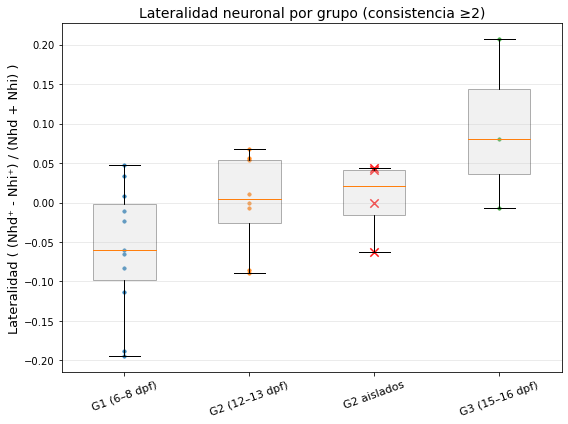

In [540]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D

# ----------------------------
# Parámetros
# ----------------------------
consistencia_min = 2  # >=2 trials activos
region_key = "Hb"

# ----------------------------
# Calcular lateralidad por pez
# ----------------------------
rows = []

for fish_id, area in areas.items():
    edad = int(getattr(area, "edad", -999))
    aislado = int(getattr(area, "aislado", 1))

    # Asignar grupo etario
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue

    grupo_plot = gname if not (gname=="G2 (12–13 dpf)" and aislado==1) else "G2 aislados"

    # Máscara hemisferio (True = izquierda, False = derecha)
    left_mask = np.array(area.roi_lefties[region_key], dtype=bool)

    # Neuronas totales por lado
    Nnhi = left_mask.sum()
    Nnhd = (~left_mask).sum()

    # --- consistencia: cuántos trials se prendió cada ROI ---
    consistencias = np.zeros(left_mask.shape[0], dtype=int)

    for tr in getattr(area, "trials_rea", []):
        cond = _get_condition(tr)
        if cond != "AV":  # solo trials AV
            continue
        try:
            t, tr_fps = _trial_timebase(tr, fps)
        except Exception:
            continue

        stim_frame = int(round(stim_s * tr_fps))
        win_idx = np.arange(stim_frame-frames_pre, stim_frame+frames_post+1)
        rb = getattr(tr, "roi_binaries_rea2", None)
        if rb is None or region_key not in rb:
            continue
        B = (np.asarray(rb[region_key]) > 0).astype(int)

        active = (B[:, win_idx].sum(axis=1) > 0).astype(int)
        consistencias += active

    # Neuronas activas con consistencia >= consistencia_min
    active_mask = consistencias >= consistencia_min

    Nnhi_plus = (active_mask & left_mask).sum()
    Nnhd_plus = (active_mask & ~left_mask).sum()

    # Calcular lateralidad
    denom = (Nnhi + Nnhd)
    if denom > 0:
        L = (Nnhd_plus - Nnhi_plus) / denom
        # L = (Nnhd_plus/Nnhd - Nnhi_plus/Nnhi) 
        rows.append({"fish_id": fish_id, "grupo_plot": grupo_plot, "lateralidad": L})

df_lat = pd.DataFrame(rows)

# ----------------------------
# Gráfico
# ----------------------------
order_grupos = ["G1 (6–8 dpf)", "G2 (12–13 dpf)", "G2 aislados", "G3 (15–16 dpf)"]
colors = {
    "G1 (6–8 dpf)": "C0",
    "G2 (12–13 dpf)": "C1",
    "G2 aislados": "red",
    "G3 (15–16 dpf)": "C2"
}
markers = {
    "G1 (6–8 dpf)": ".",
    "G2 (12–13 dpf)": ".",
    "G2 aislados": "x",
    "G3 (15–16 dpf)": "."
}

fig, ax = plt.subplots(figsize=(8,6))

# Boxplots grises
data_box = [df_lat.loc[df_lat["grupo_plot"]==g,"lateralidad"] for g in order_grupos]
bp = ax.boxplot(data_box, positions=np.arange(len(order_grupos)), widths=0.5,
                patch_artist=True, showfliers=False)
for patch in bp["boxes"]:
    patch.set_facecolor("lightgray")
    patch.set_alpha(0.3)

# Puntos por pez
for i,g in enumerate(order_grupos):
    sub = df_lat[df_lat["grupo_plot"]==g]
    ax.scatter(np.full(len(sub), i),
               sub["lateralidad"],
               color=colors[g],
               marker=markers[g],
               s=70 if g=="G2 aislados" else 50,
               linewidths=1.5 if g=="G2 aislados" else 0.5,
               alpha=0.9)

ax.set_xticks(np.arange(len(order_grupos)))
ax.set_xticklabels(order_grupos, rotation=20, fontsize=11)
ax.set_ylabel("Lateralidad ( (Nhd⁺ - Nhi⁺) / (Nhd + Nhi) )", fontsize=13)
ax.set_title(f"Lateralidad neuronal por grupo (consistencia ≥{consistencia_min})", fontsize=14)
# ax.axhline(0, color="black", linestyle="--", alpha=0.6)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
# plt.savefig('Lateralidad_por_grupo_y_condicion.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [346]:
from scipy.stats import kruskal, mannwhitneyu
import itertools
import statsmodels.stats.multitest as smm

# Test global Kruskal–Wallis
groups_data = [df_lat.loc[df_lat["grupo_plot"]==g, "lateralidad"].values
               for g in order_grupos]
H, p_global = kruskal(*groups_data)
print(f"Test global Kruskal–Wallis: H={H:.3f}, p={p_global:.4g}")

# Comparaciones por pares
pairs = list(itertools.combinations(order_grupos, 2))
pvals = []
results = []

for g1, g2 in pairs:
    x = df_lat.loc[df_lat["grupo_plot"]==g1, "lateralidad"].values
    y = df_lat.loc[df_lat["grupo_plot"]==g2, "lateralidad"].values
    if len(x)>0 and len(y)>0:
        U, p = mannwhitneyu(x, y, alternative="two-sided")
        pvals.append(p)
        results.append((g1, g2, U, p))

# Corrección por múltiples comparaciones
reject, pvals_corr, _, _ = smm.multipletests(pvals, method="fdr_bh")

print("\nComparaciones por pares (Mann–Whitney, FDR corregido):")
for (g1, g2, U, p_raw), p_corr, rj in zip(results, pvals_corr, reject):
    sig = "*" if rj else "ns"
    print(f"{g1} vs {g2}: U={U:.1f}, p_raw={p_raw:.4g}, p_corr={p_corr:.4g} → {sig}")


Test global Kruskal–Wallis: H=6.654, p=0.08379

Comparaciones por pares (Mann–Whitney, FDR corregido):
G1 (6–8 dpf) vs G2 (12–13 dpf): U=24.0, p_raw=0.1087, p_corr=0.326 → ns
G1 (6–8 dpf) vs G2 aislados: U=11.0, p_raw=0.1773, p_corr=0.3546 → ns
G1 (6–8 dpf) vs G3 (15–16 dpf): U=3.0, p_raw=0.03846, p_corr=0.2308 → ns
G2 (12–13 dpf) vs G2 aislados: U=16.5, p_raw=1, p_corr=1 → ns
G2 (12–13 dpf) vs G3 (15–16 dpf): U=6.0, p_raw=0.2788, p_corr=0.4182 → ns
G2 aislados vs G3 (15–16 dpf): U=3.0, p_raw=0.4, p_corr=0.48 → ns


# Focalidad

In [626]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------
# Funciones auxiliares
# ------------------------------------------------------
def pairwise_dist(coords):
    """Matriz de distancias euclídeas por pares."""
    from scipy.spatial.distance import pdist
    return pdist(coords)

def focalidad_percentil(area, consistencia_repeticion=2, n_perm=1000):
    """
    Calcula focalidad_nula para un pez:
    - Filtra neuronas que responden (≥ consistencia_repeticion trials).
    - Distancia media real entre esas neuronas.
    - Modelo nulo: mismas Nh+ al azar, 1000 permutaciones.
    - Devuelve percentil de la focalidad real en la nula.
    """
    # ------------------------------
    # 1. Identificar neuronas respondedoras
    # ------------------------------
    Nh = None
    Nh_plus_mask = None
    
    for tr in getattr(area, 'trials_rea', []):
        cond = _get_condition(tr)
        if cond != "AV":
            continue
        rb = getattr(tr, 'roi_binaries_rea2', None)
        if rb is None or region_key not in rb:
            continue
        B = np.asarray(rb[region_key])
        B = (B > 0).astype(int)
        Nh = B.shape[0]
        # consistencia a lo largo de trials
        resp = B[:, frames_pre:frames_pre+frames_post+1].sum(axis=1) > 0
        if Nh_plus_mask is None:
            Nh_plus_mask = resp.astype(int)
        else:
            Nh_plus_mask += resp.astype(int)
    
    if Nh is None or Nh_plus_mask is None:
        return None
    
    # Neuronas que cumplen consistencia_repeticion
    active_mask = Nh_plus_mask >= consistencia_repeticion
    idx_active = np.where(active_mask)[0]
    Nh_plus = len(idx_active)
    if Nh_plus < 2:
        return None  # no se puede calcular
    
    # ------------------------------
    # 2. Distancia media real
    # ------------------------------
    coords = np.array(area.contours[region_key])  # coords de todas las neuronas
    coords_active = coords[idx_active]
    d_real = pairwise_dist(coords_active).mean()
    
    # ------------------------------
    # 3. Modelo nulo (permutaciones)
    # ------------------------------
    d_null = []
    for _ in range(n_perm):
        idx_rand = np.random.choice(Nh, Nh_plus, replace=False)
        d_null.append(pairwise_dist(coords[idx_rand]).mean())
    d_null = np.array(d_null)
    
    # ------------------------------
    # 4. Percentil del valor real
    # ------------------------------
    perc = (d_null < d_real).mean() * 100.0
    return perc


In [627]:
def focalidad_percentil(area, consistencia_repeticion=2, n_perm=1000,
                        stim_s=23.6, frames_pre=6, frames_post=6, fps=6.25):
    Nh = None
    Nh_plus_mask = None
    
    for tr in getattr(area, 'trials_rea', []):
        cond = _get_condition(tr)
        if cond != "AV":
            continue
        rb = getattr(tr, 'roi_binaries_rea2', None)
        if rb is None or region_key not in rb:
            continue
        B = np.asarray(rb[region_key])
        B = (B > 0).astype(int)
        Nh = B.shape[0]

        # Determinar ventana alrededor del estímulo
        t, tr_fps = _trial_timebase(tr, fps)
        stim_frame = int(round(stim_s * tr_fps))
        win_idx = np.arange(stim_frame-frames_pre, stim_frame+frames_post+1)
        win_idx = win_idx[(win_idx >= 0) & (win_idx < B.shape[1])]

        resp = B[:, win_idx].sum(axis=1) > 0
        if Nh_plus_mask is None:
            Nh_plus_mask = resp.astype(int)
        else:
            Nh_plus_mask += resp.astype(int)
    
    if Nh is None or Nh_plus_mask is None:
        return None
    
    active_mask = Nh_plus_mask >= consistencia_repeticion
    idx_active = np.where(active_mask)[0]
    Nh_plus = len(idx_active)
    if Nh_plus < 2:
        return None
    
    # --- coordenadas como centroides
    coords = np.array(area.contours[region_key], dtype=object)
    centroids = []
    for c in coords:
        c = np.asarray(c)
        if c.ndim == 2 and c.shape[1] == 2:
            centroids.append(c.mean(axis=0))
        elif c.ndim == 1 and len(c) == 2:
            centroids.append(c)
    centroids = np.vstack(centroids)
    
    coords_active = centroids[idx_active]
    d_real = pairwise_dist(coords_active).mean()
    
    # --- modelo nulo
    d_null = []
    for _ in range(n_perm):
        idx_rand = np.random.choice(Nh, Nh_plus, replace=False)
        d_null.append(pairwise_dist(centroids[idx_rand]).mean())
    d_null = np.array(d_null)
    
    perc = (d_null < d_real).mean() * 100.0
    return perc


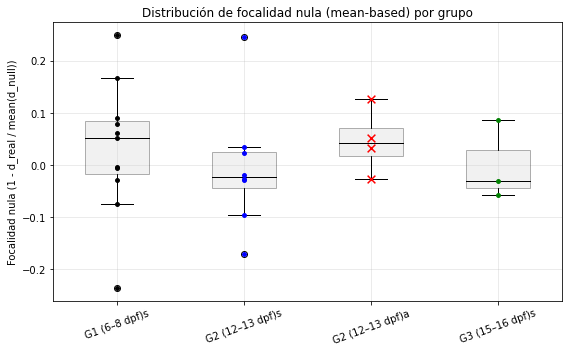

In [628]:
def focalidad_nula_mean(area, consistencia_repeticion=2, n_perm=1000,
                        stim_s=23.6, frames_pre=6, frames_post=6, fps=6.25):
    Nh = None
    Nh_plus_mask = None
    
    for tr in getattr(area, 'trials_rea', []):
        cond = _get_condition(tr)
        if cond != "AV":
            continue
        rb = getattr(tr, 'roi_binaries_rea2', None)
        if rb is None or region_key not in rb:
            continue
        B = np.asarray(rb[region_key])
        B = (B > 0).astype(int)
        Nh = B.shape[0]

        # Determinar ventana alrededor del estímulo
        t, tr_fps = _trial_timebase(tr, fps)
        stim_frame = int(round(stim_s * tr_fps))
        win_idx = np.arange(stim_frame-frames_pre, stim_frame+frames_post+1)
        win_idx = win_idx[(win_idx >= 0) & (win_idx < B.shape[1])]

        resp = B[:, win_idx].sum(axis=1) > 0
        if Nh_plus_mask is None:
            Nh_plus_mask = resp.astype(int)
        else:
            Nh_plus_mask += resp.astype(int)
    
    if Nh is None or Nh_plus_mask is None:
        return None
    
    active_mask = Nh_plus_mask >= consistencia_repeticion
    idx_active = np.where(active_mask)[0]
    Nh_plus = len(idx_active)
    if Nh_plus < 2:
        return None
    
    # --- coordenadas como centroides
    coords = np.array(area.contours[region_key], dtype=object)
    centroids = []
    for c in coords:
        c = np.asarray(c)
        if c.ndim == 2 and c.shape[1] == 2:
            centroids.append(c.mean(axis=0))
        elif c.ndim == 1 and len(c) == 2:
            centroids.append(c)
    centroids = np.vstack(centroids)
    
    coords_active = centroids[idx_active]
    d_real = pairwise_dist(coords_active).mean()
    
    # --- modelo nulo
    d_null = []
    for _ in range(n_perm):
        idx_rand = np.random.choice(Nh, Nh_plus, replace=False)
        d_null.append(pairwise_dist(centroids[idx_rand]).mean())
    d_null = np.array(d_null)
    
    # --- focalidad_nula_mean
    d_null_mean = d_null.mean()
    focal_mean = 1 - (d_real / d_null_mean)
    return focal_mean

rows = []
for k, area in areas.items():
    edad = getattr(area, 'edad', -999)
    aislado = getattr(area, 'aislado', 1)
    
    # Asignar grupo
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue
    
    grupo_plot = gname + ("a" if aislado==1 and gname=="G2 (12–13 dpf)" else "s")
    
    foc_mean = focalidad_nula_mean(area, consistencia_repeticion=2, n_perm=1000,  frames_pre=frames_pre, frames_post=frames_post)
    if foc_mean is None:
        continue
    
    rows.append({
        "fish_id": k,
        "grupo_plot": grupo_plot,
        "focalidad_nula_mean": foc_mean
    })

df_foc_mean = pd.DataFrame(rows)

# ------------------------------------------------------
# Gráfico
# ------------------------------------------------------
order_grupos = ["G1 (6–8 dpf)s", "G2 (12–13 dpf)s", "G2 (12–13 dpf)a", "G3 (15–16 dpf)s"]
colors = {"G1 (6–8 dpf)s":"black",
          "G2 (12–13 dpf)s":"blue",
          "G2 (12–13 dpf)a":"red",
          "G3 (15–16 dpf)s":"green"}
markers = {"G1 (6–8 dpf)s":".",
           "G2 (12–13 dpf)s":".",
           "G2 (12–13 dpf)a":"x",
           "G3 (15–16 dpf)s":"."}

fig, ax = plt.subplots(figsize=(8,5))
for i,g in enumerate(order_grupos):
    y = df_foc_mean.loc[df_foc_mean["grupo_plot"]==g, "focalidad_nula_mean"]
    if len(y)==0:
        continue
    ax.boxplot(y, positions=[i], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor="lightgray", alpha=0.3),
               medianprops=dict(color="black"))
    ax.scatter(np.full_like(y, i, dtype=float), y, 
               color=colors[g], marker=markers[g], s=60, zorder=3)

ax.set_xticks(range(len(order_grupos)))
ax.set_xticklabels(order_grupos, rotation=20)
ax.set_ylabel("Focalidad nula (1 - d_real / mean(d_null))")
ax.set_title("Distribución de focalidad nula (mean-based) por grupo")
ax.grid(alpha=0.3)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()


In [629]:
def focalidad_nula_mean_lateral(area, lado="derecha", consistencia_repeticion=2, n_perm=1000,
                                stim_s=23.6, frames_pre=6, frames_post=6, fps=6.25):
    """
    Calcula focalidad_nula_mean solo para neuronas de un lado (derecha/izquierda).
    """
    Nh = None
    Nh_plus_mask = None
    
    for tr in getattr(area, 'trials_rea', []):
        cond = _get_condition(tr)
        if cond != "AV":
            continue
        rb = getattr(tr, 'roi_binaries_rea2', None)
        if rb is None or region_key not in rb:
            continue
        B = np.asarray(rb[region_key])
        B = (B > 0).astype(int)
        Nh = B.shape[0]

        # Ventana de estímulo
        t, tr_fps = _trial_timebase(tr, fps)
        stim_frame = int(round(stim_s * tr_fps))
        win_idx = np.arange(stim_frame-frames_pre, stim_frame+frames_post+1)
        win_idx = win_idx[(win_idx >= 0) & (win_idx < B.shape[1])]

        resp = B[:, win_idx].sum(axis=1) > 0
        if Nh_plus_mask is None:
            Nh_plus_mask = resp.astype(int)
        else:
            Nh_plus_mask += resp.astype(int)
    
    if Nh is None or Nh_plus_mask is None:
        return None
    
    # --- centroides
    coords = np.array(area.contours[region_key], dtype=object)
    centroids = []
    for c in coords:
        c = np.asarray(c)
        if c.ndim == 2 and c.shape[1] == 2:
            centroids.append(c.mean(axis=0))
        elif c.ndim == 1 and len(c) == 2:
            centroids.append(c)
    centroids = np.vstack(centroids)

    # Definir lado por X
    x_coords = centroids[:,0]
    midline = np.median(x_coords)
    if lado == "derecha":
        mask_lado = x_coords > midline
    else:
        mask_lado = x_coords <= midline

    # Filtrar neuronas por lado y consistencia
    active_mask = (Nh_plus_mask >= consistencia_repeticion) & mask_lado
    idx_active = np.where(active_mask)[0]
    Nh_plus = len(idx_active)
    if Nh_plus < 2:
        return None
    
    coords_active = centroids[idx_active]
    d_real = pairwise_dist(coords_active).mean()
    
    # Modelo nulo: solo del mismo lado
    coords_lado = centroids[mask_lado]
    Nh_lado = coords_lado.shape[0]
    if Nh_lado < Nh_plus:
        return None  # no hay suficientes neuronas
    
    d_null = []
    for _ in range(n_perm):
        idx_rand = np.random.choice(Nh_lado, Nh_plus, replace=False)
        d_null.append(pairwise_dist(coords_lado[idx_rand]).mean())
    d_null = np.array(d_null)
    
    focal_mean = 1 - (d_real / d_null.mean())
    return focal_mean


In [630]:
def focalidad_nula_mean_lateral(area, lado="derecha", consistencia_repeticion=2, 
                                n_perm=1000, stim_s=23.6, frames_pre=6, frames_post=6, fps=6.25):
    """
    Calcula focalidad_nula_mean para un lado de la habenula ('derecha' o 'izquierda'),
    usando area.roi_lefties['Hb'] como referencia de lateralidad.
    """
    Nh = None
    Nh_plus_mask = None

    # ------------------------------
    # 1. Consistencia de neuronas respondedoras en AV
    # ------------------------------
    for tr in getattr(area, 'trials_rea', []):
        if _get_condition(tr) != "AV":
            continue
        rb = getattr(tr, 'roi_binaries_rea2', None)
        if rb is None or region_key not in rb:
            continue

        B = np.asarray(rb[region_key])
        B = (B > 0).astype(int)
        Nh = B.shape[0]

        # Ventana de estímulo
        t, tr_fps = _trial_timebase(tr, fps)
        stim_frame = int(round(stim_s * tr_fps))
        win_idx = np.arange(stim_frame - frames_pre, stim_frame + frames_post + 1)
        win_idx = win_idx[(win_idx >= 0) & (win_idx < B.shape[1])]

        # Neuronas que se activan en la ventana
        resp = B[:, win_idx].sum(axis=1) > 0
        if Nh_plus_mask is None:
            Nh_plus_mask = resp.astype(int)
        else:
            Nh_plus_mask += resp.astype(int)

    if Nh is None or Nh_plus_mask is None:
        return None

    # ------------------------------
    # 2. Lado de cada neurona (ya dado por roi_lefties)
    # ------------------------------
    roi_lefties = np.array(area.roi_lefties[region_key], dtype=bool)
    if lado == "derecha":
        mask_lado = roi_lefties  # True = derecha
    else:
        mask_lado = ~roi_lefties # False = izquierda

    # ------------------------------
    # 3. Selección de neuronas activas de este lado
    # ------------------------------
    active_mask = (Nh_plus_mask >= consistencia_repeticion) & mask_lado
    idx_active = np.where(active_mask)[0]
    Nh_plus = len(idx_active)
    if Nh_plus < 2:
        return None

    coords = np.array(area.contours[region_key], dtype=object)
    centroids = []
    for c in coords:
        c = np.asarray(c)
        if c.ndim == 2 and c.shape[1] == 2:
            centroids.append(c.mean(axis=0))
        elif c.ndim == 1 and len(c) == 2:
            centroids.append(c)
    centroids = np.vstack(centroids)

    coords_active = centroids[idx_active]
    d_real = pairwise_dist(coords_active).mean()

    # ------------------------------
    # 4. Modelo nulo solo del mismo lado
    # ------------------------------
    idx_lado = np.where(mask_lado)[0]
    Nh_lado = len(idx_lado)
    if Nh_lado < Nh_plus:
        return None

    coords_lado = centroids[idx_lado]
    d_null = []
    for _ in range(n_perm):
        idx_rand = np.random.choice(Nh_lado, Nh_plus, replace=False)
        d_null.append(pairwise_dist(coords_lado[idx_rand]).mean())
    d_null = np.array(d_null)

    # ------------------------------
    # 5. Focalidad nula mean
    # ------------------------------
    focal_mean = 1 - (d_real / d_null.mean())
    return focal_mean


In [631]:
rows = []
for k, area in areas.items():
    edad = getattr(area, 'edad', -999)
    aislado = getattr(area, 'aislado', 1)
    
    # Asignar grupo
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue
    
    grupo_plot = gname + ("a" if aislado==1 and gname=="G2 (12–13 dpf)" else "s")
    
    foc_der = focalidad_nula_mean_lateral(area, lado="derecha", consistencia_repeticion=2,  frames_pre=frames_pre, frames_post=frames_post)
    foc_izq = focalidad_nula_mean_lateral(area, lado="izquierda", consistencia_repeticion=2,  frames_pre=frames_pre, frames_post=frames_post)
    
    if foc_der is not None:
        rows.append({"fish_id": k, "grupo_plot": grupo_plot, "lado":"derecha", "focalidad": foc_der})
    if foc_izq is not None:
        rows.append({"fish_id": k, "grupo_plot": grupo_plot, "lado":"izquierda", "focalidad": foc_izq})

df_foc_lat = pd.DataFrame(rows)


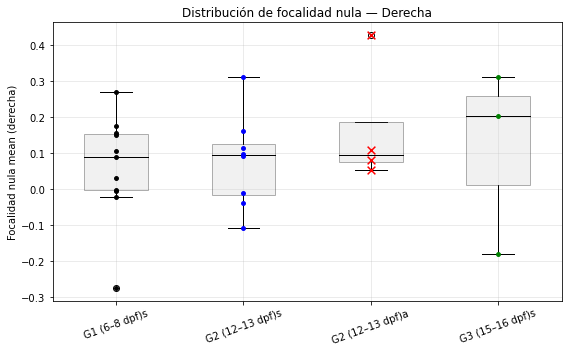

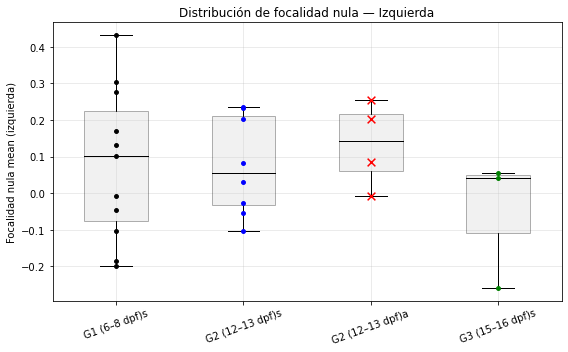

In [640]:
order_grupos = ["G1 (6–8 dpf)s", "G2 (12–13 dpf)s", "G2 (12–13 dpf)a", "G3 (15–16 dpf)s"]
colors = {"G1 (6–8 dpf)s":"black",
          "G2 (12–13 dpf)s":"blue",
          "G2 (12–13 dpf)a":"red",
          "G3 (15–16 dpf)s":"green"}
markers = {"G1 (6–8 dpf)s":".",
           "G2 (12–13 dpf)s":".",
           "G2 (12–13 dpf)a":"x",
           "G3 (15–16 dpf)s":"."}

for lado in ["derecha","izquierda"]:
    fig, ax = plt.subplots(figsize=(8,5))
    for i,g in enumerate(order_grupos):
        y = df_foc_lat.loc[(df_foc_lat["grupo_plot"]==g) & (df_foc_lat["lado"]==lado), "focalidad"]
        if len(y)==0:
            continue
        ax.boxplot(y, positions=[i], widths=0.5, patch_artist=True,
                   boxprops=dict(facecolor="lightgray", alpha=0.3),
                   medianprops=dict(color="black"))
        ax.scatter(np.full_like(y, i, dtype=float), y, 
                   color=colors[g], marker=markers[g], s=60, zorder=3)

    ax.set_xticks(range(len(order_grupos)))
    ax.set_xticklabels(order_grupos, rotation=20)
    ax.set_ylabel(f"Focalidad nula mean ({lado})")
    ax.set_title(f"Distribución de focalidad nula — {lado.capitalize()}")
    ax.grid(alpha=0.3)
    fig.patch.set_facecolor("white")
    plt.tight_layout()
    plt.show()


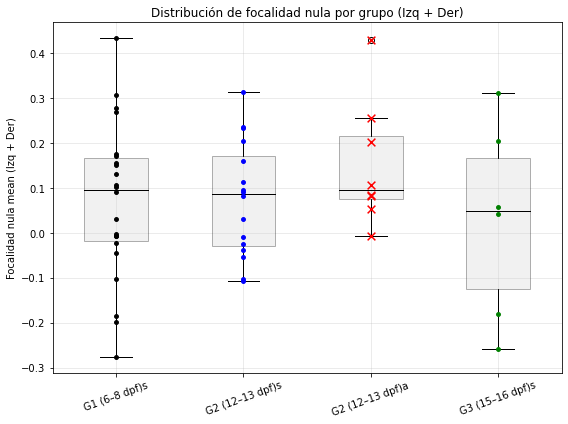

In [641]:
fig, ax = plt.subplots(figsize=(8,6))

for i, g in enumerate(order_grupos):
    # juntar datos de derecha + izquierda
    y = df_foc_lat.loc[df_foc_lat["grupo_plot"]==g, "focalidad"]
    if len(y) == 0:
        continue
    
    # boxplot de la distribución completa
    ax.boxplot(y, positions=[i], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor="lightgray", alpha=0.3),
               medianprops=dict(color="black"))
    
    # puntos individuales (derecha + izquierda)
    lados = df_foc_lat.loc[df_foc_lat["grupo_plot"]==g, "lado"].values
    ax.scatter(np.full_like(y, i, dtype=float), y,
               color=colors[g], marker=markers[g], s=60, zorder=3)

ax.set_xticks(range(len(order_grupos)))
ax.set_xticklabels(order_grupos, rotation=20)
ax.set_ylabel("Focalidad nula mean (Izq + Der)")
ax.set_title("Distribución de focalidad nula por grupo (Izq + Der)")
ax.grid(alpha=0.3)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()


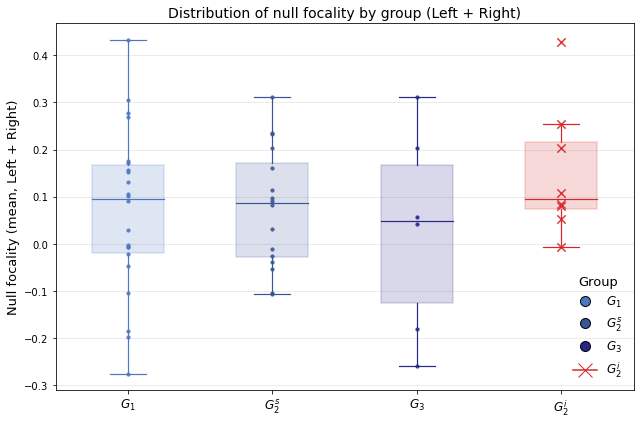

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# ----- Use the exact labels from df_foc_lat -----
order_grupos = ["G1 (6–8 dpf)s", "G2 (12–13 dpf)s", "G3 (15–16 dpf)s", "G2 (12–13 dpf)a"]
colors = {
    "G1 (6–8 dpf)s": "#4D76C4",
    "G2 (12–13 dpf)s": "#385696",
    "G2 (12–13 dpf)a": "#d62728",
    "G3 (15–16 dpf)s": "#27278B"
}
markers = {
    "G1 (6–8 dpf)s": ".",
    "G2 (12–13 dpf)s": ".",
    "G2 (12–13 dpf)a": "x",
    "G3 (15–16 dpf)s": "."
}

fig, ax = plt.subplots(figsize=(9,6))

# ---- Boxplots + points ----
for i, g in enumerate(order_grupos):
    # combine Left + Right
    y = df_foc_lat.loc[df_foc_lat["grupo_plot"]==g, "focalidad"]
    if len(y) == 0:
        continue
    
    # Boxplot colored by group
    bp = ax.boxplot([y], positions=[i], widths=0.5,
                    patch_artist=True, showfliers=False)
    for patch in bp["boxes"]:
        patch.set_facecolor(colors[g])
        patch.set_alpha(0.18)            # soft fill
        patch.set_edgecolor(colors[g])
        patch.set_linewidth(1.5)
    for line in bp["medians"] + bp["whiskers"] + bp["caps"]:
        line.set_color(colors[g])
        line.set_linewidth(1.2)

    # Points per fish
    ax.scatter(np.full(len(y), i),
               y,
               color=colors[g],
               marker=markers[g],
               s=70 if g=="G2 (12–13 dpf)a" else 50,
               linewidths=1.5 if g=="G2 (12–13 dpf)a" else 0.5,
               alpha=0.9, zorder=3)

# ---- Axes and labels ----
ax.set_xticks(np.arange(len(order_grupos)))
ax.set_xticklabels(["$G_1$", "$G_2^{s}$", "$G_3$", "$G_2^{i}$"], fontsize=12)
ax.set_ylabel("Null focality (mean, Left + Right)", fontsize=13)
ax.set_title("Distribution of null focality by group (Left + Right)", fontsize=14)
ax.grid(axis="y", alpha=0.3)

# ---- Manual legend ----
handles = [
    Line2D([0],[0], marker='.', color='none',
           markerfacecolor=colors["G1 (6–8 dpf)s"], markersize=20, label="$G_1$"),
    Line2D([0],[0], marker='.', color='none',
           markerfacecolor=colors["G2 (12–13 dpf)s"], markersize=20, label="$G_2^{s}$"),
    
    Line2D([0],[0], marker='.', color='none',
           markerfacecolor=colors["G3 (15–16 dpf)s"], markersize=20, label="$G_3$"),
           Line2D([0],[0], marker='x', color=colors["G2 (12–13 dpf)a"], markersize=14, label="$G_2^{i}$"),
]
ax.legend(handles=handles, title="Group", frameon=False,
          loc="lower right", fontsize=12, title_fontsize=13)

fig.patch.set_facecolor("white")

plt.tight_layout()
#plt.savefig('Focalidad_nula_por_grupo_y_condicion_F.pdf', dpi=300, bbox_inches='tight')
plt.show()


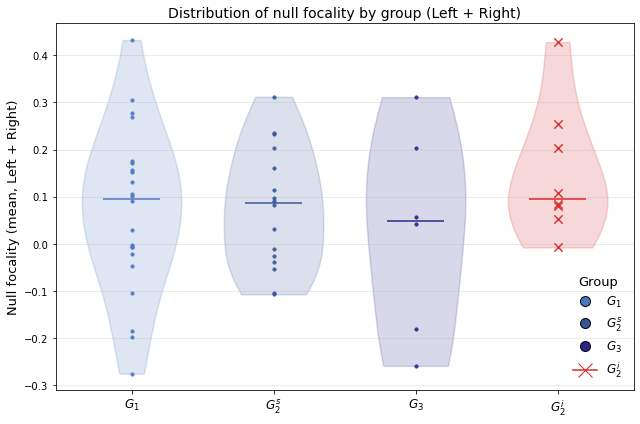

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import numpy as np

# ----- Use the exact labels from df_foc_lat -----
order_grupos = ["G1 (6–8 dpf)s", "G2 (12–13 dpf)s", "G3 (15–16 dpf)s", "G2 (12–13 dpf)a"]
colors = {
    "G1 (6–8 dpf)s": "#4D76C4",
    "G2 (12–13 dpf)s": "#385696",
    "G2 (12–13 dpf)a": "#d62728",
    "G3 (15–16 dpf)s": "#27278B"
}
markers = {
    "G1 (6–8 dpf)s": ".",
    "G2 (12–13 dpf)s": ".",
    "G2 (12–13 dpf)a": "x",
    "G3 (15–16 dpf)s": "."
}

fig, ax = plt.subplots(figsize=(9,6))

# ---- Violin plots ----
for i, g in enumerate(order_grupos):
    y = df_foc_lat.loc[df_foc_lat["grupo_plot"]==g, "focalidad"]
    if len(y) == 0:
        continue
    
    vp = ax.violinplot(
        [y], positions=[i], widths=0.7, showextrema=False, showmeans=False, showmedians=False
    )
    for pc in vp['bodies']:
        pc.set_facecolor(colors[g])
        pc.set_alpha(0.18)    # soft fill
        pc.set_edgecolor(colors[g])
        pc.set_linewidth(1.5)
    
    # Median line (optional: like boxplot median)
    ax.hlines(np.median(y), i-0.2, i+0.2, color=colors[g], linewidth=1.5)

    # Points per fish
    ax.scatter(np.full(len(y), i),
               y,
               color=colors[g],
               marker=markers[g],
               s=70 if g=="G2 (12–13 dpf)a" else 50,
               linewidths=1.5 if g=="G2 (12–13 dpf)a" else 0.5,
               alpha=0.9, zorder=3)

# ---- Axes and labels ----
ax.set_xticks(np.arange(len(order_grupos)))
ax.set_xticklabels(["$G_1$", "$G_2^{s}$", "$G_3$", "$G_2^{i}$"], fontsize=12)
ax.set_ylabel("Null focality (mean, Left + Right)", fontsize=13)
ax.set_title("Distribution of null focality by group (Left + Right)", fontsize=14)
ax.grid(axis="y", alpha=0.3)

# ---- Manual legend ----
handles = [
    Line2D([0],[0], marker='.', color='none',
           markerfacecolor=colors["G1 (6–8 dpf)s"], markersize=20, label="$G_1$"),
    Line2D([0],[0], marker='.', color='none',
           markerfacecolor=colors["G2 (12–13 dpf)s"], markersize=20, label="$G_2^{s}$"),
    Line2D([0],[0], marker='.', color='none',
           markerfacecolor=colors["G3 (15–16 dpf)s"], markersize=20, label="$G_3$"),
    Line2D([0],[0], marker='x', color=colors["G2 (12–13 dpf)a"], markersize=14, label="$G_2^{i}$"),
]
ax.legend(handles=handles, title="Group", frameon=False,
          loc="lower right", fontsize=12, title_fontsize=13)

fig.patch.set_facecolor("white")
plt.tight_layout()
#plt.savefig('Focalidad_nula_por_grupo_y_condicion_F_V.pdf', dpi=300, bbox_inches='tight')

plt.show()


In [645]:
from scipy.stats import ttest_1samp

results = []

for g in order_grupos:
    y = df_foc_lat.loc[df_foc_lat["grupo_plot"]==g, "focalidad"].dropna()
    if len(y) == 0:
        continue
    
    # One-sample t-test against mu=0
    t_stat, p_val = ttest_1samp(y, popmean=0)
    
    results.append({
        "group": g,
        "n": len(y),
        "mean": y.mean(),
        "t": t_stat,
        "p": p_val
    })

import pandas as pd
df_stats = pd.DataFrame(results)
print(df_stats)


             group   n      mean         t         p
0    G1 (6–8 dpf)s  22  0.070221  1.888571  0.072841
1  G2 (12–13 dpf)s  16  0.076125  2.372527  0.031468
2  G3 (15–16 dpf)s   6  0.028678  0.321634  0.760741
3  G2 (12–13 dpf)a   8  0.150237  3.045137  0.018711


In [653]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Filtrar solo grupos sociales
df_social = df_foc_lat[df_foc_lat["grupo_plot"].isin(
    ["G1 (6–8 dpf)s", "G2 (12–13 dpf)s", "G3 (15–16 dpf)s"]
)]

# ANOVA de un factor (grupo_plot = edad)
model = ols("focalidad ~ C(grupo_plot)", data=df_social).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)


                 sum_sq    df         F    PR(>F)
C(grupo_plot)  0.010368   2.0  0.189045  0.828466
Residual       1.124308  41.0       NaN       NaN


# Levantamos lo que realizamos y arrancamos con el analisis de nuevo:  

In [20]:
# areas_dir = r'C:\Users\PC\Documents\GitHub\social_isolation_habenula_imaging\Exp_25\PKL 06-2025'
areas_dir = r'C:\Users\PC\Documents\GitHub\social_isolation_habenula_imaging\Exp_25\PKL 06-2025 Rea2'
# areas_dir = r'C:\Users\PC\Desktop\Analisis conf\PKL 11-2024'
areas = load_areas(areas_dir)

for key in areas:
    print(key + ":", len(areas[key].trials), "trials.")

113-1: 10 trials.
114-1: 10 trials.
115-1: 10 trials.
116-1: 10 trials.
117-1: 10 trials.
118-1: 10 trials.
120-1: 10 trials.
121-1: 10 trials.
122-1: 10 trials.
123-1: 10 trials.
124-1: 10 trials.
125-1: 10 trials.
126-1: 10 trials.
127-1: 10 trials.
129-1: 10 trials.
130-1: 10 trials.
131-1: 10 trials.
132-1: 10 trials.
133-1: 10 trials.
134-1: 10 trials.
135-1: 10 trials.
136-1: 10 trials.
137-1: 10 trials.
138-1: 10 trials.
139-1: 10 trials.
143-1: 10 trials.


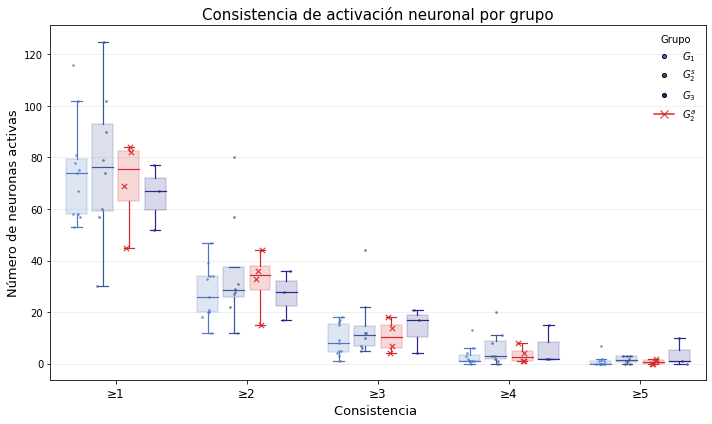

In [719]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ----- Mapear grupos a 4 categorías (separa G2 aislados) -----
def _group_label(grupo, aislado):
    if grupo == "G2 (12–13 dpf)" and aislado == 1:
        return "G2 aislados"
    return grupo

df_cons = df_cons.copy()
df_cons["grupo_plot"] = [
    _group_label(g, a) for g, a in zip(df_cons["grupo"], df_cons["aislado"])
]

# ----- Orden fijo -----
order_cons   = sorted(df_cons["consistencia"].unique())      # eje X (≥k)
order_grupos = ["G1 (6–8 dpf)", "G2 (12–13 dpf)", "G3 (15–16 dpf)", "G2 aislados"]

# ----- Colores y marcadores -----
colors = {
    "G1 (6–8 dpf)":     "#4D76C4",   # negro/gris oscuro
    "G2 (12–13 dpf)":   "#385696",   # azul
    "G3 (15–16 dpf)":   "#27278B",   # verde
    "G2 aislados":      "#d62728",   # rojo
}
markers = {
    "G1 (6–8 dpf)":   ".",
    "G2 (12–13 dpf)": ".",
    "G3 (15–16 dpf)": ".",
    "G2 aislados":    "x",   # <- pedido
}

# offsets laterales para ubicar 4 cajas por consistencia
offsets = {
    "G1 (6–8 dpf)":   -0.30,
    "G2 (12–13 dpf)": -0.10,
    "G3 (15–16 dpf)":  0.30,
    "G2 aislados":     0.10,
}

fig, ax = plt.subplots(figsize=(10,6))
box_width = 0.16
pt_jitter = 0.018  # jitter lateral para los puntos

for k in order_cons:
    base_x = float(k)
    for g in order_grupos:
        sub = df_cons[(df_cons["consistencia"]==k) & (df_cons["grupo_plot"]==g)]
        if sub.empty:
            continue

        pos = base_x + offsets[g]
        y   = sub["n_neuronas"].values

        # ---- Boxplot (con color del grupo y transparencia) ----
        bp = ax.boxplot(
            [y], positions=[pos], widths=box_width,
            showfliers=False, patch_artist=True
        )
        for patch in bp["boxes"]:
            patch.set_facecolor(colors[g])
            patch.set_alpha(0.18)            # relleno suave
            patch.set_edgecolor(colors[g])
            patch.set_linewidth(1.5)
        for line in bp["medians"] + bp["whiskers"] + bp["caps"]:
            line.set_color(colors[g])
            line.set_linewidth(1.2)

        # ---- Puntos de cada pez (con jitter) ----
        xs = np.random.normal(loc=pos, scale=pt_jitter, size=len(y))
        ax.scatter(xs, y, s=28,
                   c=colors[g],
                   marker=markers[g],
                   linewidths=1.2 if markers[g]=="x" else 0.0,  # que la x se vea bien
                   alpha=0.9 if g=="G2 aislados" else 0.75,
                   zorder=3)

# ----- Ejes y leyenda -----
ax.set_xlabel("Consistencia ", fontsize=13)
ax.set_ylabel("Número de neuronas activas", fontsize=13)
ax.set_title("Consistencia de activación neuronal por grupo", fontsize=15)
# --- Asegurar que 'consistencia' sea numérica ---
df_cons["consistencia"] = pd.to_numeric(df_cons["consistencia"], errors="coerce")

# --- Ticks en los k enteros (centros de cada grupo de 4 cajas) ---
order_cons = sorted(df_cons["consistencia"].dropna().unique().astype(int))  # p.ej. [1,2,3,4,5]
xticks = np.array(order_cons, dtype=float)

ax.set_xticks(xticks)
ax.set_xticklabels([f"≥{k}" for k in order_cons], fontsize=12)

# límites para que quepan offsets ±0.30 y el jitter
ax.set_xlim(xticks.min() - 0.5, xticks.max() + 0.5)
ax.grid(axis="y", alpha=0.25)

# Leyenda manual con 4 entradas (colores + marker especial para G2 aislados)
handles = [
    Line2D([0],[0], marker='.', color='none', markerfacecolor=colors["G1 (6–8 dpf)"], markersize=8, label="$G_1$"),
    Line2D([0],[0], marker='.', color='none', markerfacecolor=colors["G2 (12–13 dpf)"], markersize=8, label="$G_2^{s}$"),
    Line2D([0],[0], marker='.', color='none', markerfacecolor=colors["G3 (15–16 dpf)"], markersize=8, label="$G_3$"),
    Line2D([0],[0], marker='x', color=colors["G2 aislados"], markersize=8, label="$G_2^{a}$"),
]
ax.legend(handles=handles, title="Grupo", frameon=False, loc="upper right")

plt.tight_layout()
# plt.savefig('Consistencia_por_grupo_y_condicion.pdf', dpi=300, bbox_inches='tight')
plt.show()


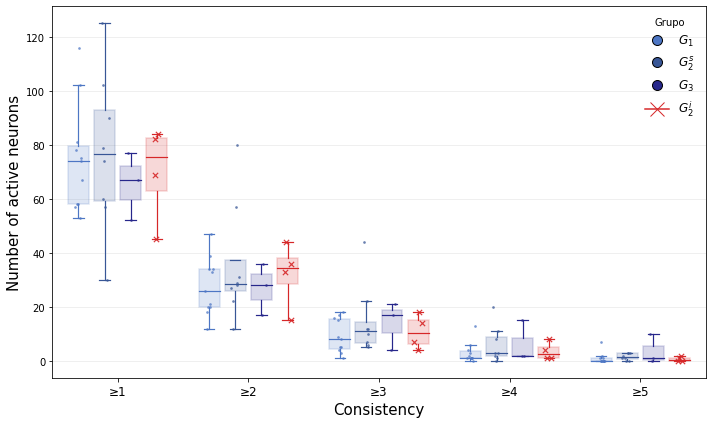

In [720]:

from matplotlib.lines import Line2D

# ----- Map groups to 4 categories (separate G2 isolated) -----
def _group_label(grupo, aislado):
    if grupo == "G2 (12–13 dpf)" and aislado == 1:
        return "G2 isolated"
    return grupo

df_cons = df_cons.copy()
df_cons["grupo_plot"] = [
    _group_label(g, a) for g, a in zip(df_cons["grupo"], df_cons["aislado"])
]

# ----- Fixed order -----
order_cons   = sorted(df_cons["consistencia"].unique())      # x axis (≥k)
order_grupos = ["G1 (6–8 dpf)", "G2 (12–13 dpf)", "G3 (15–16 dpf)", "G2 isolated"]

# ----- Colors and markers -----
colors = {
    "G1 (6–8 dpf)":     "#4D76C4",   # dark gray/blue
    "G2 (12–13 dpf)":   "#385696",   # blue
    "G3 (15–16 dpf)":   "#27278B",   # navy
    "G2 isolated":      "#d62728",   # red
}
markers = {
    "G1 (6–8 dpf)":   ".",
    "G2 (12–13 dpf)": ".",
    "G3 (15–16 dpf)": ".",
    "G2 isolated":    "x",   # <- requested
}

# lateral offsets to place 4 boxes per consistency level
offsets = {
    "G1 (6–8 dpf)":   -0.30,
    "G2 (12–13 dpf)": -0.10,
    "G3 (15–16 dpf)":  0.10,
    "G2 isolated":     0.30,
}

fig, ax = plt.subplots(figsize=(10,6))
box_width = 0.16
pt_jitter = 0.018  # lateral jitter for points

for k in order_cons:
    base_x = float(k)
    for g in order_grupos:
        sub = df_cons[(df_cons["consistencia"]==k) & (df_cons["grupo_plot"]==g)]
        if sub.empty:
            continue

        pos = base_x + offsets[g]
        y   = sub["n_neuronas"].values

        # ---- Boxplot (with group color and transparency) ----
        bp = ax.boxplot(
            [y], positions=[pos], widths=box_width,
            showfliers=False, patch_artist=True
        )
        for patch in bp["boxes"]:
            patch.set_facecolor(colors[g])
            patch.set_alpha(0.18)            # soft fill
            patch.set_edgecolor(colors[g])
            patch.set_linewidth(1.5)
        for line in bp["medians"] + bp["whiskers"] + bp["caps"]:
            line.set_color(colors[g])
            line.set_linewidth(1.2)

        # ---- Points for each fish (with jitter) ----
        xs = np.random.normal(loc=pos, scale=pt_jitter, size=len(y))
        ax.scatter(xs, y, s=28,
                   c=colors[g],
                   marker=markers[g],
                   linewidths=1.2 if markers[g]=="x" else 0.0,
                   alpha=0.9 if g=="G2 isolated" else 0.75,
                   zorder=3)

# ----- Axes and legend -----
ax.set_xlabel("Consistency", fontsize=15)
ax.set_ylabel("Number of active neurons", fontsize=15)
#ax.set_title("Neuronal activation consistency by group", fontsize=15)

# --- Ensure 'consistencia' is numeric ---
df_cons["consistencia"] = pd.to_numeric(df_cons["consistencia"], errors="coerce")

# --- X ticks at integer k values (centers of each group of 4 boxes) ---
order_cons = sorted(df_cons["consistencia"].dropna().unique().astype(int))
xticks = np.array(order_cons, dtype=float)

ax.set_xticks(xticks)
ax.set_xticklabels([f"≥{k}" for k in order_cons], fontsize=12)

# limits to fit offsets ±0.30 and jitter
ax.set_xlim(xticks.min() - 0.5, xticks.max() + 0.5)
ax.grid(axis="y", alpha=0.25)

# Leyenda manual con 4 entradas (colores + marker especial para G2 aislados)
handles = [
    Line2D([0],[0], marker='.', color='none', markerfacecolor=colors["G1 (6–8 dpf)"], markersize=20, label="$G_1$"),
    Line2D([0],[0], marker='.', color='none', markerfacecolor=colors["G2 (12–13 dpf)"], markersize=20, label="$G_2^{s}$"),
    Line2D([0],[0], marker='.', color='none', markerfacecolor=colors["G3 (15–16 dpf)"], markersize=20, label="$G_3$"),
    Line2D([0],[0], marker='x', color=colors["G2 isolated"], markersize=14, label="$G_2^{i}$"),
]
ax.legend(handles=handles, title="Grupo", frameon=False, loc="upper right", fontsize=12)

plt.tight_layout()
#plt.savefig('Consistency_by_group_and_condition.pdf', dpi=300, bbox_inches='tight')
plt.show()


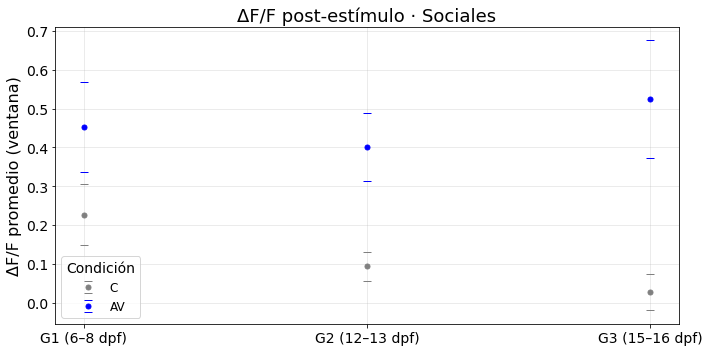

In [721]:
# ================================================================
# Gráfico ΔF/F promedio (ventana) con consistencia ≥2
# ================================================================

solo_social = True  # True = sociales, False = aislados
consistencia_repeticion = 2

# Colores y marcadores
if solo_social:
    colors = {"C": "gray", "AV": "blue"}
    marker_cond = "."
else:
    colors = {"C": "gray", "AV": "red"}
    marker_cond = "x"

rows = []

for fish_id, area in areas.items():
    edad = getattr(area, "edad", -999)
    aislado = getattr(area, "aislado", 1)

    # Filtrar por condición social/aislado
    if solo_social and aislado != 0:
        continue
    if not solo_social and aislado != 1:
        continue

    # Asignar grupo etario
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue

    # --- Paso 1: máscara de neuronas activas en ≥ consistencia_repeticion trials
    Nh = None
    Nh_plus_mask = None

    for tr in getattr(area, "trials_rea", []):
        cond = _get_condition(tr)
        if cond != "AV":
            continue

        rb = getattr(tr, "roi_dffs", None)  # usamos ΔF/F
        if rb is None or region_key not in rb:
            continue

        B = np.asarray(area.trials_rea[0].roi_binaries_rea2[region_key])  # binarizadas
        B = (B > 0).astype(int)
        Nh = B.shape[0]

        t, tr_fps = _trial_timebase(tr, fps)
        stim_frame = int(round(stim_s * tr_fps))
        win_idx = np.arange(stim_frame - frames_pre, stim_frame + frames_post + 1)
        win_idx = win_idx[(win_idx >= 0) & (win_idx < B.shape[1])]

        resp = B[:, win_idx].sum(axis=1) > 0
        if Nh_plus_mask is None:
            Nh_plus_mask = resp.astype(int)
        else:
            Nh_plus_mask += resp.astype(int)

    if Nh is None or Nh_plus_mask is None:
        continue

    active_mask = Nh_plus_mask >= consistencia_repeticion
    if not active_mask.any():
        continue

    # --- Paso 2: extraer ΔF/F de esas neuronas y calcular promedio por trial
    for tr in getattr(area, "trials_rea", []):
        cond = _get_condition(tr)

        rb_dff = getattr(tr, "roi_dffs", None)
        if rb_dff is None or region_key not in rb_dff:
            continue
        D = np.asarray(rb_dff[region_key])
        if D.ndim != 2:
            continue

        D_sel = D[active_mask, :]
        if D_sel.shape[0] == 0:
            continue

        t, tr_fps = _trial_timebase(tr, fps)
        stim_frame = int(round(stim_s * tr_fps))
        win_idx = np.arange(stim_frame - frames_pre, stim_frame + frames_post + 1)
        win_idx = win_idx[(win_idx >= 0) & (win_idx < D.shape[1])]

        dff_mean = D_sel[:, win_idx].mean()
        rows.append({
            "fish_id": fish_id,
            "grupo": gname,
            "cond": cond,
            "dff_mean": dff_mean
        })

# --- Construir DataFrame
df_dff = pd.DataFrame(rows)

# --- Resumen estadístico
summary = (df_dff
           .groupby(["grupo","cond"])
           .agg(mean_dff=("dff_mean","mean"),
                sd_dff=("dff_mean","std"),
                n=("dff_mean","count"))
           .reset_index())
summary["sem_dff"] = summary["sd_dff"] / np.sqrt(summary["n"])

# --- Gráfico
order = list(grupos.keys())

fig, ax = plt.subplots(figsize=(10,5))
for cond in ["C","AV"]:
    sub = summary[summary["cond"]==cond]
    x = [order.index(g) for g in sub["grupo"]]
    ax.errorbar(x, sub["mean_dff"], yerr=sub["sem_dff"],
                fmt=marker_cond, color=colors[cond], label=cond,
                capsize=4, markersize=10, linewidth=0)

# Eje X con grupos
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, fontsize=14)

# Ejes y título
ax.set_ylabel("ΔF/F promedio (ventana)", fontsize=16)
ax.set_title("ΔF/F post-estímulo · " + ("Sociales" if solo_social else "Aislados"), fontsize=18)

ax.tick_params(axis="both", labelsize=14)
ax.legend(title="Condición", fontsize=12, title_fontsize=14)
ax.grid(alpha=0.3)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()


In [725]:
# ================================================================
# Plots with AV metrics (peak + FWHM)
# ================================================================
for gname in grupos.keys():
    data = resultados[gname]
    mean_C, sem_C   = _mean_sem_over_animals(data['C']["animals"])
    mean_AV, sem_AV = _mean_sem_over_animals(data['AV']["animals"])

    if mean_AV is not None:
        t_plot = data['AV']["t"][:len(mean_AV)] - stim_s
    elif mean_C is not None:
        t_plot = data['C']["t"][:len(mean_C)] - stim_s
    else:
        print(f"[{gname}] No data.")
        continue

    # --- counters
    Np      = data["Np"]
    Nn      = data["Nn"]
    Nn_plus = data["Nn_plus"]

    fig = plt.figure(figsize=(10,5))
    plt.axvline(0, linestyle='--', linewidth=1, alpha=0.8, label="Stimulus")

    # shaded analysis window
    plt.axvspan(-frames_pre/float(fps), frames_post/float(fps), 
                color="gray", alpha=0.15, label="Analysis window")

    # --- Individual AV trials (light blue)
    if "trials" in data["AV"]:
        for trial_curve in data["AV"]["trials"]:
            m = min(len(t_plot), len(trial_curve))
            plt.plot(t_plot[:m], trial_curve[:m],
                     color="skyblue", alpha=0.5, linewidth=1)

    # Curve C (mean ± SEM)
    if mean_C is not None:
        plt.plot(t_plot, mean_C[:len(t_plot)], 
                 label=f"C", 
                 color='gray', marker='.')
        m = min(len(t_plot), len(sem_C)) if sem_C is not None else 0
        if m>0:
            plt.fill_between(t_plot[:m], mean_C[:m]-sem_C[:m], mean_C[:m]+sem_C[:m],
                             alpha=0.2, color='gray')

    # Curve AV (mean ± SEM)
    if mean_AV is not None:
        color = 'blue' if solo_social else 'red'
        plt.plot(t_plot, mean_AV[:len(t_plot)], 
                 label=f"AV", 
                 color=color, marker='.')
        m = min(len(t_plot), len(sem_AV)) if sem_AV is not None else 0
        if m>0:
            plt.fill_between(t_plot[:m], mean_AV[:m]-sem_AV[:m], mean_AV[:m]+sem_AV[:m],
                             alpha=0.2, color=color)

        # --- AV metrics ---
        met = calcular_metrica_curva(t_rel, mean_AV, stim_window=(-1*frames_pre, frames_post))
        if met:
            # dashed line at the peak
            plt.axvline(met["delay"], linestyle="--", color="red", linewidth=1.5, label=f"Peak",)
            # plt.plot(met["delay"], met["peak_val"], "ro")

            # horizontal bar at FWHM
            if not np.isnan(met["fwhm_left"]) and not np.isnan(met["fwhm_right"]):
                plt.hlines(met["peak_val"]/2, met["fwhm_left"], met["fwhm_right"],
                           colors="black", linewidth=2, label=f"Half-maximum width",)

    plt.xlabel("Time to stimulus (s)")
    plt.ylabel("Proportion of active neurons")
    plt.ylim(0,.4)
    plt.xlim(-6, 6)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    fig.patch.set_facecolor('white')

    # --- title with counters
    plt.title(f"{gname} · {'Social' if solo_social else 'Isolated'}\n"
              f"$N_p$={Np}, $N_n$={Nn}, $N_{{n+}}$={Nn_plus}")
    # plt.savefig( f'{gname}_Social_{solo_sociales}_++_C2.pdf', dpi=300, bbox_inches='tight')
    
    plt.show()

[G1 (6–8 dpf)] No data.


KeyError: 'Np'

In [723]:
# ----- Colors -----
colors = {
    "G1 (6–8 dpf)":     "#4D76C4",   # dark gray/blue
    "G2 (12–13 dpf)":   "#385696",   # blue
    "G3 (15–16 dpf)":   "#27278B",   # navy
    "G2 isolated":      "#d62728",   # red
}

# ================================================================
# Plots with AV metrics (peak + FWHM)
# ================================================================
for gname in grupos.keys():
    data = resultados[gname]
    mean_C, sem_C   = _mean_sem_over_animals(data['C']["animals"])
    mean_AV, sem_AV = _mean_sem_over_animals(data['AV']["animals"])

    if mean_AV is not None:
        t_plot = data['AV']["t"][:len(mean_AV)] - stim_s
    elif mean_C is not None:
        t_plot = data['C']["t"][:len(mean_C)] - stim_s
    else:
        print(f"[{gname}] No data.")
        continue

    # --- counters
    Np      = data["Np"]
    Nn      = data["Nn"]
    Nn_plus = data["Nn_plus"]

    fig = plt.figure(figsize=(10,5))
    plt.axvline(0, linestyle='--', linewidth=1, alpha=0.8, label="Stimulus")

    # shaded analysis window
    plt.axvspan(-frames_pre/float(fps), frames_post/float(fps), 
                color="gray", alpha=0.15, label="Analysis window")

    # --- Individual AV trials (light blue)
    if "trials" in data["AV"]:
        for trial_curve in data["AV"]["trials"]:
            m = min(len(t_plot), len(trial_curve))
            plt.plot(t_plot[:m], trial_curve[:m],
                     color="skyblue", alpha=0.5, linewidth=1)

    # Curve C (mean ± SEM)
    if mean_C is not None:
        plt.plot(t_plot, mean_C[:len(t_plot)], 
                 label="Control", 
                 color='gray', marker='.')
        m = min(len(t_plot), len(sem_C)) if sem_C is not None else 0
        if m > 0:
            plt.fill_between(t_plot[:m], mean_C[:m]-sem_C[:m], mean_C[:m]+sem_C[:m],
                             alpha=0.2, color='gray')

    # Curve AV (mean ± SEM)
    if mean_AV is not None:
        # assign color depending on group/social condition
        if solo_social:
            curve_color = colors.get(gname, "blue")
            marker_use = '.'
        else:
            curve_color = colors["G2 isolated"]
            marker_use = 'x'

        plt.plot(t_plot, mean_AV[:len(t_plot)], 
                 label="Audiovisual", 
                 color=curve_color, marker=marker_use)
        m = min(len(t_plot), len(sem_AV)) if sem_AV is not None else 0
        if m > 0:
            plt.fill_between(t_plot[:m], mean_AV[:m]-sem_AV[:m], mean_AV[:m]+sem_AV[:m],
                             alpha=0.2, color=curve_color)

        # --- AV metrics ---
        met = calcular_metrica_curva(t_rel, mean_AV, stim_window=(-1*frames_pre, frames_post))
        if met:
            # dashed line at the peak
            plt.axvline(met["delay"], linestyle="--", color="red", linewidth=1.5, label="Peak")
            # horizontal bar at FWHM
            if not np.isnan(met["fwhm_left"]) and not np.isnan(met["fwhm_right"]):
                plt.hlines(met["peak_val"]/2, met["fwhm_left"], met["fwhm_right"],
                           colors="black", linewidth=2, label="Half-maximum width")

    plt.xlabel("Time relative to stimulus (s)")
    plt.ylabel("Proportion of active neurons")
    plt.ylim(0, .4)
    plt.xlim(-6, 6)
    plt.grid(alpha=0.3)

    # --- manual legend with 4 entries (fixed colors + markers) ---
    handles = [
        Line2D([0],[0], marker='.', color='none',
               markerfacecolor=colors["G1 (6–8 dpf)"], markersize=14, label="$G_1$"),
        Line2D([0],[0], marker='.', color='none',
               markerfacecolor=colors["G2 (12–13 dpf)"], markersize=14, label="$G_2^{s}$"),
        Line2D([0],[0], marker='.', color='none',
               markerfacecolor=colors["G3 (15–16 dpf)"], markersize=14, label="$G_3$"),
        Line2D([0],[0], marker='x',
               color=colors["G2 isolated"], markersize=14, label="$G_2^{a}$"),
    ]
    ax = plt.gca()
    ax.legend(handles=handles, title="Group",
              frameon=False, loc="upper right", fontsize=12, title_fontsize=13)

    plt.tight_layout()
    fig.patch.set_facecolor('white')

    # --- title with counters
    plt.title(f"{gname} · {'Social' if solo_social else 'Isolated'}\n"
              f"$N_p$={Np}, $N_n$={Nn}, $N_{{n+}}$={Nn_plus}")

    plt.show()


[G1 (6–8 dpf)] No data.


KeyError: 'Np'

In [447]:
resultados.keys()

dict_keys(['G1 (6–8 dpf)', 'G2 (12–13 dpf)', 'G3 (15–16 dpf)'])

[G1 (6–8 dpf)] No data.


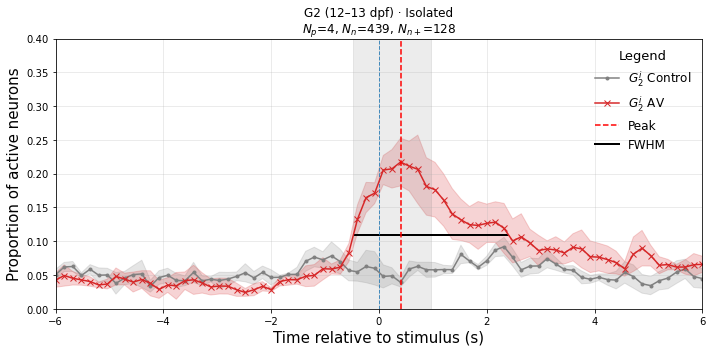

[G3 (15–16 dpf)] No data.


In [523]:
from matplotlib.lines import Line2D
# mapping from group names to LaTeX labels
group_labels = {
    "G1 (6–8 dpf)": "$G_1$",
    "G2 (12–13 dpf)": "$G_2^{s}$",
    "G3 (15–16 dpf)": "$G_3$",
    "G2 isolated": "$G_2^{i}$",
}
# ================================================================
# Plots with AV metrics (peak + FWHM)
# ================================================================
for gname in grupos.keys():
    data = resultados[gname]
    mean_C, sem_C   = _mean_sem_over_animals(data['C']["animals"])
    mean_AV, sem_AV = _mean_sem_over_animals(data['AV']["animals"])

    if mean_AV is not None:
        t_plot = data['AV']["t"][:len(mean_AV)] - stim_s
    elif mean_C is not None:
        t_plot = data['C']["t"][:len(mean_C)] - stim_s
    else:
        print(f"[{gname}] No data.")
        continue

    # --- counters
    Np      = data["Np"]
    Nn      = data["Nn"]
    Nn_plus = data["Nn_plus"]

    fig, ax = plt.subplots(figsize=(10,5))
    ax.axvline(0, linestyle='--', linewidth=1, alpha=0.8, label="Stimulus")
    ax.axvspan(-frames_pre/float(fps), frames_post/float(fps), 
               color="gray", alpha=0.15, label="Analysis window")

    # --- Individual AV trials (light blue)
    if "trials" in data["AV"]:
        for trial_curve in data["AV"]["trials"]:
            m = min(len(t_plot), len(trial_curve))
            ax.plot(t_plot[:m], trial_curve[:m],
                    color="skyblue", alpha=0.5, linewidth=1)

    # prepare legend handles
    handles = []

    # Curve C (mean ± SEM)
    if mean_C is not None:
        in_labele = group_labels[gname] if solo_social else group_labels["G2 isolated"]
        lineC, = ax.plot(t_plot, mean_C[:len(t_plot)], 
                         color='gray', marker='.', label="Control")
        m = min(len(t_plot), len(sem_C)) if sem_C is not None else 0
        if m > 0:
            ax.fill_between(t_plot[:m], mean_C[:m]-sem_C[:m], mean_C[:m]+sem_C[:m],
                            alpha=0.2, color='gray')
        handles.append(Line2D([0],[0], color='gray', marker='.', label=f"{in_labele} Control"))

    # Curve AV (mean ± SEM)
        if mean_AV is not None:
            curve_color = colors.get(gname, "blue") if solo_social else colors["G2 isolated"]
            marker_use = '.' if solo_social else 'x'

            ax.plot(t_plot, mean_AV[:len(t_plot)], 
                    color=curve_color, marker=marker_use,
                    label=in_labele)  # <-- use LaTeX label
            m = min(len(t_plot), len(sem_AV)) if sem_AV is not None else 0
            if m > 0:
                ax.fill_between(t_plot[:m], mean_AV[:m]-sem_AV[:m], mean_AV[:m]+sem_AV[:m],
                                alpha=0.2, color=curve_color)

            handles.append(Line2D([0],[0], color=curve_color, marker=marker_use, 
                                label=f'{in_labele} AV'))  # <-- same here

        # --- AV metrics ---
        met = calcular_metrica_curva(t_rel, mean_AV, stim_window=(-1*frames_pre, frames_post))
        if met:
            # Peak
            ax.axvline(met["delay"], linestyle="--", color="red", linewidth=1.5)
            handles.append(Line2D([0],[0], color="red", linestyle="--", label="Peak"))

            # FWHM
            if not np.isnan(met["fwhm_left"]) and not np.isnan(met["fwhm_right"]):
                ax.hlines(met["peak_val"]/2, met["fwhm_left"], met["fwhm_right"],
                          colors="black", linewidth=2)
                handles.append(Line2D([0],[0], color="black", linewidth=2, label="FWHM"))

    ax.set_xlabel("Time relative to stimulus (s)",fontsize=15 )
    ax.set_ylabel("Proportion of active neurons",fontsize=15)
    ax.set_ylim(0,.4)
    ax.set_xlim(-6, 6)
    ax.grid(alpha=0.3)

    # legend with exactly what was plotted
    ax.legend(handles=handles, title="Legend", frameon=False, loc="upper right",
              fontsize=12, title_fontsize=13)

    fig.patch.set_facecolor('white')
    ax.set_title(f"{gname} · {'Social' if solo_social else 'Isolated'}\n"
                 f"$N_p$={Np}, $N_n$={Nn}, $N_{{n+}}$={Nn_plus}")

    plt.tight_layout()
    #plt.savefig( f'{gname}_Sociales_{solo_sociales}_F_C2.pdf', dpi=300, bbox_inches='tight')

    plt.show()


## Lateralidad Guardado

In [ ]:
colors = {
    "G1 (6–8 dpf)":     "#4D76C4",   # dark gray/blue
    "G2 (12–13 dpf)":   "#385696",   # blue
    "G3 (15–16 dpf)":   "#27278B",   # navy
    "G2 isolated":      "#d62728",   # red
}

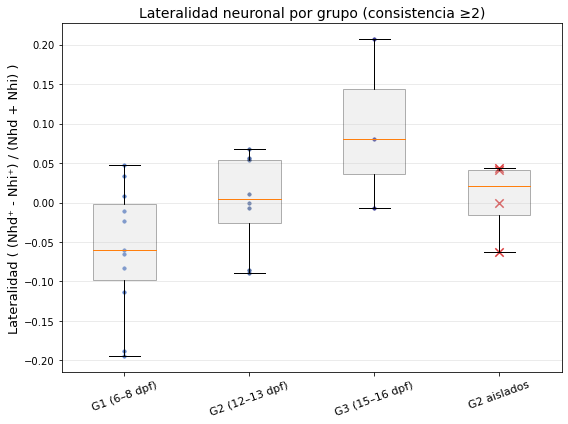

In [561]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D

# ----------------------------
# Parámetros
# ----------------------------
consistencia_min = 2  # >=2 trials activos
region_key = "Hb"

# ----------------------------
# Calcular lateralidad por pez
# ----------------------------
rows = []

for fish_id, area in areas.items():
    edad = int(getattr(area, "edad", -999))
    aislado = int(getattr(area, "aislado", 1))

    # Asignar grupo etario
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue

    grupo_plot = gname if not (gname=="G2 (12–13 dpf)" and aislado==1) else "G2 aislados"

    # Máscara hemisferio (True = izquierda, False = derecha)
    left_mask = np.array(area.roi_lefties[region_key], dtype=bool)

    # Neuronas totales por lado
    Nnhi = left_mask.sum()
    Nnhd = (~left_mask).sum()

    # --- consistencia: cuántos trials se prendió cada ROI ---
    consistencias = np.zeros(left_mask.shape[0], dtype=int)

    for tr in getattr(area, "trials_rea", []):
        cond = _get_condition(tr)
        if cond != "AV":  # solo trials AV
            continue
        try:
            t, tr_fps = _trial_timebase(tr, fps)
        except Exception:
            continue

        stim_frame = int(round(stim_s * tr_fps))
        win_idx = np.arange(stim_frame-frames_pre, stim_frame+frames_post+1)
        rb = getattr(tr, "roi_binaries_rea2", None)
        if rb is None or region_key not in rb:
            continue
        B = (np.asarray(rb[region_key]) > 0).astype(int)

        active = (B[:, win_idx].sum(axis=1) > 0).astype(int)
        consistencias += active

    # Neuronas activas con consistencia >= consistencia_min
    active_mask = consistencias >= consistencia_min

    Nnhi_plus = (active_mask & left_mask).sum()
    Nnhd_plus = (active_mask & ~left_mask).sum()

    # Calcular lateralidad
    denom = (Nnhi + Nnhd)
    if denom > 0:
        L = (Nnhd_plus - Nnhi_plus) / denom
        # L = (Nnhd_plus/Nnhd - Nnhi_plus/Nnhi) 
        rows.append({"fish_id": fish_id, "grupo_plot": grupo_plot, "lateralidad": L})

df_lat = pd.DataFrame(rows)

# ----------------------------
# Gráfico
# ----------------------------
order_grupos = ["G1 (6–8 dpf)", "G2 (12–13 dpf)", "G3 (15–16 dpf)", "G2 aislados"]
colors = {
    "G1 (6–8 dpf)": "#4D76C4",
    "G2 (12–13 dpf)":'#385696',
    "G2 aislados": "#d62728",
    "G3 (15–16 dpf)": "#27278B"
}
markers = {
    "G1 (6–8 dpf)": ".",
    "G2 (12–13 dpf)": ".",
    "G2 aislados": "x",
    "G3 (15–16 dpf)": "."
}

fig, ax = plt.subplots(figsize=(8,6))

# Boxplots grises
data_box = [df_lat.loc[df_lat["grupo_plot"]==g,"lateralidad"] for g in order_grupos]
bp = ax.boxplot(data_box, positions=np.arange(len(order_grupos)), widths=0.5,
                patch_artist=True, showfliers=False)
for patch in bp["boxes"]:
    patch.set_facecolor("lightgray")
    patch.set_alpha(0.3)






# Puntos por pez
for i,g in enumerate(order_grupos):
    sub = df_lat[df_lat["grupo_plot"]==g]
    ax.scatter(np.full(len(sub), i),
               sub["lateralidad"],
               color=colors[g],
               marker=markers[g],
               s=70 if g=="G2 aislados" else 50,
               linewidths=1.5 if g=="G2 aislados" else 0.5,
               alpha=0.9)

ax.set_xticks(np.arange(len(order_grupos)))
ax.set_xticklabels(order_grupos, rotation=20, fontsize=11)
ax.set_ylabel("Lateralidad ( (Nhd⁺ - Nhi⁺) / (Nhd + Nhi) )", fontsize=13)
ax.set_title(f"Lateralidad neuronal por grupo (consistencia ≥{consistencia_min})", fontsize=14)
# ax.axhline(0, color="black", linestyle="--", alpha=0.6)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
# plt.savefig('Lateralidad_por_grupo_y_condicion.pdf', dpi=300, bbox_inches='tight')
plt.show()


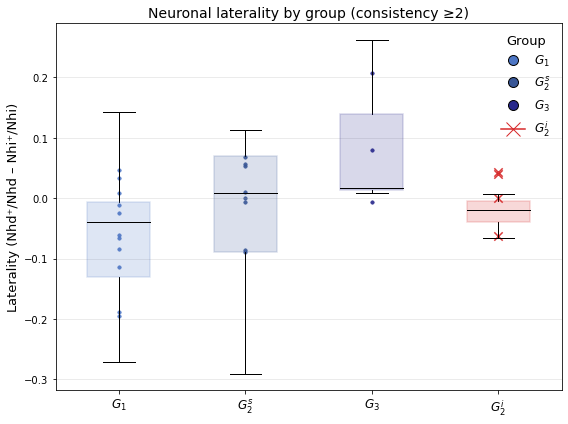

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ----------------------------
# Parameters
# ----------------------------
consistencia_min = 2  # ≥2 active trials
region_key = "Hb"

# ----------------------------
# Compute laterality per fish
# ----------------------------
rows = []

for fish_id, area in areas.items():
    edad = int(getattr(area, "edad", -999))
    aislado = int(getattr(area, "aislado", 1))

    # Assign age group
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue

    grupo_plot = gname if not (gname == "G2 (12–13 dpf)" and aislado == 1) else "G2 isolated"

    # Hemisphere mask (True = left, False = right)
    left_mask = np.array(area.roi_lefties[region_key], dtype=bool)

    # Total neurons per side
    Nnhi = left_mask.sum()
    Nnhd = (~left_mask).sum()

    # --- consistency: how many trials each ROI was active ---
    consistencias = np.zeros(left_mask.shape[0], dtype=int)

    for tr in getattr(area, "trials_rea", []):
        cond = _get_condition(tr)
        if cond != "AV":
            continue
        try:
            t, tr_fps = _trial_timebase(tr, fps)
        except Exception:
            continue

        stim_frame = int(round(stim_s * tr_fps))
        win_idx = np.arange(stim_frame-frames_pre, stim_frame+frames_post+1)
        rb = getattr(tr, "roi_binaries_rea2", None)
        if rb is None or region_key not in rb:
            continue
        B = (np.asarray(rb[region_key]) > 0).astype(int)

        active = (B[:, win_idx].sum(axis=1) > 0).astype(int)
        consistencias += active

    # Active neurons with consistency ≥ consistencia_min
    active_mask = consistencias >= consistencia_min
    Nnhi_plus = (active_mask & left_mask).sum()
    Nnhd_plus = (active_mask & ~left_mask).sum()

    # Compute laterality
    denom = (Nnhi + Nnhd)
    if denom > 0:
        L = (Nnhd_plus - Nnhi_plus) / denom
        L_2 = Nnhd_plus/Nnhd - Nnhi_plus/Nnhi
        rows.append({"fish_id": fish_id, "grupo_plot": grupo_plot, "laterality": L, "laterality_2": L_2})

df_lat = pd.DataFrame(rows)

# ----------------------------
# Plot
# ----------------------------
order_grupos = ["G1 (6–8 dpf)", "G2 (12–13 dpf)", "G3 (15–16 dpf)", "G2 isolated"]
colors = {
    "G1 (6–8 dpf)": "#4D76C4",
    "G2 (12–13 dpf)": '#385696',
    "G3 (15–16 dpf)": "#27278B",
    "G2 isolated": "#d62728"
}
markers = {
    "G1 (6–8 dpf)": ".",
    "G2 (12–13 dpf)": ".",
    "G3 (15–16 dpf)": ".",
    "G2 isolated": "x"
}

fig, ax = plt.subplots(figsize=(8,6))
# Boxplots (colored by group)
data_box = [df_lat.loc[df_lat["grupo_plot"]==g, "laterality"] for g in order_grupos]

bp = ax.boxplot(data_box, positions=np.arange(len(order_grupos)), widths=0.5,
                patch_artist=True, showfliers=False)

for patch, g in zip(bp["boxes"], order_grupos):
    patch.set_facecolor(colors[g])
    patch.set_alpha(0.18)             # soft fill
    patch.set_edgecolor(colors[g])
    patch.set_linewidth(1.5)

for line in bp["medians"] + bp["whiskers"] + bp["caps"]:
    line.set_color("black")
    line.set_linewidth(1.0)


# Points per fish
for i, g in enumerate(order_grupos):
    sub = df_lat[df_lat["grupo_plot"]==g]
    ax.scatter(np.full(len(sub), i),
               sub["laterality"],
               color=colors[g],
               marker=markers[g],
               s=70 if g=="G2 isolated" else 50,
               linewidths=1.5 if g=="G2 isolated" else 0.5,
               alpha=0.9)

# Axes and labels
ax.set_xticks(np.arange(len(order_grupos)))
ax.set_xticklabels(["$G_1$", "$G_2^{s}$", "$G_3$", "$G_2^{i}$"], fontsize=12)
ax.set_ylabel("Laterality ((Nhd⁺ – Nhi⁺) / (Nhd + Nhi))", fontsize=13)
#ax.set_ylabel("Laterality (Nhd⁺/Nhd – Nhi⁺/Nhi)", fontsize=13)

ax.set_title(f"Neuronal laterality by group (consistency ≥{consistencia_min})", fontsize=14)
ax.grid(axis="y", alpha=0.3)

# Manual legend with 4 entries
handles = [
    Line2D([0],[0], marker='.', color='none', markerfacecolor=colors["G1 (6–8 dpf)"], markersize=20, label="$G_1$"),
    Line2D([0],[0], marker='.', color='none', markerfacecolor=colors["G2 (12–13 dpf)"], markersize=20, label="$G_2^{s}$"),
    Line2D([0],[0], marker='.', color='none', markerfacecolor=colors["G3 (15–16 dpf)"], markersize=20, label="$G_3$"),
    Line2D([0],[0], marker='x', color=colors["G2 isolated"], markersize=14, label="$G_2^{i}$"),
]
ax.legend(handles=handles, title="Group", frameon=False, loc="upper right", fontsize=12, title_fontsize=13)

plt.tight_layout()
#plt.savefig('Lateralidad_por_grupo_y_condicion_F.pdf', dpi=300, bbox_inches='tight')

plt.show()


In [567]:
from scipy.stats import ttest_1samp, wilcoxon

# ----------------------------------------------------
# Evaluar L y L2 por grupo contra 0
# ----------------------------------------------------
results = []
for metric in ["laterality", "laterality_2"]:
    for gname, sub in df_lat.groupby("grupo_plot"):
        vals = sub[metric].dropna().values
        if len(vals) < 2:
            continue

        # One-sample t-test contra 0
        tstat, pval_t = ttest_1samp(vals, 0.0)

        # Wilcoxon signed-rank contra 0 (si todos iguales a 0 no corre)
        try:
            wstat, pval_w = wilcoxon(vals - 0.0)
        except ValueError:
            pval_w = np.nan

        results.append({
            "grupo": gname,
            "metric": metric,
            "n": len(vals),
            "mean": vals.mean(),
            "sem": vals.std(ddof=1)/np.sqrt(len(vals)),
            "t_pval": pval_t,
            "wilcoxon_pval": pval_w
        })

df_stats = pd.DataFrame(results)

print("=== Significance tests against 0 ===")
print(df_stats)


=== Significance tests against 0 ===
            grupo        metric   n      mean       sem    t_pval  \
0    G1 (6–8 dpf)    laterality  11 -0.059303  0.024647  0.036929   
1  G2 (12–13 dpf)    laterality   8  0.000951  0.021502  0.965964   
2     G2 isolated    laterality   4  0.005641  0.024837  0.834929   
3  G3 (15–16 dpf)    laterality   3  0.093317  0.062089  0.271716   
4    G1 (6–8 dpf)  laterality_2  11 -0.062373  0.034380  0.099713   
5  G2 (12–13 dpf)  laterality_2   8 -0.024781  0.046379  0.609670   
6     G2 isolated  laterality_2   4 -0.024628  0.015816  0.217300   
7  G3 (15–16 dpf)  laterality_2   3  0.095917  0.083036  0.367403   

   wilcoxon_pval  
0       0.041992  
1       1.000000  
2       1.000000  
3       0.500000  
4       0.123047  
5       0.843750  
6       0.250000  
7       0.250000  


c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\scipy\stats\morestats.py:3141: UserWarning: Exact p-value calculation does not work if there are ties. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\scipy\stats\morestats.py:3155: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\scipy\stats\morestats.py:3141: UserWarning: Exact p-value calculation does not work if there are ties. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\scipy\stats\morestats.py:3155: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


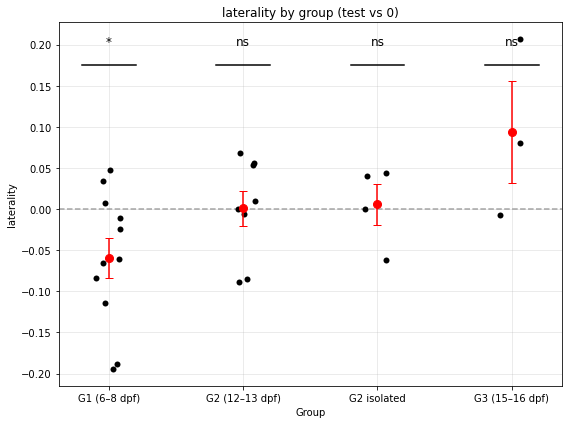

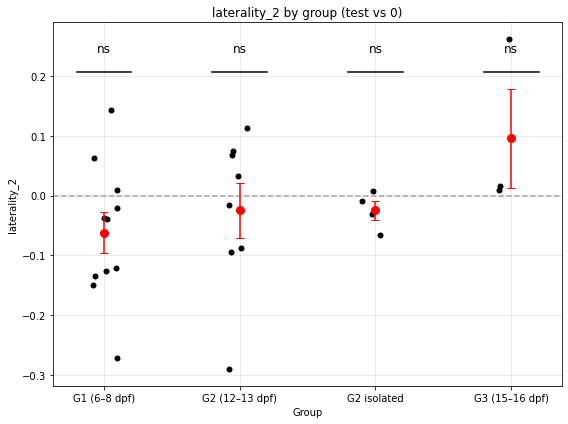

In [568]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_1samp, wilcoxon

def add_sig_vs_zero(ax, xpos, y, pval, h=0.02, col="black"):
    """Dibuja línea horizontal con asteriscos de significancia contra 0."""
    if pval < 0.001:
        text = "***"
    elif pval < 0.01:
        text = "**"
    elif pval < 0.05:
        text = "*"
    else:
        text = "ns"
    ax.plot([xpos-0.2, xpos+0.2], [y, y], lw=1.5, c=col)
    ax.text(xpos, y+h, text, ha="center", va="bottom", color=col, fontsize=12)

# ============================================================
# Graficar distribuciones y significancia vs 0
# ============================================================
for metric in ["laterality", "laterality_2"]:
    fig, ax = plt.subplots(figsize=(8,6))

    # puntos individuales
    sns.stripplot(data=df_lat, x="grupo_plot", y=metric,
                  color="black", jitter=True, size=6, ax=ax)

    # medias y SEM
    summary = (df_lat.groupby("grupo_plot")[metric]
               .agg(mean="mean", sem=lambda x: x.std(ddof=1)/np.sqrt(len(x))))
    for i, (gname, row) in enumerate(summary.iterrows()):
        ax.errorbar(i, row["mean"], yerr=row["sem"], 
                    fmt="o", color="red", capsize=4, markersize=8, zorder=10)

    # eje horizontal en 0
    ax.axhline(0, linestyle="--", color="gray", alpha=0.7)

    # test de significancia vs 0
    ymax = df_lat[metric].max()
    h = (ymax - df_lat[metric].min()) * 0.05
    for i, gname in enumerate(summary.index):
        vals = df_lat.loc[df_lat["grupo_plot"]==gname, metric].dropna().values
        if len(vals) > 1:
            # podés elegir: t-test o Wilcoxon
            try:
                _, pval = wilcoxon(vals)
            except ValueError:
                _, pval = ttest_1samp(vals, 0.0)
            add_sig_vs_zero(ax, i, row["mean"]+row["sem"]+h, pval, h=h)

    ax.set_ylabel(metric)
    ax.set_xlabel("Group")
    ax.set_title(f"{metric} by group (test vs 0)")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [573]:
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

# Filtrar sociales
df_soc = df_lat[df_lat["grupo_plot"].isin(["G1 (6–8 dpf)", "G2 (12–13 dpf)", "G3 (15–16 dpf)"])].copy()

# --- Modelo lineal (OLS)
model_ols = smf.ols("laterality_2 ~ C(grupo_plot)", data=df_soc).fit()
print(model_ols.summary())

# --- ANOVA tipo II
anova_res = anova_lm(model_ols, typ=2)
print("\n=== ANOVA (efecto del grupo etario en la lateralidad) ===")
print(anova_res)


                            OLS Regression Results                            
Dep. Variable:           laterality_2   R-squared:                       0.168
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     1.925
Date:                Thu, 02 Oct 2025   Prob (F-statistic):              0.173
Time:                        07:47:59   Log-Likelihood:                 16.332
No. Observations:                  22   AIC:                            -26.66
Df Residuals:                      19   BIC:                            -23.39
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

In [574]:
# ==============================================================
# Interpretación automática de ANOVA OLS para efecto de la edad
# ==============================================================

import numpy as np

# Resultados del modelo y ANOVA (ya corridos antes)
print(model_ols.summary())
print(anova_res)

# --- Interpretación automática ---
def interpretar_anova(anova_df, alpha=0.05):
    res = []
    for factor, row in anova_df.iterrows():
        if factor == "Residual":
            continue
        pval = row["PR(>F)"]
        Fval = row["F"]
        if pval < 0.001:
            sig = "highly significant (***, p < 0.001)"
        elif pval < 0.01:
            sig = "very significant (**, p < 0.01)"
        elif pval < 0.05:
            sig = "significant (*, p < 0.05)"
        else:
            sig = "not significant (ns, p ≥ 0.05)"
        res.append(f"For factor **{factor}**: F = {Fval:.2f}, p = {pval:.4f} → Effect is {sig}.")
    return "\n".join(res)

print("\n=== INTERPRETATION ===")
print(interpretar_anova(anova_res))


                            OLS Regression Results                            
Dep. Variable:           laterality_2   R-squared:                       0.168
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     1.925
Date:                Thu, 02 Oct 2025   Prob (F-statistic):              0.173
Time:                        07:48:07   Log-Likelihood:                 16.332
No. Observations:                  22   AIC:                            -26.66
Df Residuals:                      19   BIC:                            -23.39
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

## FWHM Guardado


            grupo  mean_peak  sem_peak  mean_fwhm  sem_fwhm
0    G1 (6–8 dpf)   1.765905  0.205769   2.385455  0.250165
1  G2 (12–13 dpf)   0.736487  0.209760   2.060000  0.337300
2  G3 (15–16 dpf)   1.068999  0.388769   1.493333  0.192296


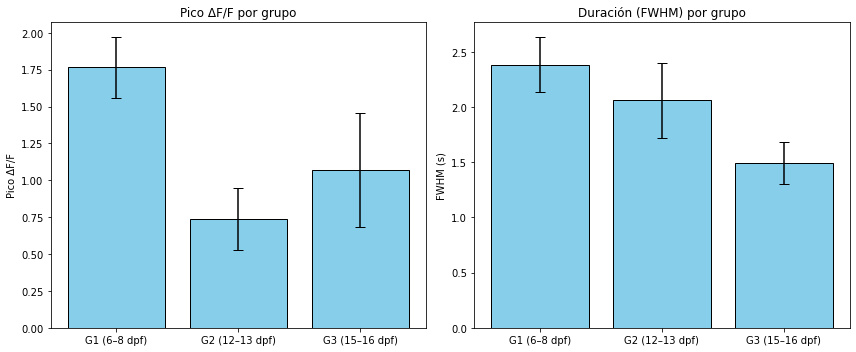

In [613]:
from scipy.signal import find_peaks

# ================================================================
# Funciones auxiliares
# ================================================================
def calcular_fwhm(t, y):
    """Calcula FWHM: ancho a mitad altura del pico máximo."""
    if y is None or len(y) == 0: 
        return np.nan
    peak_idx = np.argmax(y)
    peak_val = y[peak_idx]
    half = peak_val / 2.0

    # izquierda
    left_idx = np.where(y[:peak_idx] <= half)[0]
    if len(left_idx) > 0:
        left = t[left_idx[-1]]
    else:
        left = t[0]

    # derecha
    right_idx = np.where(y[peak_idx:] <= half)[0]
    if len(right_idx) > 0:
        right = t[peak_idx + right_idx[0]]
    else:
        right = t[-1]

    return right - left

def calcular_pico(t, y, stim_s, frames_pre, frames_post):
    """Devuelve el valor del pico dentro de la ventana de estímulo."""
    if y is None or len(y) == 0:
        return np.nan
    win_mask = (t >= stim_s-frames_pre/fps) & (t <= stim_s+frames_post/fps)
    if not win_mask.any():
        return np.nan
    return np.nanmax(y[win_mask])

# ================================================================
# Loop por peces
# ================================================================
df_metrics = []

for fish_id, area in areas.items():
    if getattr(area, "aislado", 1) != 0:  # solo sociales
        continue
    edad = getattr(area, "edad", -999)

    # asignar grupo
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue

    # Paso 1: neuronas consistentes (≥2 trials activas en ventana)
    Nh = None
    Nh_plus_mask = None
    for tr in getattr(area, "trials_rea", []):
        cond = _get_condition(tr)
        if cond != "AV":  # usamos trials AV para consistencia
            continue
        rb = getattr(tr, "roi_binaries_rea2", None)
        if rb is None or region_key not in rb:
            continue
        B = np.asarray(rb[region_key])
        B = (B > 0).astype(int)
        Nh = B.shape[0]

        t, tr_fps = _trial_timebase(tr, fps)
        stim_frame = int(round(stim_s * tr_fps))
        win_idx = np.arange(stim_frame-frames_pre, stim_frame+frames_post+1)
        win_idx = win_idx[(win_idx >= 0) & (win_idx < B.shape[1])]

        resp = B[:, win_idx].sum(axis=1) > 0
        if Nh_plus_mask is None:
            Nh_plus_mask = resp.astype(int)
        else:
            Nh_plus_mask += resp.astype(int)

    if Nh is None or Nh_plus_mask is None:
        continue
    active_mask = Nh_plus_mask >= 2  # neuronas consistentes

    if not active_mask.any():
        continue

    # Paso 2: ΔF/F de esas neuronas, solo si responden en trial
    trial_traces = []
    for tr in getattr(area, "trials_rea", []):
        cond = _get_condition(tr)
        rb_bin = getattr(tr, "roi_binaries_rea2", None)
        rb_dff = getattr(tr, "roi_dffs", None)
        if rb_bin is None or rb_dff is None or region_key not in rb_bin or region_key not in rb_dff:
            continue

        B = np.asarray(rb_bin[region_key]).astype(int)
        D = np.asarray(rb_dff[region_key]).astype(float)
        if B.ndim != 2 or D.ndim != 2:
            continue

        # seleccionamos neuronas consistentes
        B_sel = B[active_mask, :]
        D_sel = D[active_mask, :]

        if B_sel.shape[0] == 0:
            continue

        # filtro: solo neuronas que se prendieron en este trial
        trial_mask = B_sel[:, stim_frame-frames_pre:stim_frame+frames_post+1].sum(axis=1) > 0
        if not trial_mask.any():
            continue

        D_sel = D_sel[trial_mask, :]

        # promedio ΔF/F de esas neuronas
        t, tr_fps = _trial_timebase(tr, fps)
        m = min(D_sel.shape[1], len(t))
        trial_traces.append(D_sel[:, :m].mean(axis=0))

    if len(trial_traces) == 0:
        continue

    # Paso 3: promedio global (neurona+trial)
    t_common, _ = _truncate_to_common_length([t])
    traces, m = _truncate_to_common_length(trial_traces)
    if m == 0:
        continue
    trace_mean = np.vstack(traces).mean(axis=0)
    t_common = t[:m] - stim_s

    # Paso 4: métricas
    peak_val = calcular_pico(t_common, trace_mean, 0, frames_pre, frames_post)
    fwhm_val = calcular_fwhm(t_common, trace_mean)

    df_metrics.append({
        "fish_id": fish_id,
        "grupo": gname,
        "peak": peak_val,
        "fwhm": fwhm_val
    })

df_metrics = pd.DataFrame(df_metrics)

# ================================================================
# Agrupar por grupo
# ================================================================
summary = (df_metrics.groupby("grupo")
           .agg(mean_peak=("peak", "mean"),
                sem_peak=("peak", lambda x: x.std(ddof=1)/np.sqrt(len(x))),
                mean_fwhm=("fwhm", "mean"),
                sem_fwhm=("fwhm", lambda x: x.std(ddof=1)/np.sqrt(len(x))))
           .reset_index())

print(summary)

# ================================================================
# Gráficos
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Peak
axes[0].bar(summary["grupo"], summary["mean_peak"], 
            yerr=summary["sem_peak"], capsize=5, color="skyblue", edgecolor="black")
axes[0].set_ylabel("Pico ΔF/F")
axes[0].set_title("Pico ΔF/F por grupo")

# FWHM
axes[1].bar(summary["grupo"], summary["mean_fwhm"], 
            yerr=summary["sem_fwhm"], capsize=5, color="skyblue", edgecolor="black")
axes[1].set_ylabel("FWHM (s)")
axes[1].set_title("Duración (FWHM) por grupo")

plt.tight_layout()
plt.show()


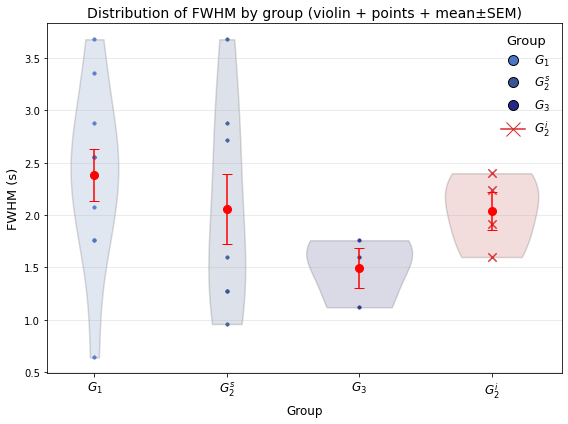

In [614]:
fig, ax = plt.subplots(figsize=(8,6))

# violin plots (colored by group, with transparency)
sns.violinplot(
    data=df_merged, x="grupo", y="fwhm",
    order=order_grupos, inner=None, cut=0,
    palette=colors, ax=ax
)

# ajustar alpha de cada violin (seaborn los guarda como colecciones de PolyCollections)
for violin in ax.collections:
    violin.set_alpha(0.18)

# scatter points (one per fish, on top)
for i, g in enumerate(order_grupos):
    sub = df_merged[df_merged["grupo"]==g]
    ax.scatter(
        np.full(len(sub), i), sub["fwhm"],
        color=colors[g],
        marker=markers[g],
        s=70 if g=="G2_i (12–13 dpf)" else 50,
        linewidths=1.5 if g=="G2_i (12–13 dpf)" else 0.5,
        alpha=0.9, zorder=3
    )

# summary stats (mean ± SEM)
summary = (df_merged.groupby("grupo")
           .agg(mean_fwhm=("fwhm", "mean"),
                sem_fwhm=("fwhm", lambda x: x.std(ddof=1)/np.sqrt(len(x))))
           .reset_index())

for pos, g in enumerate(order_grupos):
    row = summary.loc[summary["grupo"] == g]
    if not row.empty:
        ax.errorbar(pos, row["mean_fwhm"].values[0],
                    yerr=row["sem_fwhm"].values[0],
                    fmt="o", color="red", capsize=5, markersize=8,
                    zorder=10)

# axes and labels
ax.set_xticks(np.arange(len(order_grupos)))
ax.set_xticklabels(["$G_1$", "$G_2^{s}$", "$G_3$", "$G_2^{i}$"], fontsize=12)
ax.set_ylabel("FWHM (s)", fontsize=13)
ax.set_xlabel("Group", fontsize=12)
ax.set_title("Distribution of FWHM by group (violin + points + mean±SEM)", fontsize=14)
ax.grid(axis="y", alpha=0.3)

# manual legend
handles = [
    Line2D([0],[0], marker='.', color='none', markerfacecolor=colors["G1 (6–8 dpf)"], markersize=20, label="$G_1$"),
    Line2D([0],[0], marker='.', color='none', markerfacecolor=colors["G2 (12–13 dpf)"], markersize=20, label="$G_2^{s}$"),
    Line2D([0],[0], marker='.', color='none', markerfacecolor=colors["G3 (15–16 dpf)"], markersize=20, label="$G_3$"),
    Line2D([0],[0], marker='x', color=colors["G2_i (12–13 dpf)"], markersize=14, label="$G_2^{i}$"),
]
ax.legend(handles=handles, title="Group", frameon=False, loc="upper right", fontsize=12, title_fontsize=13)

plt.tight_layout()
#plt.savefig("fwhm_distribution_colored.pdf", dpi=300)
plt.show()


## Focalidad Guardado

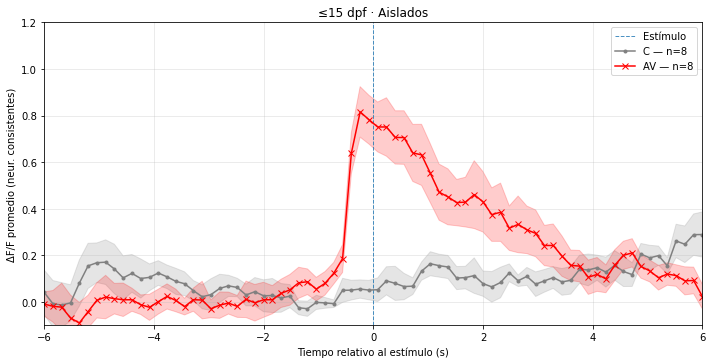

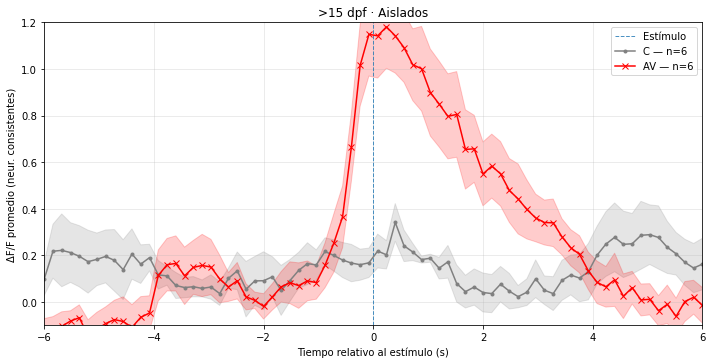

In [ ]:
# ================================================================
# Gráfico ΔF/F promedio (timecourse) usando neuronas consistentes (≥2 trials)
# ================================================================

consistencia_repeticion = 2
solo_social = False   # True = sociales, False = aislados

# Colores
color_C = "gray"
color_AV = "blue" if solo_social else "red"

# Diccionario para guardar resultados
resultados_dff = {g: {"C": {"animals": [], "t": None}, 
                      "AV": {"animals": [], "t": None}}
                  for g in grupos.keys()}

for fish_id, area in areas.items():
    edad = getattr(area, "edad", -999)
    aislado = getattr(area, "aislado", 1)

    # Filtrar por condición social/aislado
    if solo_social and aislado != 0:
        continue
    if not solo_social and aislado != 1:
        continue

    # Asignar grupo
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue

    # --- Paso 1: encontrar neuronas consistentes (en trials AV)
    Nh = None
    Nh_plus_mask = None
    for tr in getattr(area, "trials_rea", []):
        cond = _get_condition(tr)
        if cond != "AV":
            continue
        rb = getattr(tr, "roi_binaries_rea", None)
        if rb is None or region_key not in rb:
            continue
        B = np.asarray(rb[region_key])
        B = (B > 0).astype(int)
        Nh = B.shape[0]

        t, tr_fps = _trial_timebase(tr, fps)
        stim_frame = int(round(stim_s * tr_fps))
        win_idx = np.arange(stim_frame-frames_pre, stim_frame+frames_post+1)
        win_idx = win_idx[(win_idx >= 0) & (win_idx < B.shape[1])]

        resp = B[:, win_idx].sum(axis=1) > 0
        if Nh_plus_mask is None:
            Nh_plus_mask = resp.astype(int)
        else:
            Nh_plus_mask += resp.astype(int)

    if Nh is None or Nh_plus_mask is None:
        continue
    active_mask = Nh_plus_mask >= consistencia_repeticion
    if not active_mask.any():
        continue

    # --- Paso 2: extraer ΔF/F y calcular promedio por trial
    per_trial = {"C": [], "AV": []}
    per_time  = {"C": [], "AV": []}

    for tr in getattr(area, "trials_rea", []):
        cond = _get_condition(tr)
        rb_dff = getattr(tr, "roi_dffs", None)
        if rb_dff is None or region_key not in rb_dff:
            continue
        D = np.asarray(rb_dff[region_key])
        if D.ndim != 2:
            continue
        D_sel = D[active_mask, :]
        if D_sel.shape[0] == 0:
            continue

        t, tr_fps = _trial_timebase(tr, fps)
        m = min(len(t), D_sel.shape[1])
        per_trial[cond].append(D_sel[:, :m].mean(axis=0))
        per_time[cond].append(t[:m])

    # --- Paso 3: promedio por animal
    for cond in ["C", "AV"]:
        if len(per_trial[cond]) == 0:
            continue
        series, m = _truncate_to_common_length(per_trial[cond])
        if m == 0:
            continue
        tseries, _ = _truncate_to_common_length(per_time[cond])
        t_common = tseries[0] if len(tseries) > 0 else np.arange(m)/tr_fps
        animal_mean = np.vstack(series).mean(axis=0)

        resultados_dff[gname][cond]["animals"].append(animal_mean)
        if resultados_dff[gname][cond]["t"] is None:
            resultados_dff[gname][cond]["t"] = t_common

# ================================================================
# Graficar ΔF/F promedio por grupo
# ================================================================
for gname in grupos.keys():
    data = resultados_dff[gname]
    mean_C, sem_C   = _mean_sem_over_animals(data["C"]["animals"])
    mean_AV, sem_AV = _mean_sem_over_animals(data["AV"]["animals"])

    if mean_AV is not None:
        t_plot = data["AV"]["t"][:len(mean_AV)] - stim_s
    elif mean_C is not None:
        t_plot = data["C"]["t"][:len(mean_C)] - stim_s
    else:
        continue

    fig = plt.figure(figsize=(10,5))
    plt.axvline(0, linestyle="--", linewidth=1, alpha=0.8, label="Estímulo")

    # Control
    if mean_C is not None:
        plt.plot(t_plot, mean_C, label=f"C — n={len(data['C']['animals'])}", 
                 color=color_C, marker=".")
        if sem_C is not None:
            plt.fill_between(t_plot, mean_C-sem_C, mean_C+sem_C, alpha=0.2, color=color_C)

    # Audiovisual
    if mean_AV is not None:
        plt.plot(t_plot, mean_AV, label=f"AV — n={len(data['AV']['animals'])}", 
                 color=color_AV, marker=("." if solo_social else "x"))
        if sem_AV is not None:
            plt.fill_between(t_plot, mean_AV-sem_AV, mean_AV+sem_AV, alpha=0.2, color=color_AV)

    plt.xlabel("Tiempo relativo al estímulo (s)")
    plt.ylabel("ΔF/F promedio (neur. consistentes)")
    plt.ylim(-.1, 1.2)
    plt.xlim(-6, 6)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    fig.patch.set_facecolor("white")

    plt.title(f"{gname} · {'Sociales' if solo_social else 'Aislados'}")
    plt.show()
#2026 acá


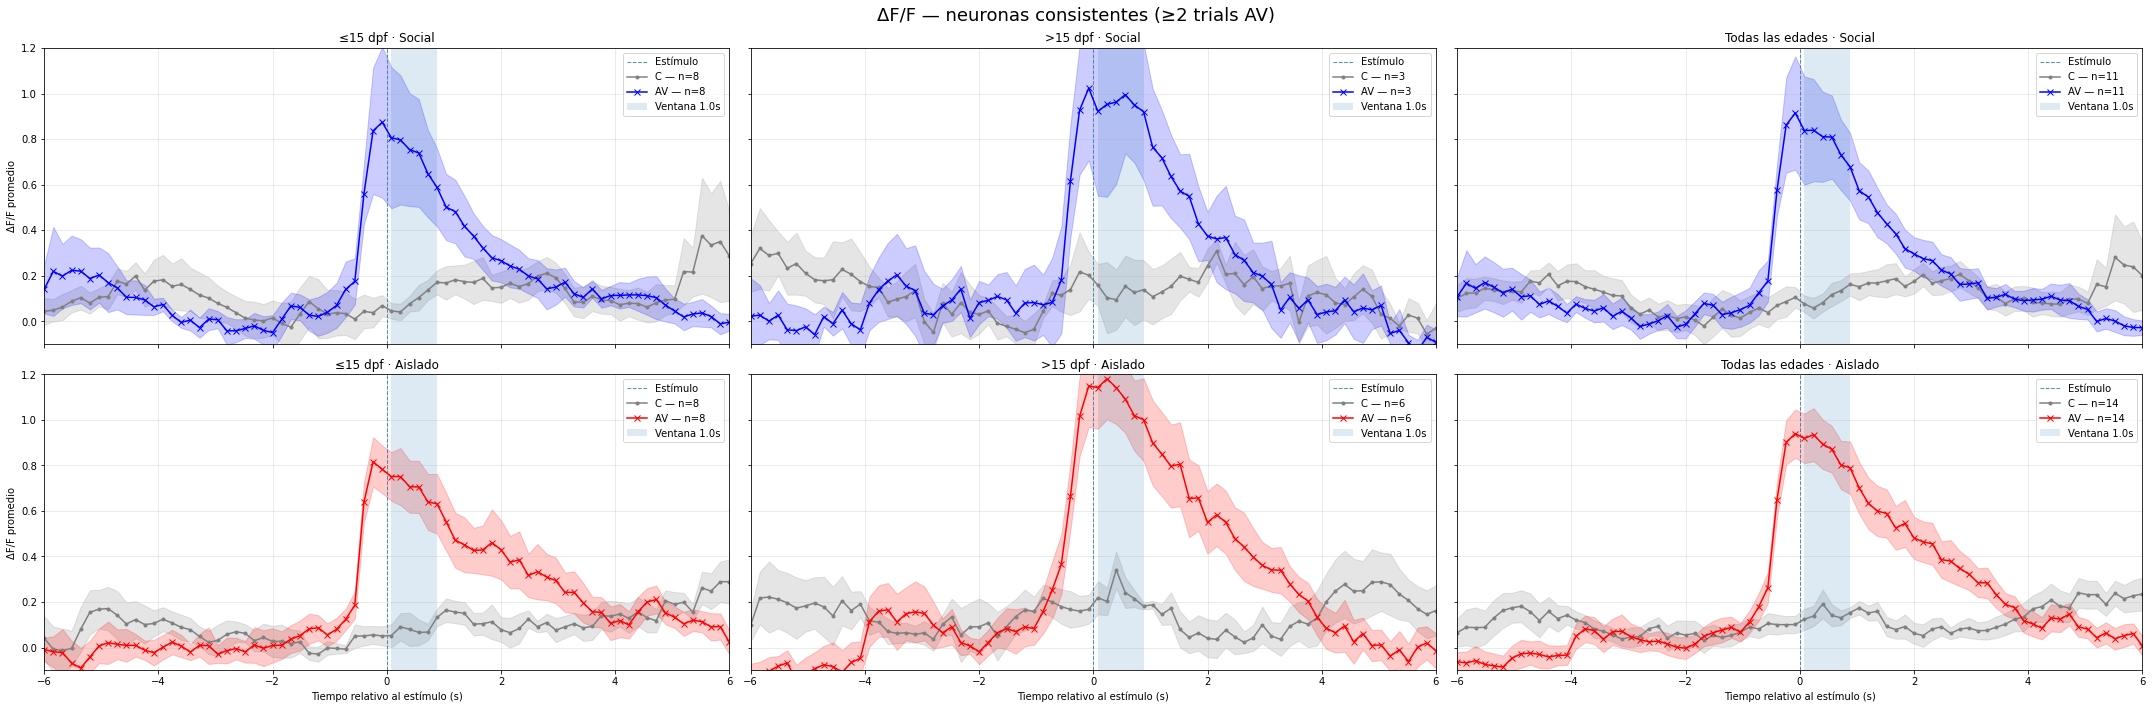

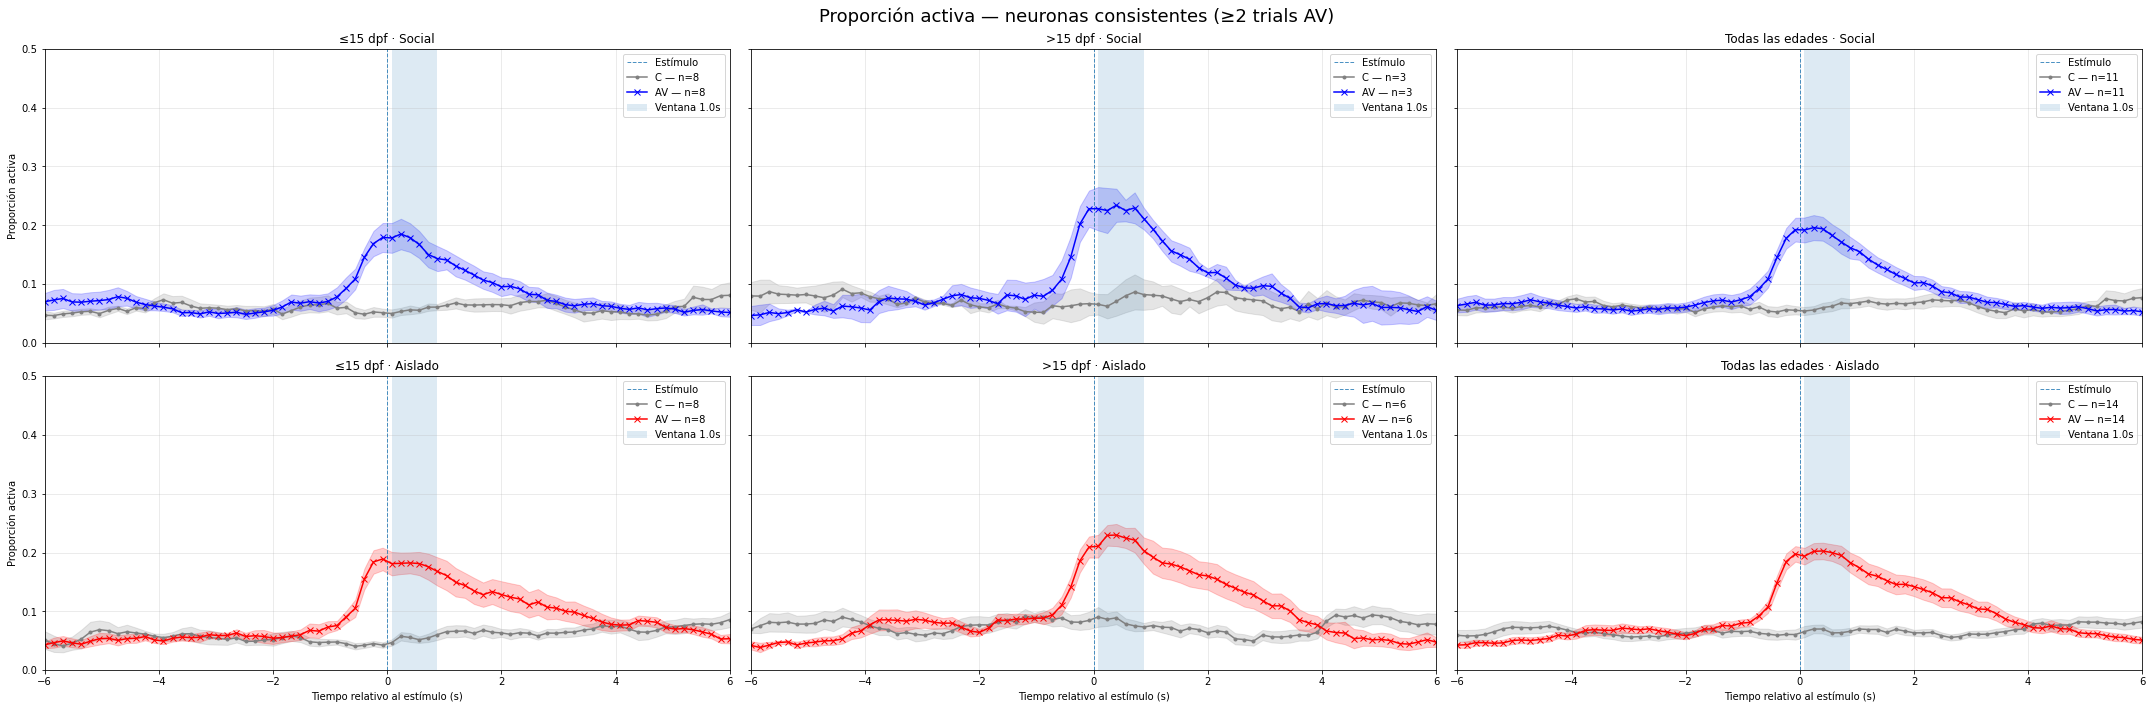

In [ ]:
# 2026 acá
# ================================================================
# NEURONAS CONSISTENTES: ΔF/F + PROPORCIÓN ACTIVA
# ================================================================

consistencia_repeticion = 2

grupos = {
    "≤15 dpf": lambda e: e <= 15,
    ">15 dpf": lambda e: e > 15,
    "Todas las edades": lambda e: True
}

sociales = {"Social": 0, "Aislado": 1}

# resultados[grupo][social][C/AV]
def _estructura():
    return {
        g: {s: {c: {"animals": [], "t": None} for c in ["C", "AV"]}
            for s in sociales}
        for g in grupos
    }

resultados_dff = _estructura()
resultados_prop = _estructura()

# ================================================================
# PROCESAMIENTO
# ================================================================

for fish_id, area in areas.items():
    edad = getattr(area, "edad", -999)
    aislado = getattr(area, "aislado", None)

    if aislado not in [0, 1]:
        continue

    social = "Social" if aislado == 0 else "Aislado"
    grupos_animal = [g for g, pred in grupos.items() if pred(edad)]

    # ------------------------------------------------------------
    # 1. Encontrar neuronas consistentes usando trials AV
    # ------------------------------------------------------------

    n_respuestas = None

    for tr in getattr(area, "trials_rea", []):
        if _get_condition(tr) != "AV":
            continue

        rb = getattr(tr, "roi_binaries_rea", None)
        if rb is None or region_key not in rb:
            continue

        B = (np.asarray(rb[region_key]) > 0).astype(int)
        t, tr_fps = _trial_timebase(tr, fps)

        stim_frame = int(round(stim_s * tr_fps))
        win_idx = np.arange(stim_frame - frames_pre,
                            stim_frame + frames_post + 1)
        win_idx = win_idx[(win_idx >= 0) & (win_idx < B.shape[1])]

        resp = B[:, win_idx].sum(axis=1) > 0

        if n_respuestas is None:
            n_respuestas = resp.astype(int)
        else:
            n_respuestas += resp.astype(int)

    if n_respuestas is None:
        continue

    active_mask = n_respuestas >= consistencia_repeticion

    if not active_mask.any():
        continue

    # ------------------------------------------------------------
    # 2. Extraer ΔF/F Y binarios de esas mismas neuronas
    # ------------------------------------------------------------

    per_trial_dff = {"C": [], "AV": []}
    per_trial_prop = {"C": [], "AV": []}
    per_time = {"C": [], "AV": []}

    for tr in getattr(area, "trials_rea", []):
        cond = _get_condition(tr)

        rb = getattr(tr, "roi_binaries_rea", None)
        dff = getattr(tr, "roi_dffs", None)

        if rb is None or region_key not in rb:
            continue
        if dff is None or region_key not in dff:
            continue

        B = (np.asarray(rb[region_key]) > 0).astype(float)
        D = np.asarray(dff[region_key])

        if B.ndim != 2 or D.ndim != 2:
            continue
        if len(active_mask) != B.shape[0] or len(active_mask) != D.shape[0]:
            continue

        B_sel = B[active_mask, :]
        D_sel = D[active_mask, :]

        if B_sel.shape[0] == 0:
            continue

        t, tr_fps = _trial_timebase(tr, fps)
        m = min(len(t), B_sel.shape[1], D_sel.shape[1])

        # ΔF/F promedio de neuronas consistentes
        per_trial_dff[cond].append(D_sel[:, :m].mean(axis=0))

        # Proporción activa ENTRE neuronas consistentes
        per_trial_prop[cond].append(B_sel[:, :m].mean(axis=0))

        per_time[cond].append(t[:m])

    # ------------------------------------------------------------
    # 3. Promedio de trials dentro de cada animal
    # ------------------------------------------------------------

    for cond in ["C", "AV"]:
        if not per_trial_dff[cond]:
            continue

        dff_series, m1 = _truncate_to_common_length(per_trial_dff[cond])
        prop_series, m2 = _truncate_to_common_length(per_trial_prop[cond])
        time_series, mt = _truncate_to_common_length(per_time[cond])

        m = min(m1, m2, mt)
        if m == 0:
            continue

        animal_dff = np.vstack([x[:m] for x in dff_series]).mean(axis=0)
        animal_prop = np.vstack([x[:m] for x in prop_series]).mean(axis=0)
        t_common = time_series[0][:m]

        for g in grupos_animal:
            resultados_dff[g][social][cond]["animals"].append(animal_dff)
            resultados_prop[g][social][cond]["animals"].append(animal_prop)

            if resultados_dff[g][social][cond]["t"] is None:
                resultados_dff[g][social][cond]["t"] = t_common
            if resultados_prop[g][social][cond]["t"] is None:
                resultados_prop[g][social][cond]["t"] = t_common


# ================================================================
# FUNCIÓN PARA HACER LAS FIGURAS 2 × 3
# ================================================================

def plot_consistentes(resultados, ylabel, ylim, titulo):
    fig, axes = plt.subplots(2, 3, figsize=(30, 10),
                             sharex=True, sharey=True)

    for col, gname in enumerate(grupos):
        for row, social in enumerate(["Social", "Aislado"]):
            ax = axes[row, col]
            data = resultados[gname][social]

            mean_C, sem_C = _mean_sem_over_animals(data["C"]["animals"])
            mean_AV, sem_AV = _mean_sem_over_animals(data["AV"]["animals"])

            if mean_AV is not None:
                t = data["AV"]["t"][:len(mean_AV)] - stim_s
            elif mean_C is not None:
                t = data["C"]["t"][:len(mean_C)] - stim_s
            else:
                ax.set_title(f"{gname} · {social}\nSin datos")
                continue

            color_AV = "blue" if social == "Social" else "red"

            # Estímulo y ventana post
            ax.axvline(0, linestyle="--", linewidth=1,
                       alpha=.8, label="Estímulo")

            w = (t >= 0) & (t < win_s)
            if w.any():
                ax.axvspan(t[w][0], t[w][-1], alpha=.15,
                           label=f"Ventana {win_s:.1f}s")

            # Control
            if mean_C is not None:
                m = min(len(t), len(mean_C))
                ax.plot(t[:m], mean_C[:m], color="gray", marker=".",
                        label=f"C — n={len(data['C']['animals'])}")

                if sem_C is not None:
                    ax.fill_between(
                        t[:m],
                        mean_C[:m] - sem_C[:m],
                        mean_C[:m] + sem_C[:m],
                        color="gray", alpha=.2
                    )

            # AV
            if mean_AV is not None:
                m = min(len(t), len(mean_AV))
                ax.plot(t[:m], mean_AV[:m], color=color_AV, marker="x",
                        label=f"AV — n={len(data['AV']['animals'])}")

                if sem_AV is not None:
                    ax.fill_between(
                        t[:m],
                        mean_AV[:m] - sem_AV[:m],
                        mean_AV[:m] + sem_AV[:m],
                        color=color_AV, alpha=.2
                    )

            ax.set_title(f"{gname} · {social}")
            ax.set_xlim(-6, 6)
            ax.set_ylim(*ylim)
            ax.grid(alpha=.3)
            ax.legend()

            if row == 1:
                ax.set_xlabel("Tiempo relativo al estímulo (s)")
            if col == 0:
                ax.set_ylabel(ylabel)

    fig.suptitle(titulo, fontsize=18)
    fig.patch.set_facecolor("white")
    plt.tight_layout()
    plt.show()


# ================================================================
# FIGURA 1: ΔF/F DE NEURONAS CONSISTENTES
# ================================================================

plot_consistentes(
    resultados_dff,
    ylabel="ΔF/F promedio",
    ylim=(-.1, 1.2),
    titulo=f"ΔF/F — neuronas consistentes (≥{consistencia_repeticion} trials AV)"
)


# ================================================================
# FIGURA 2: PROPORCIÓN ACTIVA DE NEURONAS CONSISTENTES
# ================================================================

plot_consistentes(
    resultados_prop,
    ylabel="Proporción activa",
    ylim=(0, 0.5),
    titulo=f"Proporción activa — neuronas consistentes (≥{consistencia_repeticion} trials AV)"
)

In [715]:
# ================================================================
# Average ΔF/F timecourse (using consistent neurons, ≥2 trials)
# ================================================================

consistency_repetition = 2
only_social = True   # True = social fish, False = isolated

# ----- Colors and markers -----
colors = {
    "G1 (6–8 dpf)":     "#4D76C4",   # dark gray/blue
    "G2 (12–13 dpf)":   "#385696",   # blue
    "G3 (15–16 dpf)":   "#27278B",   # navy
    "G2 isolated":      "#d62728",   # red
}
markers = {
    "G1 (6–8 dpf)":   ".",
    "G2 (12–13 dpf)": ".",
    "G3 (15–16 dpf)": ".",
    "G2 isolated":    "x",   # <- requested
}

# Dictionary for results
dff_results = {g: {"C": {"animals": [], "t": None}, 
                   "AV": {"animals": [], "t": None}}
               for g in grupos.keys()}

# ================================================================
# (processing loop omitted for brevity, igual que tu código arriba)
# ================================================================

# Diccionario para guardar resultados
resultados_dff = {g: {"C": {"animals": [], "t": None}, 
                      "AV": {"animals": [], "t": None}}
                  for g in grupos.keys()}

for fish_id, area in areas.items():
    edad = getattr(area, "edad", -999)
    aislado = getattr(area, "aislado", 1)

    # Filtrar por condición social/aislado
    if solo_social and aislado != 0:
        continue
    if not solo_social and aislado != 1:
        continue

    # Asignar grupo
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue

    # --- Paso 1: encontrar neuronas consistentes (en trials AV)
    Nh = None
    Nh_plus_mask = None
    for tr in getattr(area, "trials_rea", []):
        cond = _get_condition(tr)
        if cond != "AV":
            continue
        rb = getattr(tr, "roi_binaries_rea2", None)
        if rb is None or region_key not in rb:
            continue
        B = np.asarray(rb[region_key])
        B = (B > 0).astype(int)
        Nh = B.shape[0]

        t, tr_fps = _trial_timebase(tr, fps)
        stim_frame = int(round(stim_s * tr_fps))
        win_idx = np.arange(stim_frame-frames_pre, stim_frame+frames_post+1)
        win_idx = win_idx[(win_idx >= 0) & (win_idx < B.shape[1])]

        resp = B[:, win_idx].sum(axis=1) > 0
        if Nh_plus_mask is None:
            Nh_plus_mask = resp.astype(int)
        else:
            Nh_plus_mask += resp.astype(int)

    if Nh is None or Nh_plus_mask is None:
        continue
    active_mask = Nh_plus_mask >= consistencia_repeticion
    if not active_mask.any():
        continue

    # --- Paso 2: extraer ΔF/F y calcular promedio por trial
    per_trial = {"C": [], "AV": []}
    per_time  = {"C": [], "AV": []}

    for tr in getattr(area, "trials_rea", []):
        cond = _get_condition(tr)
        rb_dff = getattr(tr, "roi_dffs", None)
        if rb_dff is None or region_key not in rb_dff:
            continue
        D = np.asarray(rb_dff[region_key])
        if D.ndim != 2:
            continue
        D_sel = D[active_mask, :]
        if D_sel.shape[0] == 0:
            continue

        t, tr_fps = _trial_timebase(tr, fps)
        m = min(len(t), D_sel.shape[1])
        per_trial[cond].append(D_sel[:, :m].mean(axis=0))
        per_time[cond].append(t[:m])

    # --- Paso 3: promedio por animal
    for cond in ["C", "AV"]:
        if len(per_trial[cond]) == 0:
            continue
        series, m = _truncate_to_common_length(per_trial[cond])
        if m == 0:
            continue
        tseries, _ = _truncate_to_common_length(per_time[cond])
        t_common = tseries[0] if len(tseries) > 0 else np.arange(m)/tr_fps
        animal_mean = np.vstack(series).mean(axis=0)

        resultados_dff[gname][cond]["animals"].append(animal_mean)
        if resultados_dff[gname][cond]["t"] is None:
            resultados_dff[gname][cond]["t"] = t_common
# ================================================================
# Plot average ΔF/F per group
# ================================================================
for gname in grupos.keys():
    data = dff_results[gname]
    mean_C, sem_C   = _mean_sem_over_animals(data["C"]["animals"])
    mean_AV, sem_AV = _mean_sem_over_animals(data["AV"]["animals"])

    if mean_AV is not None:
        t_plot = data["AV"]["t"][:len(mean_AV)] - stim_s
    elif mean_C is not None:
        t_plot = data["C"]["t"][:len(mean_C)] - stim_s
    else:
        continue

    fig = plt.figure(figsize=(10,5))
    plt.axvline(0, linestyle="--", linewidth=1, alpha=0.8, label="Stimulus")

    # Control condition
    if mean_C is not None:
        plt.plot(t_plot, mean_C,
                 label=f"C — n={len(data['C']['animals'])}", 
                 color="gray", marker=".")
        if sem_C is not None:
            plt.fill_between(t_plot, mean_C-sem_C, mean_C+sem_C,
                             alpha=0.2, color="gray")

    # Audiovisual condition
    if mean_AV is not None:
        label_text = f"AV — n={len(data['AV']['animals'])}"
        color_use = colors[gname] if only_social else colors["G2 isolated"]
        marker_use = markers[gname] if only_social else markers["G2 isolated"]
        plt.plot(t_plot, mean_AV, label=label_text,
                 color=color_use, marker=marker_use)
        if sem_AV is not None:
            plt.fill_between(t_plot, mean_AV-sem_AV, mean_AV+sem_AV,
                             alpha=0.2, color=color_use)

    plt.xlabel("Time relative to stimulus (s)")
    plt.ylabel("Average ΔF/F (consistent neurons)")
    plt.ylim(-.1, 1.2)
    plt.xlim(-6, 6)
    plt.grid(alpha=0.3)

    # Manual legend (4 entries: colors + special marker for isolated G2)
    handles = [
        Line2D([0],[0], marker='.', color='none',
               markerfacecolor=colors["G1 (6–8 dpf)"], markersize=14, label="$G_1$"),
        Line2D([0],[0], marker='.', color='none',
               markerfacecolor=colors["G2 (12–13 dpf)"], markersize=14, label="$G_2^{s}$"),
        Line2D([0],[0], marker='.', color='none',
               markerfacecolor=colors["G3 (15–16 dpf)"], markersize=14, label="$G_3$"),
        Line2D([0],[0], marker='x',
               color=colors["G2 isolated"], markersize=14, label="$G_2^{a}$"),
    ]
    ax = plt.gca()
    ax.legend(handles=handles, title="Group",
              frameon=False, loc="upper right",
              fontsize=12, title_fontsize=13)

    fig.patch.set_facecolor("white")
    plt.title(f"{gname} · {'Social' if only_social else 'Isolated'}")
    plt.tight_layout()
    plt.show()


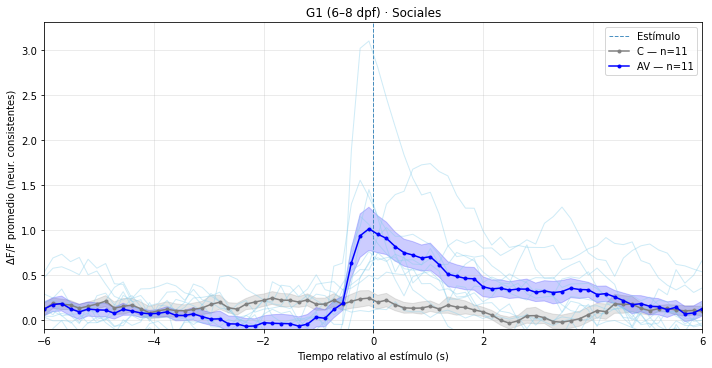

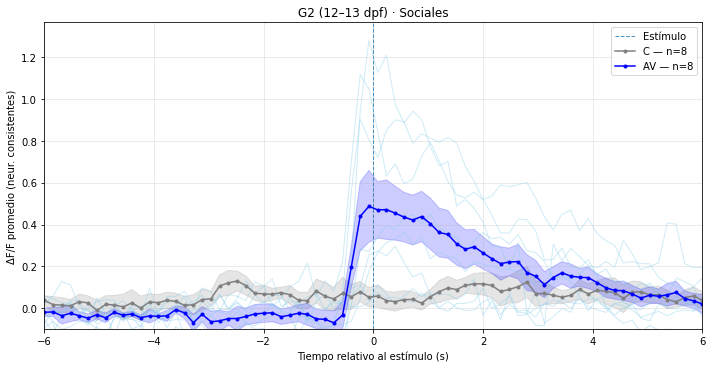

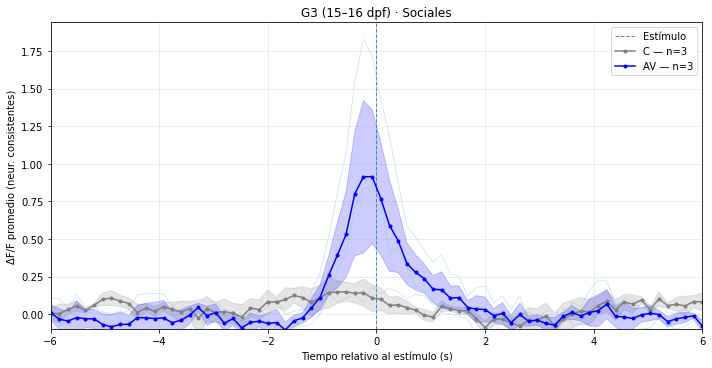

In [543]:
# ================================================================
# Graficar ΔF/F promedio por grupo + curvas por animal
# ================================================================
for gname in grupos.keys():
    data = resultados_dff[gname]
    mean_C, sem_C   = _mean_sem_over_animals(data["C"]["animals"])
    mean_AV, sem_AV = _mean_sem_over_animals(data["AV"]["animals"])

    if mean_AV is not None:
        t_plot = data["AV"]["t"][:len(mean_AV)] - stim_s
    elif mean_C is not None:
        t_plot = data["C"]["t"][:len(mean_C)] - stim_s
    else:
        continue

    fig = plt.figure(figsize=(10,5))
    plt.axvline(0, linestyle="--", linewidth=1, alpha=0.8, label="Estímulo")

    # --- Curvas individuales por animal (ΔF/F promedio de 5 trials)
    if len(data["AV"]["animals"]) > 0:
        for animal_curve in data["AV"]["animals"]:
            m = min(len(t_plot), len(animal_curve))
            plt.plot(t_plot[:m], animal_curve[:m], 
                     color="skyblue", alpha=0.4, linewidth=1, label=None)

    # Control
    if mean_C is not None:
        plt.plot(t_plot, mean_C, label=f"C — n={len(data['C']['animals'])}", 
                 color=color_C, marker=".")
        if sem_C is not None:
            plt.fill_between(t_plot, mean_C-sem_C, mean_C+sem_C, alpha=0.2, color=color_C)

     # Audiovisual
    if mean_AV is not None:
         plt.plot(t_plot, mean_AV, 
                  label=f"AV — n={len(data['AV']['animals'])}", 
                  color=color_AV, marker=("." if solo_social else "x"))
         if sem_AV is not None:
             plt.fill_between(t_plot, mean_AV-sem_AV, mean_AV+sem_AV, alpha=0.2, color=color_AV)

    # --- Estética
    plt.xlabel("Tiempo relativo al estímulo (s)")
    plt.ylabel("ΔF/F promedio (neur. consistentes)")
    plt.ylim(-.1, None)
    plt.xlim(-6, 6)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    fig.patch.set_facecolor("white")

    plt.title(f"{gname} · {'Sociales' if solo_social else 'Aislados'}")
    plt.show()


In [77]:
# ------------------------------------------------
# Detectar peces que quedaron excluidos (sin neuronas consistentes)
# ------------------------------------------------
excluded_fish = []

for fish_id, area in areas.items():
    edad = getattr(area, "edad", -999)
    aislado = getattr(area, "aislado", 1)

    # Filtrar por condición social/aislado
    if solo_social and aislado != 0:
        continue
    if not solo_social and aislado != 1:
        continue

    # Asignar grupo
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue

    # --- Paso 1: encontrar neuronas consistentes (en trials AV)
    Nh = None
    Nh_plus_mask = None
    for tr in getattr(area, "trials_rea", []):
        cond = _get_condition(tr)
        if cond != "AV":
            continue
        rb = getattr(tr, "roi_binaries_rea2", None)
        if rb is None or region_key not in rb:
            continue
        B = np.asarray(rb[region_key])
        B = (B > 0).astype(int)
        Nh = B.shape[0]

        t, tr_fps = _trial_timebase(tr, fps)
        stim_frame = int(round(stim_s * tr_fps))
        win_idx = np.arange(stim_frame-frames_pre, stim_frame+frames_post+1)
        win_idx = win_idx[(win_idx >= 0) & (win_idx < B.shape[1])]

        resp = B[:, win_idx].sum(axis=1) > 0
        if Nh_plus_mask is None:
            Nh_plus_mask = resp.astype(int)
        else:
            Nh_plus_mask += resp.astype(int)

    if Nh is None or Nh_plus_mask is None:
        continue
    active_mask = Nh_plus_mask >= consistencia_repeticion

    # Si ninguna neurona pasa el filtro → excluido
    if not active_mask.any():
        excluded_fish.append((fish_id, gname))

# Mostrar resultado
if excluded_fish:
    print("⚠️ Peces sin neuronas consistentes (excluidos):")
    for fish_id, gname in excluded_fish:
        print(f"  - {fish_id} ({gname})")
else:
    print("✅ Todos los peces incluidos tienen al menos una neurona consistente.")


✅ Todos los peces incluidos tienen al menos una neurona consistente.


In [539]:
from scipy.integrate import trapz

# Diccionario para guardar resultados de AUC
auc_results = {}

for gname in grupos.keys():
    data = resultados_dff[gname]  # usamos las curvas de ΔF/F ya calculadas
    mean_AV, _ = _mean_sem_over_animals(data["AV"]["animals"])

    if mean_AV is None:
        continue

    t_plot = data["AV"]["t"][:len(mean_AV)] - stim_s

    # --- Paso 1: restringir a la ventana de análisis
    mask_win = (t_plot >= -frames_pre/float(fps)) & (t_plot <= frames_post/float(fps))
    t_win = t_plot[mask_win]
    y_win = mean_AV[mask_win]

    if len(y_win) == 0:
        continue

    # --- Paso 2: buscar el pico dentro de la ventana
    idx_peak = np.argmax(y_win)
    peak_val = y_win[idx_peak]
    peak_t   = t_win[idx_peak]

    if peak_val <= 0:
        continue

    # --- Paso 3: buscar puntos de cruce a mitad de altura
    y_half = peak_val / 2.0

    # izquierda
    idx_left = idx_peak
    while idx_left > 0 and y_win[idx_left] > y_half:
        idx_left -= 1

    # derecha
    idx_right = idx_peak
    while idx_right < len(y_win)-1 and y_win[idx_right] > y_half:
        idx_right += 1

    # aseguramos que tengamos al menos 2 puntos
    if idx_left == idx_right:
        continue

    t_segment = t_win[idx_left:idx_right+1]
    y_segment = y_win[idx_left:idx_right+1]

    # --- Paso 4: integrar con regla del trapecio
    auc_val = trapz(y_segment, t_segment)

    # Guardar en resultados
    auc_results[gname] = {
        "AUC": auc_val,
        "peak_t": peak_t,
        "peak_val": peak_val,
        "t_left": t_win[idx_left],
        "t_right": t_win[idx_right]
    }

# Mostrar resultados
for g, res in auc_results.items():
    print(f"{g}: AUC={res['AUC']:.4f}, pico={res['peak_val']:.3f} en {res['peak_t']:.2f}s, "
          f"ancho={res['t_right']-res['t_left']:.2f}s")


G1 (6–8 dpf): AUC=1.0850, pico=1.016 en -0.08s, ancho=1.28s
G2 (12–13 dpf): AUC=0.5594, pico=0.487 en -0.08s, ancho=1.28s
G3 (15–16 dpf): AUC=0.6792, pico=0.915 en -0.08s, ancho=0.96s


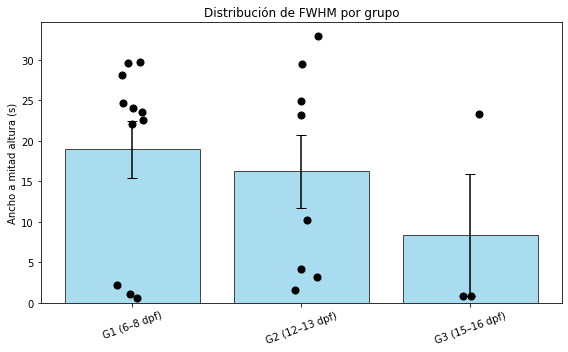

In [101]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Barplot con SEM + puntos individuales
# ============================================================
fig, ax = plt.subplots(figsize=(8,5))

# Extraer posiciones
grupos = summary["grupo"].tolist()
x = np.arange(len(grupos))

# Barras con SEM
ax.bar(
    x,
    summary["mean_fwhm"],
    yerr=summary["sem_fwhm"],
    color="skyblue",
    edgecolor="black",
    capsize=5,
    alpha=0.7
)

# Agregar puntos individuales
for i, g in enumerate(grupos):
    y_vals = df_metrics.loc[df_metrics["grupo"]==g, "fwhm"]
    jitter = (np.random.rand(len(y_vals)) - 0.5) * 0.2  # dispersión horizontal
    ax.scatter(
        np.full(len(y_vals), x[i]) + jitter,
        y_vals,
        color="black",
        s=50,
        zorder=3
    )

ax.set_xticks(x)
ax.set_xticklabels(grupos, rotation=20)
ax.set_ylabel("Ancho a mitad altura (s)")
ax.set_title("Distribución de FWHM por grupo")

plt.tight_layout()
plt.show()


In [142]:
grupos = {
    "G1 (6–8 dpf)":   lambda e: 6 <= e <= 8,
    "G2 (12–13 dpf)": lambda e: 12 <= e <= 13,
    "G3 (15–16 dpf)": lambda e: 15 <= e <= 16,
}


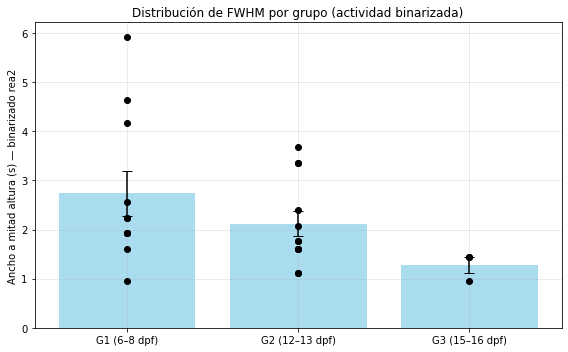

In [585]:
# ================================================================
# Calcular FWHM usando actividad binarizada rea2
# ================================================================

consistencia_repeticion = 2  # neuronas consistentes en ≥ trials
region_key = "Hb"

def calcular_fwhm_binarias(area, consistencia_repeticion=2):
    """Devuelve el FWHM de la curva binarizada promedio para un pez."""
    Nh = None
    Nh_plus_mask = None

    # Paso 1: encontrar neuronas consistentes (AV)
    for tr in getattr(area, "trials_rea", []):
        cond = _get_condition(tr)
        if cond != "AV":
            continue
        rb = getattr(tr, "roi_binaries_rea2", None)
        if rb is None or region_key not in rb:
            continue
        B = np.asarray(rb[region_key])
        B = (B > 0).astype(int)
        Nh = B.shape[0]

        t, tr_fps = _trial_timebase(tr, fps)
        stim_frame = int(round(stim_s * tr_fps))
        win_idx = np.arange(stim_frame-frames_pre, stim_frame+frames_post+1)
        win_idx = win_idx[(win_idx >= 0) & (win_idx < B.shape[1])]

        resp = B[:, win_idx].sum(axis=1) > 0
        if Nh_plus_mask is None:
            Nh_plus_mask = resp.astype(int)
        else:
            Nh_plus_mask += resp.astype(int)

    if Nh is None or Nh_plus_mask is None:
        return None
    active_mask = Nh_plus_mask >= consistencia_repeticion
    if not active_mask.any():
        return None

    # Paso 2: construir curvas trial → promedio animal
    per_trial = []
    per_time = []
    for tr in getattr(area, "trials_rea", []):
        cond = _get_condition(tr)
        if cond != "AV":
            continue
        rb = getattr(tr, "roi_binaries_rea2", None)
        if rb is None or region_key not in rb:
            continue
        B = np.asarray(rb[region_key])
        B = (B > 0).astype(int)
        B_sel = B[active_mask, :]
        if B_sel.shape[0] == 0:
            continue

        t, tr_fps = _trial_timebase(tr, fps)
        m = min(len(t), B_sel.shape[1])
        per_trial.append(B_sel[:, :m].mean(axis=0))
        per_time.append(t[:m])

    if len(per_trial) == 0:
        return None
    series, m = _truncate_to_common_length(per_trial)
    tseries, _ = _truncate_to_common_length(per_time)
    t_common = tseries[0] if len(tseries) > 0 else np.arange(m)/tr_fps
    curve = np.vstack(series).mean(axis=0)

    # Paso 3: calcular FWHM
    stim_idx = np.argmin(np.abs(t_common - stim_s))
    peak_idx = stim_idx + np.argmax(curve[stim_idx: stim_idx+frames_post])
    peak_val = curve[peak_idx]
    half = peak_val / 2

    left = np.where(curve[:peak_idx] <= half)[0]
    left_idx = left[-1] if len(left) > 0 else 0
    right = np.where(curve[peak_idx:] <= half)[0]
    right_idx = peak_idx + (right[0] if len(right) > 0 else len(curve)-1)
    fwhm = t_common[right_idx] - t_common[left_idx]

    return fwhm


# ================================================================
# Loop por peces y agrupar resultados
# ================================================================
rows = []
for fish_id, area in areas.items():
    edad = getattr(area, "edad", -999)
    aislado = getattr(area, "aislado", 1)

    # Asignar grupo
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue

    fwhm_val = calcular_fwhm_binarias(area, consistencia_repeticion)
    if fwhm_val is None:
        continue

    rows.append({"fish_id": fish_id, "grupo": gname, "fwhm": fwhm_val})

df_fwhm_bin = pd.DataFrame(rows)

# ================================================================
# Graficar barras + puntos individuales
# ================================================================
summary = (df_fwhm_bin
           .groupby("grupo")
           .agg(mean_fwhm=("fwhm", "mean"),
                sem_fwhm=("fwhm", lambda x: x.std(ddof=1)/np.sqrt(len(x))))
           .reset_index())

fig, ax = plt.subplots(figsize=(8,5))
x = np.arange(len(summary))
ax.bar(x, summary["mean_fwhm"], yerr=summary["sem_fwhm"],
       color="skyblue", alpha=0.7, capsize=5)

# puntos individuales
for i, g in enumerate(summary["grupo"]):
    yvals = df_fwhm_bin.loc[df_fwhm_bin["grupo"]==g, "fwhm"]
    ax.scatter(np.full_like(yvals, i, dtype=float), yvals,
               color="black", zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(summary["grupo"])
ax.set_ylabel("Ancho a mitad altura (s) — binarizado rea2")
ax.set_title("Distribución de FWHM por grupo (actividad binarizada)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


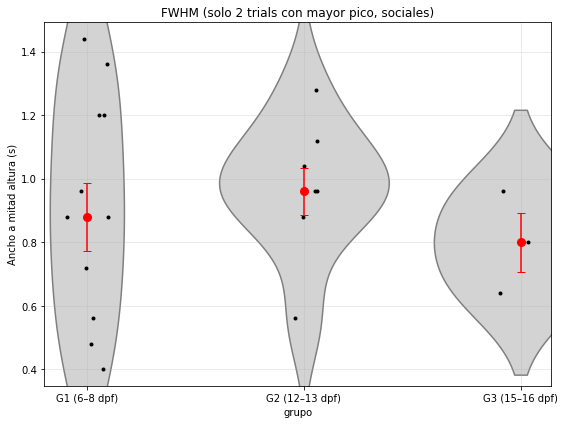

In [586]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ================================================================
# Función para calcular pico y FWHM en un trial
# ================================================================
def calc_peak_fwhm(trace, t, stim_frame, frames_pre, frames_post, fps):
    """
    Calcula pico y ancho a mitad de altura (FWHM) en ventana del estímulo.
    trace: ΔF/F promedio del trial (1D array)
    t: vector de tiempos
    stim_frame: índice del frame de estímulo
    """
    win_idx = np.arange(stim_frame-frames_pre, stim_frame+frames_post+1)
    win_idx = win_idx[(win_idx >= 0) & (win_idx < len(trace))]
    if len(win_idx) == 0:
        return None, None

    y = trace[win_idx]
    peak = y.max()
    if peak <= 0:
        return peak, None

    half_height = peak / 2
    above = np.where(y >= half_height)[0]
    if len(above) < 2:
        return peak, None

    fwhm = (above[-1] - above[0]) / fps
    return peak, fwhm


# ================================================================
# Loop por peces sociales
# ================================================================
rows = []
for fish_id, area in areas.items():
    edad = getattr(area, "edad", -999)
    aislado = getattr(area, "aislado", 1)

    # Solo animales sociales
    if aislado != 0:
        continue

    # Asignar grupo etario
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue

    # --- Paso 1: identificar neuronas consistentes (≥2 trials AV)
    Nh = None
    Nh_plus_mask = None
    for tr in getattr(area, "trials_rea", []):
        cond = _get_condition(tr)
        if cond != "AV":
            continue
        rb = getattr(tr, "roi_binaries_rea2", None)
        if rb is None or region_key not in rb:
            continue
        B = np.asarray(rb[region_key])
        B = (B > 0).astype(int)
        Nh = B.shape[0]

        t, tr_fps = _trial_timebase(tr, fps)
        stim_frame = int(round(stim_s * tr_fps))
        win_idx = np.arange(stim_frame-frames_pre, stim_frame+frames_post+1)
        win_idx = win_idx[(win_idx >= 0) & (win_idx < B.shape[1])]

        resp = B[:, win_idx].sum(axis=1) > 0
        if Nh_plus_mask is None:
            Nh_plus_mask = resp.astype(int)
        else:
            Nh_plus_mask += resp.astype(int)

    if Nh is None or Nh_plus_mask is None:
        continue

    active_mask = Nh_plus_mask >= 2
    if not active_mask.any():
        continue

    # --- Paso 2: ΔF/F en trials
    trial_metrics = []
    for tr in getattr(area, "trials_rea", []):
        cond = _get_condition(tr)
        if cond != "AV":
            continue
        rb_dff = getattr(tr, "roi_dffs", None)
        if rb_dff is None or region_key not in rb_dff:
            continue
        D = np.asarray(rb_dff[region_key])
        if D.ndim != 2:
            continue
        D_sel = D[active_mask, :]
        if D_sel.shape[0] == 0:
            continue

        trace = D_sel.mean(axis=0)
        t, tr_fps = _trial_timebase(tr, fps)
        stim_frame = int(round(stim_s * tr_fps))

        peak, fwhm = calc_peak_fwhm(trace, t, stim_frame, frames_pre, frames_post, fps)
        if fwhm is not None:
            trial_metrics.append((peak, fwhm))

    # --- Paso 3: quedarnos con 2 trials de mayor pico
    if len(trial_metrics) >= 2:
        trial_metrics.sort(key=lambda x: x[0], reverse=True)  # ordenar por pico
        top2 = trial_metrics[:2]
        fwhm_mean = np.mean([f for p, f in top2])
        rows.append({
            "fish_id": fish_id,
            "grupo": gname,
            "fwhm": fwhm_mean
        })

df_fwhm = pd.DataFrame(rows)


# ================================================================
# Graficar: violin plot + puntos + mediana ± SEM
# ================================================================
fig, ax = plt.subplots(figsize=(8,6))
order = list(grupos.keys())

sns.violinplot(data=df_fwhm, x="grupo", y="fwhm", order=order,
               inner=None, color="lightgray", ax=ax, alpha=0.5)

# Puntos individuales
sns.stripplot(data=df_fwhm, x="grupo", y="fwhm", order=order,
              color="black", marker=".", size=8, ax=ax)

# Mediana ± SEM por grupo
summary = (df_fwhm.groupby("grupo")
           .agg(median_val=("fwhm", "median"),
                sem_val=("fwhm", lambda x: x.std(ddof=1)/np.sqrt(len(x))))
           .reset_index())

for i, row in summary.iterrows():
    ax.errorbar(i, row["median_val"], yerr=row["sem_val"],
                fmt="o", color="red", capsize=4, markersize=8, zorder=5)

ax.set_ylabel("Ancho a mitad altura (s)")
ax.set_title("FWHM (solo 2 trials con mayor pico, sociales)")
ax.grid(alpha=0.3)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()


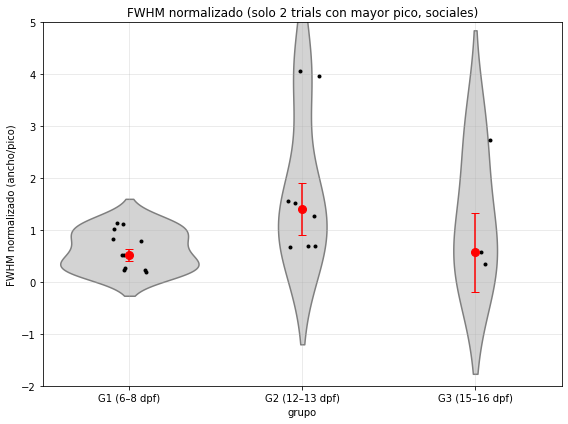

In [587]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ================================================================
# Función para calcular pico y FWHM en un trial
# ================================================================
def calc_peak_fwhm(trace, t, stim_frame, frames_pre, frames_post, fps):
    """
    Calcula pico y ancho a mitad de altura (FWHM) en ventana del estímulo.
    trace: ΔF/F promedio del trial (1D array)
    t: vector de tiempos
    stim_frame: índice del frame de estímulo
    """
    win_idx = np.arange(stim_frame-frames_pre, stim_frame+frames_post+1)
    win_idx = win_idx[(win_idx >= 0) & (win_idx < len(trace))]
    if len(win_idx) == 0:
        return None, None

    y = trace[win_idx]
    peak = y.max()
    if peak <= 0:
        return peak, None

    half_height = peak / 2
    above = np.where(y >= half_height)[0]
    if len(above) < 2:
        return peak, None

    fwhm = (above[-1] - above[0]) / fps
    return peak, fwhm


# ================================================================
# Loop por peces sociales
# ================================================================
rows = []
for fish_id, area in areas.items():
    edad = getattr(area, "edad", -999)
    aislado = getattr(area, "aislado", 1)

    # Solo animales sociales
    if aislado != 0:
        continue

    # Asignar grupo etario
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue

    # --- Paso 1: identificar neuronas consistentes (≥2 trials AV)
    Nh = None
    Nh_plus_mask = None
    for tr in getattr(area, "trials_rea", []):
        cond = _get_condition(tr)
        if cond != "AV":
            continue
        rb = getattr(tr, "roi_binaries_rea2", None)
        if rb is None or region_key not in rb:
            continue
        B = np.asarray(rb[region_key])
        B = (B > 0).astype(int)
        Nh = B.shape[0]

        t, tr_fps = _trial_timebase(tr, fps)
        stim_frame = int(round(stim_s * tr_fps))
        win_idx = np.arange(stim_frame-frames_pre, stim_frame+frames_post+1)
        win_idx = win_idx[(win_idx >= 0) & (win_idx < B.shape[1])]

        resp = B[:, win_idx].sum(axis=1) > 0
        if Nh_plus_mask is None:
            Nh_plus_mask = resp.astype(int)
        else:
            Nh_plus_mask += resp.astype(int)

    if Nh is None or Nh_plus_mask is None:
        continue

    active_mask = Nh_plus_mask >= 2
    if not active_mask.any():
        continue

    # --- Paso 2: ΔF/F en trials
    trial_metrics = []
    for tr in getattr(area, "trials_rea", []):
        cond = _get_condition(tr)
        if cond != "AV":
            continue
        rb_dff = getattr(tr, "roi_dffs", None)
        if rb_dff is None or region_key not in rb_dff:
            continue
        D = np.asarray(rb_dff[region_key])
        if D.ndim != 2:
            continue
        D_sel = D[active_mask, :]
        if D_sel.shape[0] == 0:
            continue

        trace = D_sel.mean(axis=0)
        t, tr_fps = _trial_timebase(tr, fps)
        stim_frame = int(round(stim_s * tr_fps))

        peak, fwhm = calc_peak_fwhm(trace, t, stim_frame, frames_pre, frames_post, fps)
        if fwhm is not None and peak is not None and peak > 0:
            trial_metrics.append((peak, fwhm))

    # --- Paso 3: quedarnos con 2 trials de mayor pico
    if len(trial_metrics) >= 2:
        trial_metrics.sort(key=lambda x: x[0], reverse=True)  # ordenar por pico
        top2 = trial_metrics[:2]
        norm_vals = [f/p for p, f in top2 if p > 0]
        if len(norm_vals) > 0:
            fwhm_norm = np.mean(norm_vals)
            rows.append({
                "fish_id": fish_id,
                "grupo": gname,
                "fwhm_norm": fwhm_norm
            })

df_fwhm_norm = pd.DataFrame(rows)


# ================================================================
# Graficar: violin plot + puntos + mediana ± SEM
# ================================================================
fig, ax = plt.subplots(figsize=(8,6))
order = list(grupos.keys())

sns.violinplot(data=df_fwhm_norm, x="grupo", y="fwhm_norm", order=order,
               inner=None, color="lightgray", ax=ax, alpha=0.5)

# Puntos individuales
sns.stripplot(data=df_fwhm_norm, x="grupo", y="fwhm_norm", order=order,
              color="black", marker=".", size=8, ax=ax)

# Mediana ± SEM por grupo
summary = (df_fwhm_norm.groupby("grupo")
           .agg(median_val=("fwhm_norm", "median"),
                sem_val=("fwhm_norm", lambda x: x.std(ddof=1)/np.sqrt(len(x))))
           .reset_index())

for i, row in summary.iterrows():
    ax.errorbar(i, row["median_val"], yerr=row["sem_val"],
                fmt="o", color="red", capsize=4, markersize=8, zorder=5)

ax.set_ylabel("FWHM normalizado (ancho/pico)")
ax.set_title("FWHM normalizado (solo 2 trials con mayor pico, sociales)")
ax.grid(alpha=0.3)
fig.patch.set_facecolor("white")
plt.ylim(-2, 5)
plt.xlim(-.5,2.5)
plt.tight_layout()
plt.show()


                 Generalized Linear Model Regression Results                  
Dep. Variable:              fwhm_norm   No. Observations:                   22
Model:                            GLM   Df Residuals:                       19
Model Family:                Gaussian   Df Model:                            2
Link Function:               identity   Scale:                         0.99412
Method:                          IRLS   Log-Likelihood:                -29.539
Date:                Thu, 02 Oct 2025   Deviance:                       18.888
Time:                        08:22:12   Pearson chi2:                     18.9
No. Iterations:                     3   Pseudo R-squ. (CS):             0.2632
Covariance Type:            nonrobust                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

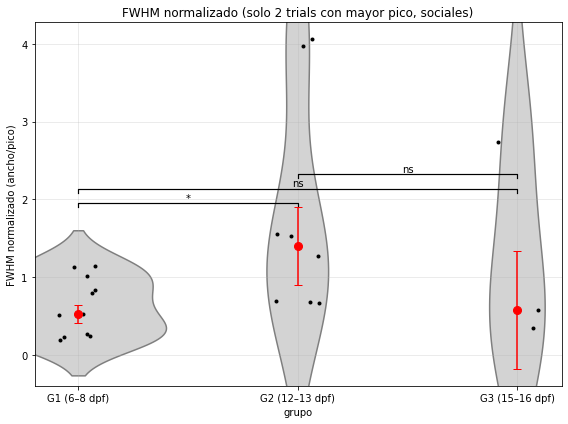

In [588]:
import statsmodels.formula.api as smf
import itertools

# ================================================================
# Función para agregar barras de significancia
# ================================================================
def add_significance(ax, x1, x2, y, pval, h=0.05, col="black"):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, c=col)
    if pval < 0.001: text = "***"
    elif pval < 0.01: text = "**"
    elif pval < 0.05: text = "*"
    else: text = "ns"
    ax.text((x1+x2)*.5, y+h, text, ha="center", va="bottom", color=col)


# ================================================================
# GLM + gráfico con violin, puntos y barras de significancia
# ================================================================
def plot_fwhm_norm_glm(df):
    order = list(grupos.keys())

    # Violin plot base
    fig, ax = plt.subplots(figsize=(8,6))
    sns.violinplot(data=df, x="grupo", y="fwhm_norm", order=order,
                   inner=None, color="lightgray", ax=ax, alpha=0.5)

    # Puntos individuales
    sns.stripplot(data=df, x="grupo", y="fwhm_norm", order=order,
                  color="black", marker=".", size=8, ax=ax)

    # Mediana ± SEM
    summary = (df.groupby("grupo")
               .agg(median_val=("fwhm_norm", "median"),
                    sem_val=("fwhm_norm", lambda x: x.std(ddof=1)/np.sqrt(len(x))))
               .reset_index())

    for i, row in summary.iterrows():
        ax.errorbar(i, row["median_val"], yerr=row["sem_val"],
                    fmt="o", color="red", capsize=4, markersize=8, zorder=5)

    ax.set_ylabel("FWHM normalizado (ancho/pico)")
    ax.set_title("FWHM normalizado (solo 2 trials con mayor pico, sociales)")
    ax.grid(alpha=0.3)
    fig.patch.set_facecolor("white")

    # ============================================================
    # GLM
    # ============================================================
    model = smf.glm("fwhm_norm ~ C(grupo)", data=df).fit()
    print(model.summary())

    # Comparaciones par a par
    grupos_list = summary["grupo"].tolist()
    ymax = (summary["median_val"]+summary["sem_val"]).max()
    h = ymax * 0.1

    for j, (g1, g2) in enumerate(itertools.combinations(grupos_list, 2)):
        # contraste entre g1 y g2
        contrast_vec = []
        for param in model.params.index:
            if param == "Intercept":
                contrast_vec.append(0)
            elif f"C(grupo)[T.{g1}]" in param:
                contrast_vec.append(1)
            elif f"C(grupo)[T.{g2}]" in param:
                contrast_vec.append(-1)
            else:
                contrast_vec.append(0)

        contrast = model.t_test(contrast_vec)
        pval = float(contrast.pvalue)
        add_significance(ax, grupos_list.index(g1), grupos_list.index(g2), ymax+h*j, pval)

    plt.tight_layout()
    plt.show()


# ================================================================
# Ejecutar
# ================================================================
plot_fwhm_norm_glm(df_fwhm_norm)


            grupo  mean_peak  sem_peak  mean_fwhm  sem_fwhm
0    G1 (6–8 dpf)   1.765905  0.205769   2.385455  0.250165
1  G2 (12–13 dpf)   0.736487  0.209760   2.060000  0.337300
2  G3 (15–16 dpf)   1.068999  0.388769   1.493333  0.192296


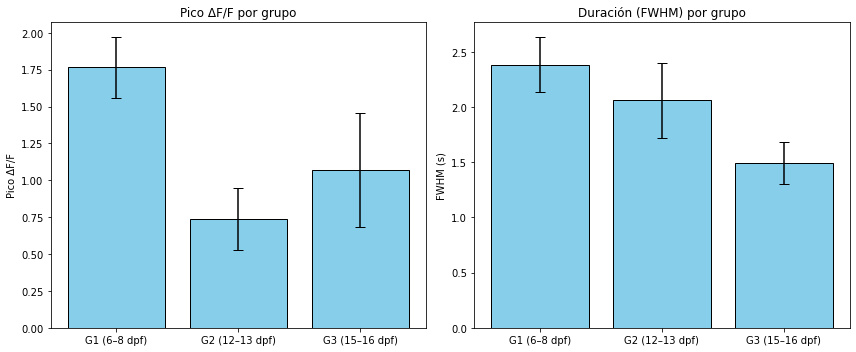

In [595]:
from scipy.signal import find_peaks

# ================================================================
# Funciones auxiliares
# ================================================================
def calcular_fwhm(t, y):
    """Calcula FWHM: ancho a mitad altura del pico máximo."""
    if y is None or len(y) == 0: 
        return np.nan
    peak_idx = np.argmax(y)
    peak_val = y[peak_idx]
    half = peak_val / 2.0

    # izquierda
    left_idx = np.where(y[:peak_idx] <= half)[0]
    if len(left_idx) > 0:
        left = t[left_idx[-1]]
    else:
        left = t[0]

    # derecha
    right_idx = np.where(y[peak_idx:] <= half)[0]
    if len(right_idx) > 0:
        right = t[peak_idx + right_idx[0]]
    else:
        right = t[-1]

    return right - left

def calcular_pico(t, y, stim_s, frames_pre, frames_post):
    """Devuelve el valor del pico dentro de la ventana de estímulo."""
    if y is None or len(y) == 0:
        return np.nan
    win_mask = (t >= stim_s-frames_pre/fps) & (t <= stim_s+frames_post/fps)
    if not win_mask.any():
        return np.nan
    return np.nanmax(y[win_mask])

# ================================================================
# Loop por peces
# ================================================================
df_metrics = []

for fish_id, area in areas.items():
    if getattr(area, "aislado", 1) != 0:  # solo sociales
        continue
    edad = getattr(area, "edad", -999)

    # asignar grupo
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue

    # Paso 1: neuronas consistentes (≥2 trials activas en ventana)
    Nh = None
    Nh_plus_mask = None
    for tr in getattr(area, "trials_rea", []):
        cond = _get_condition(tr)
        if cond != "AV":  # usamos trials AV para consistencia
            continue
        rb = getattr(tr, "roi_binaries_rea2", None)
        if rb is None or region_key not in rb:
            continue
        B = np.asarray(rb[region_key])
        B = (B > 0).astype(int)
        Nh = B.shape[0]

        t, tr_fps = _trial_timebase(tr, fps)
        stim_frame = int(round(stim_s * tr_fps))
        win_idx = np.arange(stim_frame-frames_pre, stim_frame+frames_post+1)
        win_idx = win_idx[(win_idx >= 0) & (win_idx < B.shape[1])]

        resp = B[:, win_idx].sum(axis=1) > 0
        if Nh_plus_mask is None:
            Nh_plus_mask = resp.astype(int)
        else:
            Nh_plus_mask += resp.astype(int)

    if Nh is None or Nh_plus_mask is None:
        continue
    active_mask = Nh_plus_mask >= 2  # neuronas consistentes

    if not active_mask.any():
        continue

    # Paso 2: ΔF/F de esas neuronas, solo si responden en trial
    trial_traces = []
    for tr in getattr(area, "trials_rea", []):
        cond = _get_condition(tr)
        rb_bin = getattr(tr, "roi_binaries_rea2", None)
        rb_dff = getattr(tr, "roi_dffs", None)
        if rb_bin is None or rb_dff is None or region_key not in rb_bin or region_key not in rb_dff:
            continue

        B = np.asarray(rb_bin[region_key]).astype(int)
        D = np.asarray(rb_dff[region_key]).astype(float)
        if B.ndim != 2 or D.ndim != 2:
            continue

        # seleccionamos neuronas consistentes
        B_sel = B[active_mask, :]
        D_sel = D[active_mask, :]

        if B_sel.shape[0] == 0:
            continue

        # filtro: solo neuronas que se prendieron en este trial
        trial_mask = B_sel[:, stim_frame-frames_pre:stim_frame+frames_post+1].sum(axis=1) > 0
        if not trial_mask.any():
            continue

        D_sel = D_sel[trial_mask, :]

        # promedio ΔF/F de esas neuronas
        t, tr_fps = _trial_timebase(tr, fps)
        m = min(D_sel.shape[1], len(t))
        trial_traces.append(D_sel[:, :m].mean(axis=0))

    if len(trial_traces) == 0:
        continue

    # Paso 3: promedio global (neurona+trial)
    t_common, _ = _truncate_to_common_length([t])
    traces, m = _truncate_to_common_length(trial_traces)
    if m == 0:
        continue
    trace_mean = np.vstack(traces).mean(axis=0)
    t_common = t[:m] - stim_s

    # Paso 4: métricas
    peak_val = calcular_pico(t_common, trace_mean, 0, frames_pre, frames_post)
    fwhm_val = calcular_fwhm(t_common, trace_mean)

    df_metrics.append({
        "fish_id": fish_id,
        "grupo": gname,
        "peak": peak_val,
        "fwhm": fwhm_val
    })

df_metrics = pd.DataFrame(df_metrics)

# ================================================================
# Agrupar por grupo
# ================================================================
summary = (df_metrics.groupby("grupo")
           .agg(mean_peak=("peak", "mean"),
                sem_peak=("peak", lambda x: x.std(ddof=1)/np.sqrt(len(x))),
                mean_fwhm=("fwhm", "mean"),
                sem_fwhm=("fwhm", lambda x: x.std(ddof=1)/np.sqrt(len(x))))
           .reset_index())

print(summary)

# ================================================================
# Gráficos
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Peak
axes[0].bar(summary["grupo"], summary["mean_peak"], 
            yerr=summary["sem_peak"], capsize=5, color="skyblue", edgecolor="black")
axes[0].set_ylabel("Pico ΔF/F")
axes[0].set_title("Pico ΔF/F por grupo")

# FWHM
axes[1].bar(summary["grupo"], summary["mean_fwhm"], 
            yerr=summary["sem_fwhm"], capsize=5, color="skyblue", edgecolor="black")
axes[1].set_ylabel("FWHM (s)")
axes[1].set_title("Duración (FWHM) por grupo")

plt.tight_layout()
plt.show()


In [600]:
for j in range(4):
    df_metrics_i['grupo'][j] = 'G2_i (12–13 dpf)'

c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [601]:
df_metrics_i

,fish_id,grupo,peak,fwhm
0,129-1,G2_i (12–13 dpf),0.466538,2.24
1,130-1,G2_i (12–13 dpf),0.754219,2.40
2,132-1,G2_i (12–13 dpf),1.751132,1.60
3,136-1,G2_i (12–13 dpf),0.434063,1.92


In [602]:


df_merged = pd.concat([df_metrics, df_metrics_i], ignore_index=True)


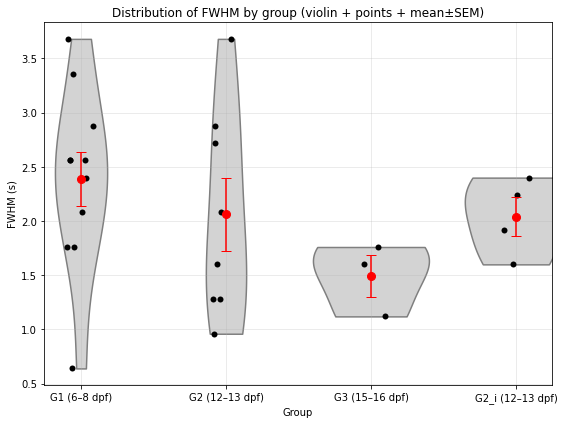

In [606]:
plt.figure(figsize=(8,6))

# violin plot
ax = sns.violinplot(
    data=df_merged, x="grupo", y="fwhm",
    inner=None, color="lightgray", cut=0
)

# puntos individuales
sns.stripplot(
    data=df_merged, x="grupo", y="fwhm",
    color="black", size=6, jitter=True, ax=ax
)

# resumen
summary = (df_merged.groupby("grupo")
           .agg(mean_fwhm=("fwhm", "mean"),
                sem_fwhm=("fwhm", lambda x: x.std(ddof=1)/np.sqrt(len(x))))
           .reset_index())

# obtener el orden real de seaborn
order = [t.get_text() for t in ax.get_xticklabels()]

# plotear medias y SEM en el lugar correcto
for pos, grupo in enumerate(order):
    row = summary.loc[summary["grupo"] == grupo]
    if not row.empty:
        ax.errorbar(pos, row["mean_fwhm"].values[0],
                    yerr=row["sem_fwhm"].values[0],
                    fmt="o", color="red", capsize=5, markersize=8, zorder=10)

ax.set_ylabel("FWHM (s)")
ax.set_xlabel("Group")
ax.set_title("Distribution of FWHM by group (violin + points + mean±SEM)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


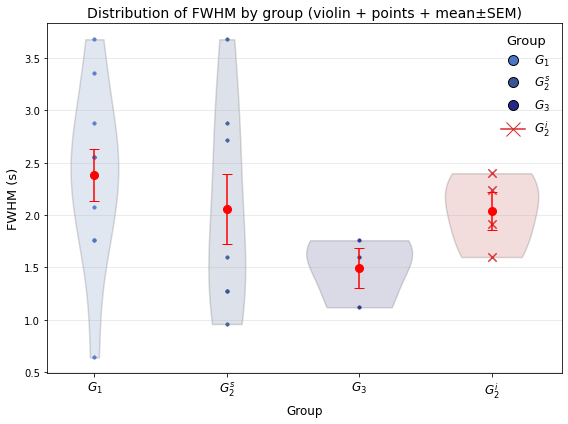

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))

# violin plots (colored by group, with transparency)
sns.violinplot(
    data=df_merged, x="grupo", y="fwhm",
    order=order_grupos, inner=None, cut=0,
    palette=colors, ax=ax
)

# ajustar alpha de cada violin (seaborn los guarda como colecciones de PolyCollections)
for violin in ax.collections:
    violin.set_alpha(0.18)

# scatter points (one per fish, on top)
for i, g in enumerate(order_grupos):
    sub = df_merged[df_merged["grupo"]==g]
    ax.scatter(
        np.full(len(sub), i), sub["fwhm"],
        color=colors[g],
        marker=markers[g],
        s=70 if g=="G2_i (12–13 dpf)" else 50,
        linewidths=1.5 if g=="G2_i (12–13 dpf)" else 0.5,
        alpha=0.9, zorder=3
    )

# summary stats (mean ± SEM)
summary = (df_merged.groupby("grupo")
           .agg(mean_fwhm=("fwhm", "mean"),
                sem_fwhm=("fwhm", lambda x: x.std(ddof=1)/np.sqrt(len(x))))
           .reset_index())

for pos, g in enumerate(order_grupos):
    row = summary.loc[summary["grupo"] == g]
    if not row.empty:
        ax.errorbar(pos, row["mean_fwhm"].values[0],
                    yerr=row["sem_fwhm"].values[0],
                    fmt="o", color="red", capsize=5, markersize=8,
                    zorder=10)

# axes and labels
ax.set_xticks(np.arange(len(order_grupos)))
ax.set_xticklabels(["$G_1$", "$G_2^{s}$", "$G_3$", "$G_2^{i}$"], fontsize=12)
ax.set_ylabel("FWHM (s)", fontsize=13)
ax.set_xlabel("Group", fontsize=12)
ax.set_title("Distribution of FWHM by group (violin + points + mean±SEM)", fontsize=14)
ax.grid(axis="y", alpha=0.3)

# manual legend
handles = [
    Line2D([0],[0], marker='.', color='none', markerfacecolor=colors["G1 (6–8 dpf)"], markersize=20, label="$G_1$"),
    Line2D([0],[0], marker='.', color='none', markerfacecolor=colors["G2 (12–13 dpf)"], markersize=20, label="$G_2^{s}$"),
    Line2D([0],[0], marker='.', color='none', markerfacecolor=colors["G3 (15–16 dpf)"], markersize=20, label="$G_3$"),
    Line2D([0],[0], marker='x', color=colors["G2_i (12–13 dpf)"], markersize=14, label="$G_2^{i}$"),
]
ax.legend(handles=handles, title="Group", frameon=False, loc="upper right", fontsize=12, title_fontsize=13)

plt.tight_layout()
#plt.savefig("fwhm_distribution_colored.pdf", dpi=300)
plt.show()


# Pruebo yo


In [44]:
# areas_dir = r'C:\Users\PC\Documents\GitHub\social_isolation_habenula_imaging\Exp_25\PKL 06-2025'
areas_dir = r'C:\Users\PC\Documents\GitHub\social_isolation_habenula_imaging\Exp_25\PKL 06-2025 Rea2'
# areas_dir = r'C:\Users\PC\Desktop\Analisis conf\PKL 11-2024'
areas = load_areas(areas_dir)

for key in areas:
    print(key + ":", len(areas[key].trials), "trials.")

113-1: 10 trials.
114-1: 10 trials.
115-1: 10 trials.
116-1: 10 trials.
117-1: 10 trials.
118-1: 10 trials.
120-1: 10 trials.
121-1: 10 trials.
122-1: 10 trials.
123-1: 10 trials.
124-1: 10 trials.
125-1: 10 trials.
126-1: 10 trials.
127-1: 10 trials.
129-1: 10 trials.
130-1: 10 trials.
131-1: 10 trials.
132-1: 10 trials.
133-1: 10 trials.
134-1: 10 trials.
135-1: 10 trials.
136-1: 10 trials.
137-1: 10 trials.
138-1: 10 trials.
139-1: 10 trials.
143-1: 10 trials.


In [ ]:
# ================================================================
# Parámetros principales
# ================================================================
region_key   = 'Hb'
stim_s       = 23.6     # segundo del estímulo
fps          = 6.25     # fps si no hay trial.frame_times
solo_social  = True      # True = solo sociales, False = solo aislados 
solo_sociales  = solo_social     # True = sociales, False = aislados
    # True = sociales, False = aislados
win_s      = 1.0          # ventana post-estímulo (s)
consistencia_en_trial =1 #Numero de veces q se prendio la neurona en la ventana en un trial >consistencia_en_trial
# Ventana de análisis alrededor del estímulo
frames_pre   = 3     # número de frames antes
frames_post  = 6        # número de frames después
# Grupos por edad (dpf)
grupos = {
    "G1 (6–8 dpf)":   lambda e: 6 <= e <= 8,
    "G2 (12–13 dpf)": lambda e: 12 <= e <= 13,
    "G3 (15–16 dpf)": lambda e: 15 <= e <= 16,
}


In [ ]:
# for key in areas:
#     area = areas[key]
#     post = np.zeros(area.trials_rea[0].roi_binaries_rea2['Hb'][:,win_idx].shape)
#     for i in range(10):
#         if area.trials_rea[i].vis:
#             post +=area.trials_rea[i].roi_binaries_rea2['Hb'][:,win_idx]
#     tot_n_resp = 0
#     tot_resp = np.zeros(area.trials_rea[0].roi_binaries_rea2['Hb'][0:1,:].shape)
#     # plt.figure(figsize=(10,10))
#     for i in range(10):
#         if area.trials_rea[i].vis==1:
#             tot_n_resp += np.sum((np.max(post, axis=1)>1) * (np.sum(area.trials_rea[0].roi_binaries_rea2['Hb'][:,win_idx], axis=1)>0))
#             # plt.plot(area.trials_rea[i].roi_dffs['Hb'][(np.max(post, axis=1)>1) * (np.sum(area.trials_rea[0].roi_binaries_rea2['Hb'][:,win_idx], axis=1)>0),:].T, alpha=0.1, color='b')
#             tot_resp = np.concatenate([tot_resp, area.trials_rea[i].roi_dffs['Hb'][(np.max(post, axis=1)>1) * (np.sum(area.trials_rea[0].roi_binaries_rea2['Hb'][:,win_idx], axis=1)>0),:]], axis=0)
#             # tot_resp = np.concatenate([tot_resp, area.trials_rea[i].roi_binaries_rea2['Hb'][(np.max(post, axis=1)>1) * (np.sum(area.trials_rea[0].roi_binaries_rea2['Hb'][:,win_idx], axis=1)>0),:]], axis=0)
#     if tot_resp[:,:].shape[0]>2:
#         print(key)
#         area.median_av_cons_responce = np.mean(tot_resp[1:,:], axis=0)
#         area.tot_median_av_cons_responce = tot_n_resp
#     else:
#         area.median_av_cons_responce = None
#         area.tot_median_av_cons_responce = 0

113-1
114-1
115-1
116-1
118-1
121-1
122-1
123-1
124-1
125-1
126-1
127-1
129-1
130-1
131-1
132-1
133-1
134-1
135-1
136-1
138-1
139-1
143-1


In [60]:
stim_frame = int(round(stim_s * fps))
win_idx = np.arange(stim_frame-frames_pre, stim_frame+frames_post+1)
for key in areas:
    area = areas[key]
    post = np.zeros(area.trials_rea[0].roi_binaries_rea2['Hb'].shape[0])
    for i in range(10):
        if area.trials_rea[i].vis:
            post +=(area.trials_rea[i].roi_binaries_rea2['Hb'][:,win_idx].sum(axis=1)>=6).astype(int)
    tot_n_resp = 0
    tot_resp = np.zeros(area.trials_rea[0].roi_binaries_rea2['Hb'][0:1,:].shape)
    # plt.figure(figsize=(10,10))
    for i in range(10):
        if area.trials_rea[i].vis==1:
            tot_n_resp += np.sum((post>1) * ((area.trials_rea[i].roi_binaries_rea2['Hb'][:,win_idx].sum(axis=1)>=6).astype(int)))
            # plt.plot(area.trials_rea[i].roi_dffs['Hb'][(np.max(post, axis=1)>1) * (np.sum(area.trials_rea[0].roi_binaries_rea2['Hb'][:,win_idx], axis=1)>0),:].T, alpha=0.1, color='b')
            tot_resp = np.concatenate([tot_resp, area.trials_rea[i].roi_dffs['Hb'][(post>1) * (np.sum(area.trials_rea[0].roi_binaries_rea2['Hb'][:,win_idx], axis=1)>0),:]], axis=0)
            # tot_resp = np.concatenate([tot_resp, area.trials_rea[i].roi_binaries_rea2['Hb'][(np.max(post, axis=1)>1) * (np.sum(area.trials_rea[0].roi_binaries_rea2['Hb'][:,win_idx], axis=1)>0),:]], axis=0)
    if tot_resp[:,:].shape[0]>2:
        print(key)
        # area.median_av_cons_responce = np.mean(tot_resp[1:,:], axis=0)
        area.median_av_cons_responce = tot_resp[1:,:]
        area.tot_median_av_cons_responce = tot_n_resp
        area.n_simple = np.sum(post>1)
    else:
        area.median_av_cons_responce = None
        area.tot_median_av_cons_responce = 0


114-1
115-1
116-1
118-1
124-1
126-1
127-1
129-1
130-1
132-1
133-1
134-1
135-1
136-1
138-1
139-1


In [660]:
colors

{'G1 (6–8 dpf)s': '#4D76C4',
 'G2 (12–13 dpf)s': '#385696',
 'G2 (12–13 dpf)a': '#d62728',
 'G3 (15–16 dpf)s': '#27278B'}

In [ ]:
handles = [
    Line2D([0],[0], marker='.', color='none', markerfacecolor=colors["G1 (6–8 dpf)"], markersize=20, label="$G_1$"),
    Line2D([0],[0], marker='.', color='none', markerfacecolor=colors["G2 (12–13 dpf)"], markersize=20, label="$G_2^{s}$"),
    Line2D([0],[0], marker='.', color='none', markerfacecolor=colors["G3 (15–16 dpf)"], markersize=20, label="$G_3$"),
    Line2D([0],[0], marker='x', color=colors["G2_i (12–13 dpf)"], markersize=14, label="$G_2^{i}$"),

(215,)

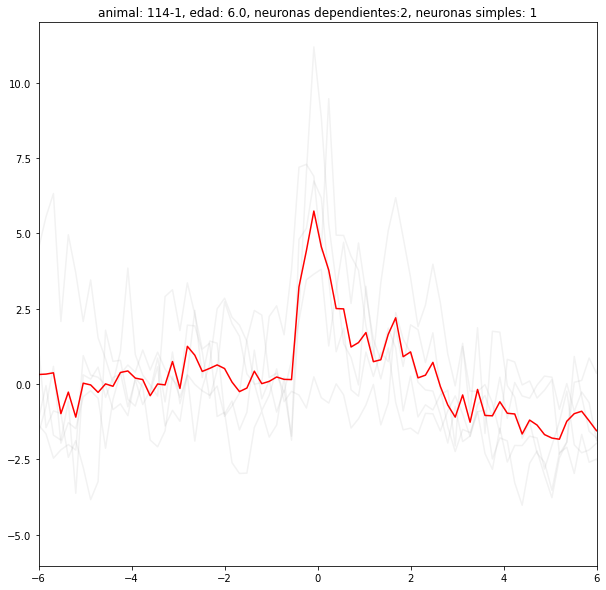

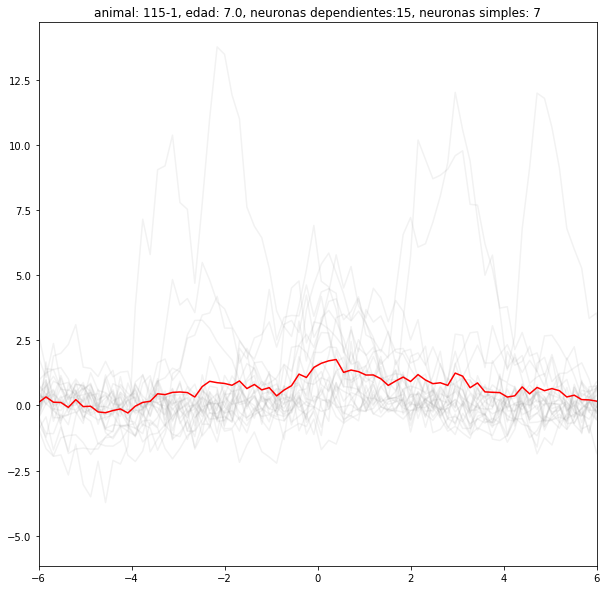

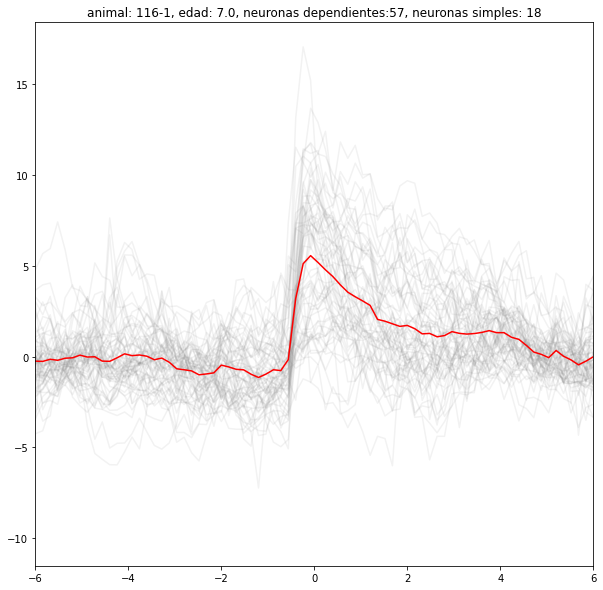

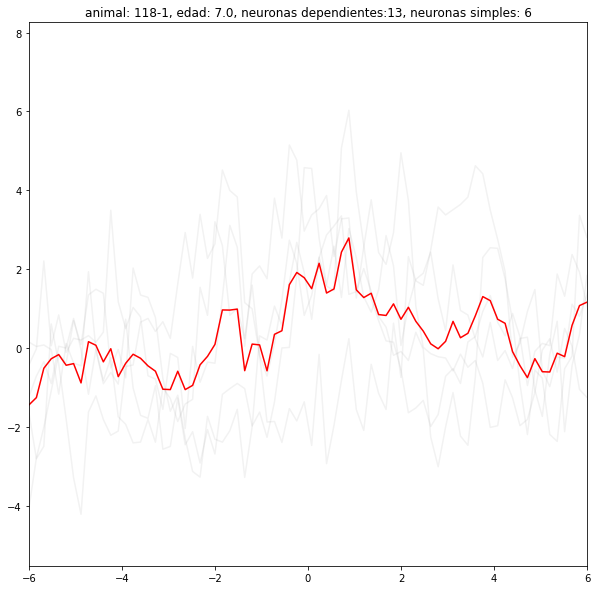

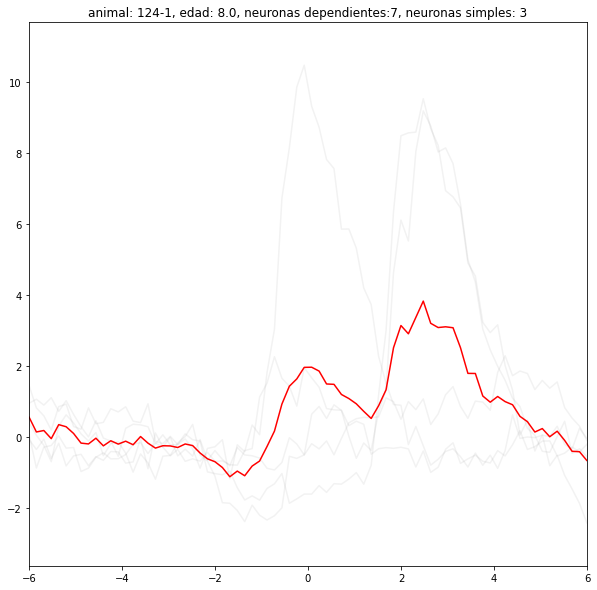

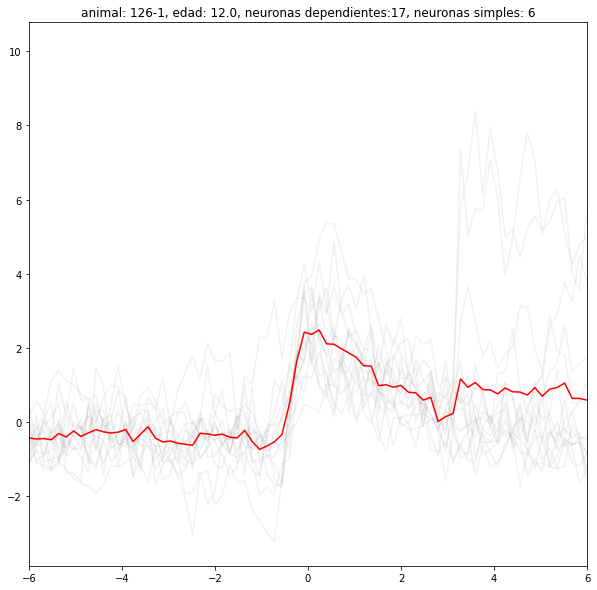

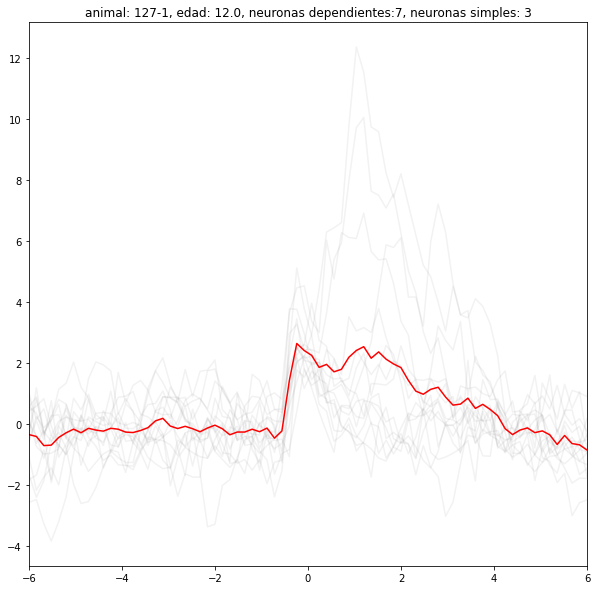

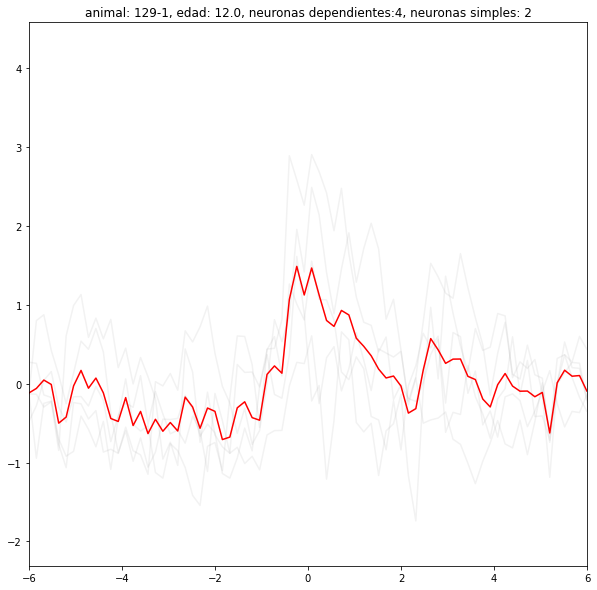

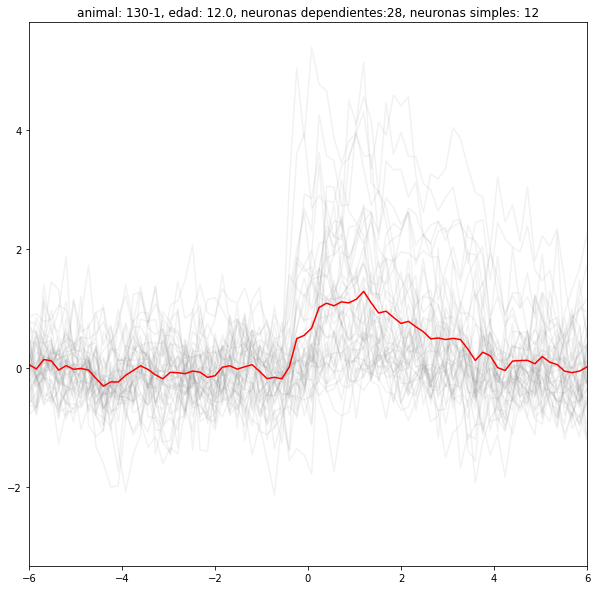

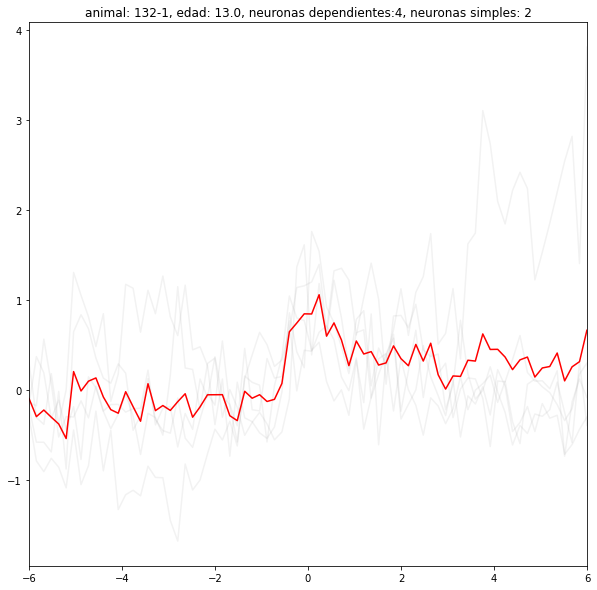

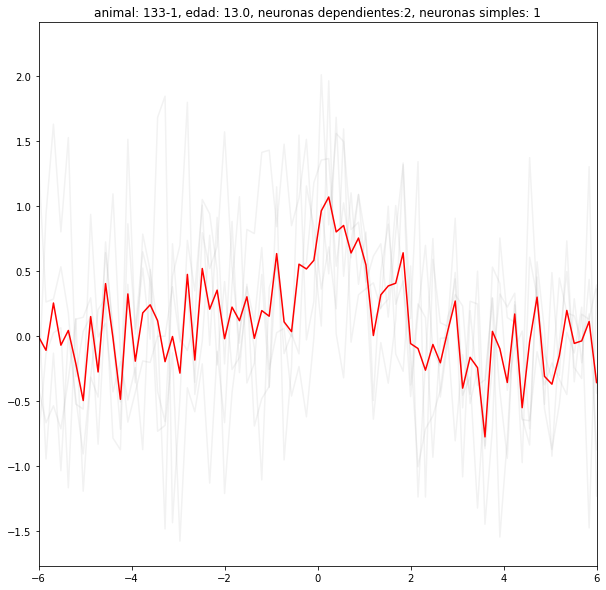

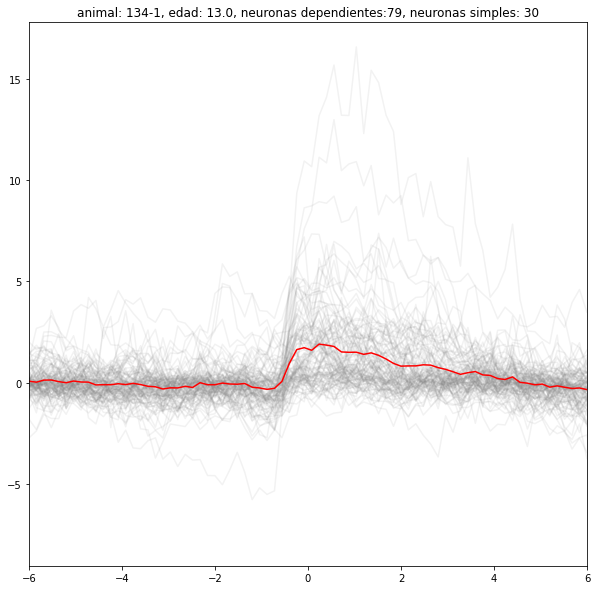

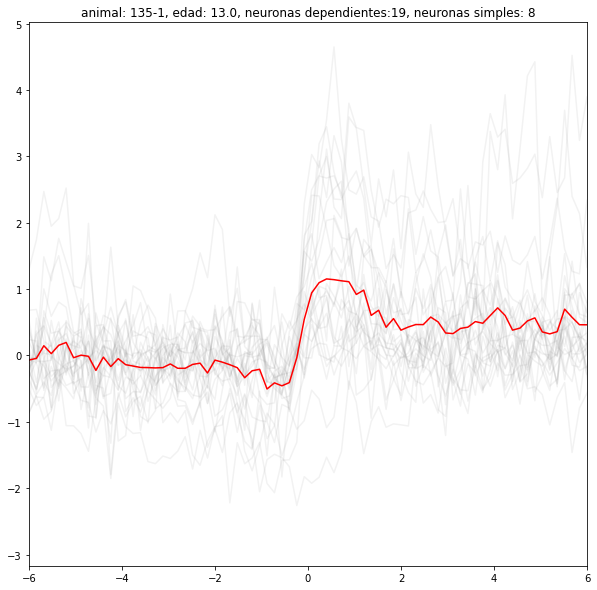

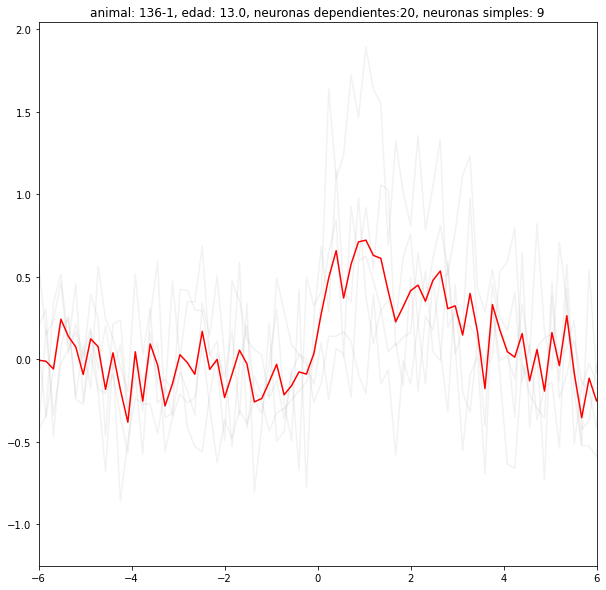

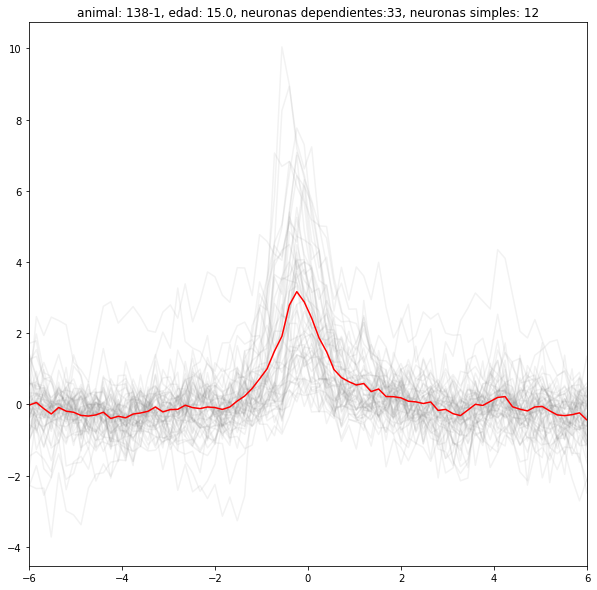

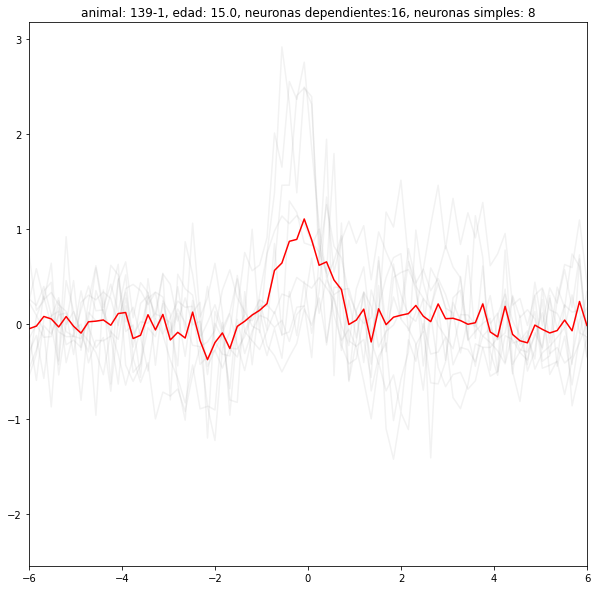

In [61]:
# fig, ax = plt.subplots(figsize=(6,5))
for j,key in enumerate(areas):
# for j,key in enumerate(['134-1']):
    if areas[key].median_av_cons_responce is None:
        continue
    area = areas[key]
    # ax.scatter(j,area.tot_median_av_cons_responce)
    plt.figure(figsize=(10,10))
    plt.title(f'animal: {key}, edad: {area.edad}, neuronas dependientes:{area.tot_median_av_cons_responce}, neuronas simples: {area.n_simple}')
    for dataaaa in area.median_av_cons_responce:
        plt.plot(t_plot,dataaaa, color='gray', alpha=0.1)
    plt.plot(t_plot,np.mean(area.median_av_cons_responce, axis=0), color='r')
    
    # plt.plot(t_plot,np.mean(area.median_av_cons_responce, axis=0), color=colors["G1 (6–8 dpf)s"])

    plt.xlim(-6,6)
    #plt.ylim(-1,6)

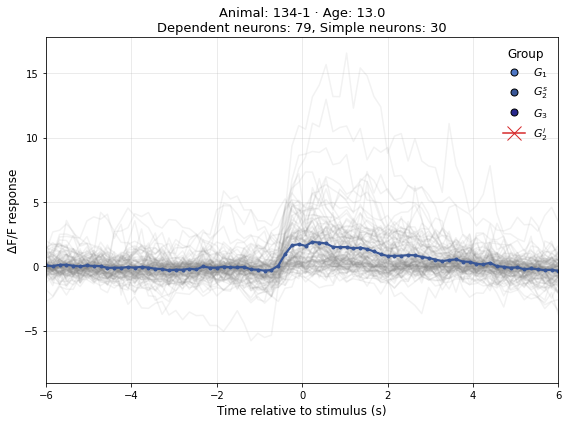

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# ----- Colors and markers -----
colors = {
    "G1 (6–8 dpf)s": "#4D76C4",
    "G2 (12–13 dpf)s": "#385696",
    "G2 (12–13 dpf)a": "#d62728",
    "G3 (15–16 dpf)s": "#27278B"
}
markers = {
    "G1 (6–8 dpf)s": ".",
    "G2 (12–13 dpf)s": ".",
    "G2 (12–13 dpf)a": "x",
    "G3 (15–16 dpf)s": "."
}

# ----- Function to assign group from age + isolation -----
def assign_group(area):
    edad = getattr(area, "edad", None)
    aislado = getattr(area, "aislado", 0)

    if 6 <= edad <= 8:
        return "G1 (6–8 dpf)s"
    elif 12 <= edad <= 13:
        return "G2 (12–13 dpf)a" if aislado == 1 else "G2 (12–13 dpf)s"
    elif 15 <= edad <= 16:
        return "G3 (15–16 dpf)s"
    else:
        return None

# ----- Loop over animals -----
# for key, area in areas.items():
# for key, area in [('134-1', areas['134-1'])]:
for key, area in [('134-1', areas['134-1'])]:
    if area.median_av_cons_responce is None:
        continue

    g = assign_group(area)
    if g is None:
        continue

    # Figure
    fig, ax = plt.subplots(figsize=(8,6))
    ax.set_title(
        f"Animal: {key} · Age: {area.edad}\n"
        f"Dependent neurons: {area.tot_median_av_cons_responce}, "
        f"Simple neurons: {area.n_simple}",
        fontsize=13
    )

    # All individual curves (thin gray)
    for trace in area.median_av_cons_responce:
        ax.plot(t_plot, trace, color="gray", alpha=0.1)

    # Mean curve (group color)
    ax.plot(
        t_plot,
        np.mean(area.median_av_cons_responce, axis=0),
        color=colors[g],
        linewidth=2.2,
        marker=markers[g],
        label=g
    )

    # Axes
    ax.set_xlim(-6,6)
    ax.set_xlabel("Time relative to stimulus (s)", fontsize=12)
    ax.set_ylabel("ΔF/F response", fontsize=12)
    ax.grid(alpha=0.3)

    # Legend (manual, consistent with groups)
    handles = [
        Line2D([0],[0], marker='.', color='none',
               markerfacecolor=colors["G1 (6–8 dpf)s"], markersize=14, label="$G_1$"),
        Line2D([0],[0], marker='.', color='none',
               markerfacecolor=colors["G2 (12–13 dpf)s"], markersize=14, label="$G_2^{s}$"),
        Line2D([0],[0], marker='.', color='none',
               markerfacecolor=colors["G3 (15–16 dpf)s"], markersize=14, label="$G_3$"),
        Line2D([0],[0], marker='x', color=colors["G2 (12–13 dpf)a"], markersize=14, label="$G_2^{i}$"),
    ]
    ax.legend(handles=handles, title="Group", frameon=False,
              loc="upper right", fontsize=11, title_fontsize=12)

    fig.patch.set_facecolor("white")
    plt.tight_layout()
    plt.show()


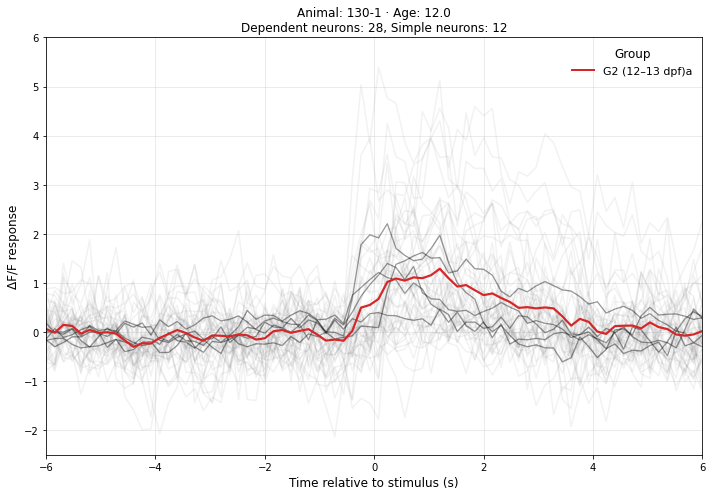

In [70]:
# fig, ax = plt.subplots(figsize=(7,5))
kkey = '130-1'
# for key, area in areas.items():
for key, area in [(kkey, areas[kkey])]:
    if area.median_av_cons_responce is None:
        continue

    # --- Determinar grupo por edad ---
    edad = getattr(area, "edad", -999)
    aislado = getattr(area, "aislado", 0)
    if 6 <= edad <= 8:
        grupo_plot = "G1 (6–8 dpf)s"
    elif 12 <= edad <= 13 and aislado == 0:
        grupo_plot = "G2 (12–13 dpf)s"
    elif 12 <= edad <= 13 and aislado == 1:
        grupo_plot = "G2 (12–13 dpf)a"
    elif 15 <= edad <= 16:
        grupo_plot = "G3 (15–16 dpf)s"
    else:
        continue

    color = colors[grupo_plot]

    plt.figure(figsize=(10,7))
    plt.title(f"Animal: {key} · Age: {edad}\nDependent neurons: {area.tot_median_av_cons_responce}, Simple neurons: {area.n_simple}")

    # --- Curvas individuales (gris claro) ---
    for dataaaa in area.median_av_cons_responce:
        plt.plot(t_plot, dataaaa, color="gray", alpha=0.1)

    # --- Promedio por trial (verde para debug) ---
    trial_means = []
    for tr in getattr(area, "trials_rea", []):
        if not getattr(tr, "vis", 0):
            continue
        rb = getattr(tr, "roi_binaries_rea2", None)
        if rb is None or "Hb" not in rb:
            continue

        B = rb["Hb"][:, win_idx]
        mask = (B.sum(axis=1) >= 4)
        traces = tr.roi_dffs["Hb"][mask, :]
        if traces.shape[0] > 0:
            mean_trial = np.mean(traces, axis=0)
            trial_means.append(mean_trial)
            plt.plot(t_plot, mean_trial, color="black", alpha=0.4, linewidth=1.3)

    # --- Promedio global (curva azul/grupo) ---
    plt.plot(t_plot, np.mean(area.median_av_cons_responce, axis=0),
             color=color, linewidth=2.2)

    # --- Estilo general ---
    plt.xlim(-6, 6)
    plt.ylim(-2.5, 6)
    plt.xlabel("Time relative to stimulus (s)", fontsize=12)
    plt.ylabel("ΔF/F response", fontsize=12)
    plt.grid(alpha=0.3)

    # --- Leyenda dinámica (solo este grupo) ---
    from matplotlib.lines import Line2D
    handles = [Line2D([0],[0], color=color, lw=2, label=grupo_plot)]
    plt.legend(handles=handles, title="Group", frameon=False, fontsize=11, title_fontsize=12)

    plt.tight_layout()
    # plt.savefig(f"animal_{key}_response.pdf", dpi=300)
    plt.show()


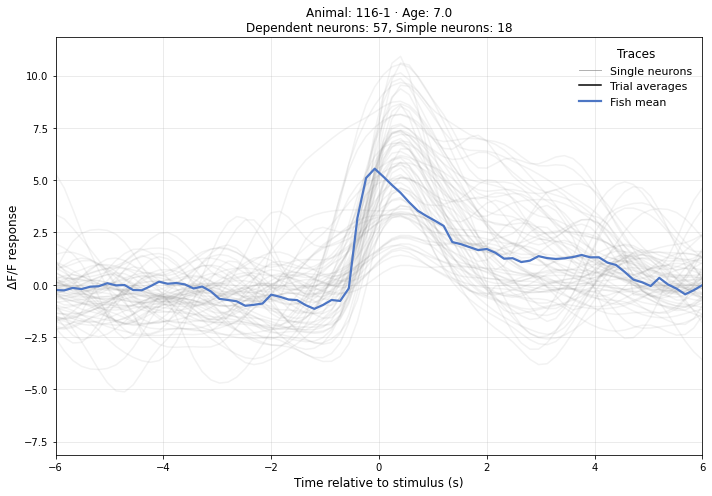

In [160]:
# from matplotlib.lines import Line2D

# fig, ax = plt.subplots(figsize=(7,5))

# for key, area in areas.items():
for key, area in [('116-1', areas['116-1'])]:

    if area.median_av_cons_responce is None:
        continue

    # --- Determinar grupo por edad ---
    edad = getattr(area, "edad", -999)
    aislado = getattr(area, "aislado", 0)
    if 6 <= edad <= 8:
        grupo_plot = "G1 (6–8 dpf)s"
    elif 12 <= edad <= 13 and aislado == 0:
        grupo_plot = "G2 (12–13 dpf)s"
    elif 12 <= edad <= 13 and aislado == 1:
        grupo_plot = "G2 (12–13 dpf)a"
    elif 15 <= edad <= 16:
        grupo_plot = "G3 (15–16 dpf)s"
    else:
        continue

    color = colors[grupo_plot]

    plt.figure(figsize=(10,7))
    plt.title(f"Animal: {key} · Age: {edad}\nDependent neurons: {area.tot_median_av_cons_responce}, Simple neurons: {area.n_simple}")

    # --- Curvas individuales (single neurons, gris claro) --- gaussian_filter1d(dataaaa,2)
    for dataaaa in area.median_av_cons_responce:
        # plt.plot(t_plot, dataaaa, color="gray", alpha=0.1)
        g1=gaussian_filter1d(dataaaa,2)
        plt.plot(t_plot, np.roll(g1, -np.argmax(g1)+150), color="gray", alpha=0.1)
        # plt.plot(t_plot, g1, color="gray", alpha=0.1)

    # --- Promedio por trial (negro) ---
    trial_means = []
    for tr in getattr(area, "trials_rea", []):
        if not getattr(tr, "vis", 0):
            continue
        rb = getattr(tr, "roi_binaries_rea2", None)
        if rb is None or "Hb" not in rb:
            continue

        B = rb["Hb"][:, win_idx]
        mask = (B.sum(axis=1) >= 4)
        traces = tr.roi_dffs["Hb"][mask, :]
        # if traces.shape[0] > 0:
        #     mean_trial = np.mean(traces, axis=0)
        #     trial_means.append(mean_trial)
        #     plt.plot(t_plot, mean_trial, color="black", alpha=0.6, linewidth=1.3)

    # --- Promedio global (curva del grupo) ---
    plt.plot(t_plot, np.mean(area.median_av_cons_responce, axis=0),
                color=color, linewidth=2.2)

    # --- Estilo general ---
    plt.xlim(-6, 6)
    plt.xlabel("Time relative to stimulus (s)", fontsize=12)
    plt.ylabel("ΔF/F response", fontsize=12)
    plt.grid(alpha=0.3)

    # --- Leyenda completa ---
    handles = [
        Line2D([0],[0], color="gray", lw=1, alpha=0.6, label="Single neurons"),
        Line2D([0],[0], color="black", lw=1.5, label="Trial averages"),
        Line2D([0],[0], color=color, lw=2.2, label="Fish mean")
    ]
    plt.legend(handles=handles, title="Traces", frameon=False, fontsize=11, title_fontsize=12)

    plt.tight_layout()
    plt.savefig(f"animal_{key}_response.pdf", dpi=300)

    plt.show()


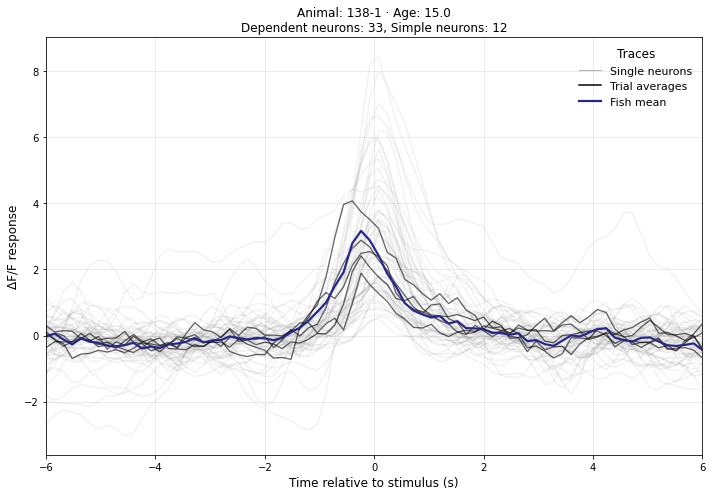

In [244]:
# from matplotlib.lines import Line2D

# fig, ax = plt.subplots(figsize=(7,5))
G_resp = np.empty(dataaaa.shape[0])
# 116-1, 126-1, 127-1, 130-1, 134-1, 135-1, 138-1, 139-1, 114-1, 115-1

# for key, area in areas.items():
for key, area in [('138-1', areas['138-1'])]:

    if area.median_av_cons_responce is None:
        continue

    # --- Determinar grupo por edad ---
    edad = getattr(area, "edad", -999)
    aislado = getattr(area, "aislado", 0)
    if 6 <= edad <= 8:
        grupo_plot = "G1 (6–8 dpf)s"
    elif 12 <= edad <= 13 and aislado == 0:
        grupo_plot = "G2 (12–13 dpf)s"
    elif 12 <= edad <= 13 and aislado == 1:
        grupo_plot = "G2 (12–13 dpf)a"
    elif 15 <= edad <= 16:
        grupo_plot = "G3 (15–16 dpf)s"
    else:
        continue

    color = colors[grupo_plot]

    plt.figure(figsize=(10,7))
    plt.title(f"Animal: {key} · Age: {edad}\nDependent neurons: {area.tot_median_av_cons_responce}, Simple neurons: {area.n_simple}")

    # --- Curvas individuales (single neurons, gris claro) --- gaussian_filter1d(dataaaa,2)
    for dataaaa in area.median_av_cons_responce:
        # plt.plot(t_plot, dataaaa, color="gray", alpha=0.1)
        # plt.plot(t_plot, gaussian_filter1d(dataaaa,2), color="gray", alpha=0.1)

        g1=gaussian_filter1d(dataaaa,1)
        plt.plot(t_plot, np.roll(g1, -np.argmax(g1)+148), color="gray", alpha=0.1)
        G_resp = np.vstack((G_resp,  np.roll(g1, -np.argmax(g1)+150)))

    # --- Promedio por trial (negro) ---
    trial_means = []
    for tr in getattr(area, "trials_rea", []):
        if not getattr(tr, "vis", 0):
            continue
        rb = getattr(tr, "roi_binaries_rea2", None)
        if rb is None or "Hb" not in rb:
            continue

        B = rb["Hb"][:, win_idx]
        mask = (B.sum(axis=1) >= 4)
        traces = tr.roi_dffs["Hb"][mask, :]
        if traces.shape[0] > 0:
            mean_trial = np.mean(traces, axis=0)
            trial_means.append(mean_trial)
            plt.plot(t_plot, mean_trial, color="black", alpha=0.6, linewidth=1.3)

    # --- Promedio global (curva del grupo) ---
    plt.plot(t_plot, np.mean(area.median_av_cons_responce, axis=0),
                color=color, linewidth=2.2)

    # --- Estilo general ---
    plt.xlim(-6, 6)
    plt.xlabel("Time relative to stimulus (s)", fontsize=12)
    plt.ylabel("ΔF/F response", fontsize=12)
    plt.grid(alpha=0.3)

    # --- Leyenda completa ---
    handles = [
        Line2D([0],[0], color="gray", lw=1, alpha=0.6, label="Single neurons"),
        Line2D([0],[0], color="black", lw=1.5, label="Trial averages"),
        Line2D([0],[0], color=color, lw=2.2, label="Fish mean")
    ]
    plt.legend(handles=handles, title="Traces", frameon=False, fontsize=11, title_fontsize=12)

    plt.tight_layout()
    plt.savefig(f"animal_{key}_response.pdf", dpi=300)

    plt.show()


In [166]:
FWHM = []

In [187]:
FWHM

[1.7504398411932096,
 2.0425676362207104,
 1.509176878340387,
 2.0728071138059767,
 1.8636406360901807,
 2.103677354226041,
 1.408561355583783,
 1.5148595046357793]

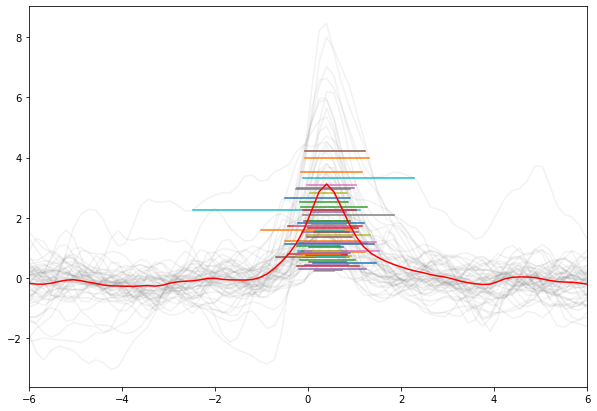

In [245]:
testeo_0 = []
met = calcular_metrica_curva(t_plot, np.mean(G_resp[1:,:], axis=0), stim_window=(-1*frames_pre, frames_post))
plt.figure(figsize=(10,7))
# plt.plot(t_plot, np.mean(G_resp[1:,:], axis=0), color='r')
for gresp in G_resp[:,:]:
    met = calcular_metrica_curva(t_plot, gresp, stim_window=(-1*frames_pre, frames_post))
    plt.plot(t_plot, gresp, color='gray', alpha=0.1)
# plt.plot(t_plot, G_resp[1,:], color='r')
    plt.plot([met['fwhm_left'], met['fwhm_right']], [met['peak_val']/2, met['peak_val']/2], '-')
    testeo_0.append(met['fwhm_right'] - met['fwhm_left'])
plt.xlim(-6,6)
# FWHM.append(met['fwhm_right'] - met['fwhm_left'])
plt.plot(t_plot, np.mean(G_resp[1:,:], axis=0), color='r')


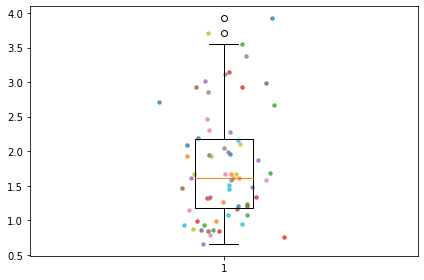

In [241]:



plt.boxplot(testeo_0)

for i, y in enumerate(testeo_0):
    x = np.random.normal(1, 0.06)  # jitter simple
    plt.scatter(x, y, s=12, alpha=0.7)

plt.tight_layout()
plt.show()

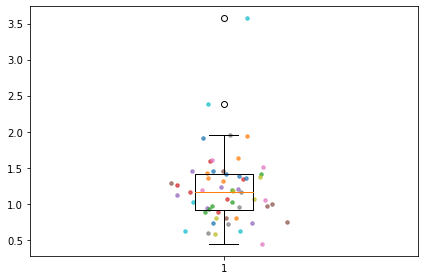

In [246]:



plt.boxplot(testeo_0)

for i, y in enumerate(testeo_0):
    x = np.random.normal(1, 0.06)  # jitter simple
    plt.scatter(x, y, s=12, alpha=0.7)

plt.tight_layout()
plt.show()

In [203]:
edades_anchos = []

for key in ['116-1', '126-1', '127-1', '130-1', '134-1', '135-1', '138-1', '139-1', '114-1', '115-1', '124-1']:
    edades_anchos.append(areas[key].edad)

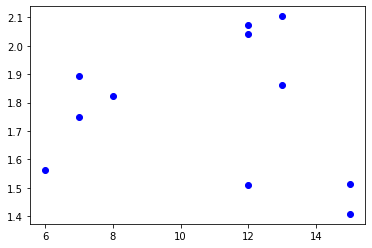

In [ ]:
for edad, ancho in zip(edades_anchos, FWHM):
    plt.scatter(edad, ancho, color='b' edad if condicion else valor_si_falso)

In [147]:
met = calcular_metrica_curva(t_plot, np.mean(G_resp[1:,:], axis=0), stim_window=(-1*frames_pre, frames_post))

In [146]:
from scipy.interpolate import interp1d
def calcular_metrica_curva(t, y, stim_window=(-1, 3)):
    """
    Calcula pico, delay y ancho a mitad de altura (FWHM).
    Busca solo los cruces inmediatos alrededor del pico.
    """
    mask = (t >= stim_window[0]) & (t <= stim_window[1])
    if not mask.any():
        return None
    t_win, y_win = t[mask], y[mask]

    # Pico
    peak_idx = np.argmax(y_win)
    peak_val = y_win[peak_idx]
    delay    = t_win[peak_idx]

    # FWHM
    half_height = peak_val / 2.0

    # --- Izquierda del pico ---
    fwhm_left = np.nan
    for i in range(peak_idx, 0, -1):  # desde el pico hacia atrás
        if (y_win[i]-half_height)*(y_win[i-1]-half_height) < 0:
            f = interp1d([y_win[i-1], y_win[i]], [t_win[i-1], t_win[i]])
            fwhm_left = float(f(half_height))
            break

    # --- Derecha del pico ---
    fwhm_right = np.nan
    for i in range(peak_idx, len(y_win)-1):  # desde el pico hacia adelante
        if (y_win[i]-half_height)*(y_win[i+1]-half_height) < 0:
            f = interp1d([y_win[i], y_win[i+1]], [t_win[i], t_win[i+1]])
            fwhm_right = float(f(half_height))
            break

    return {"peak_val": peak_val, "delay": delay,
            "fwhm_left": fwhm_left, "fwhm_right": fwhm_right}
